In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import platform
import sklearn
import os

In [2]:
import matplotlib

try:
    import torch
    torch_ver = torch.__version__
    gpu_available = torch.cuda.is_available()
except ImportError:
    torch_ver = 'not installed'
    gpu_available = False

SEED = 42

print(f'Python:       {sys.version.split()[0]}')
print(f'Platform:     {platform.platform()}')
print(f'machine:      {platform.machine()}')
print(f'gpu:          {gpu_available}')
print(f'processor:    {platform.processor()}')
print(f'cpu_available:{os.cpu_count()}')
print(f'numpy:        {np.__version__}')
print(f'pandas:       {pd.__version__}')
print(f'matplotlib:   {matplotlib.__version__}')
print(f'seaborn:      {sns.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'torch:        {torch_ver}   GPU available: {gpu_available}')
print(f'Random seed:  {SEED}')

Python:       3.13.10
Platform:     Windows-11-10.0.26200-SP0
machine:      AMD64
gpu:          False
processor:    Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
cpu_available:20
numpy:        2.4.4
pandas:       2.2.3
matplotlib:   3.11.1
seaborn:      0.13.2
scikit-learn: 1.9.0
torch:        2.8.0+cpu   GPU available: False
Random seed:  42


In [3]:
from pathlib import Path
import os

# _CANDIDATES = [
#     os.environ.get('BRFSS_CSV'),
#     Path('input_data') / 'diabetes_012_health_indicators_BRFSS2015.csv',
#     Path('data') / 'diabetes_012_health_indicators_BRFSS2015.csv',
#     Path.cwd() / 'input_data' / 'diabetes_012_health_indicators_BRFSS2015.csv',
# ]
_CANDIDATES = [
    "C:\\Users\\Pagarwal\\OneDrive - Kmart Australia Limited\\Downloads\\masters\\diabetes_012_health_indicators_BRFSS2015.csv"
]

CSV_PATH = next((Path(p) for p in _CANDIDATES if p and Path(p).exists()), None)

if CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find the BRFSS CSV in 'inout_data/' or the repo-local data folders."
    )

print(f'Using CSV at: {CSV_PATH}')

df = pd.read_csv(CSV_PATH)
df.head()

Using CSV at: C:\Users\Pagarwal\OneDrive - Kmart Australia Limited\Downloads\masters\diabetes_012_health_indicators_BRFSS2015.csv


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [5]:
df.shape

(253680, 22)

In [6]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
unique_values = {}
for col in df.columns:
    unique_values[col] = df[col].value_counts().shape[0]

pd.DataFrame(unique_values, index=['unique value count']).transpose()

,unique value count
Diabetes_012,3
HighBP,2
HighChol,2
CholCheck,2
BMI,84
Smoker,2
Stroke,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2


In [8]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [9]:
missing_values = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

print(f'Missing values: {missing_values:,}')
print(f'duplicate rows: {duplicate_rows:,}')

_COUNT_COLS = {'MentHlth', 'PhysHlth'}

def _feature_type(col_name, n):
    if n <= 2:
        return 'binary'
    if n <= 15:
        return 'ordinal'
    if col_name in _COUNT_COLS:
        return 'count'
    return 'continuous'

n_unique_all = df.nunique()
quality_table = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'feature_type': [_feature_type(c, n_unique_all[c]) for c in df.columns],
    'missing': df.isna().sum(),
    'unique_values': n_unique_all,
    'minimum': df.min(),
    'maximum': df.max(),
    'mean': df.mean(),
    'standard_deviation': df.std(),
    'variance': df.var(),
}, index=df.columns)

display(quality_table.round(3))

Missing values: 0
duplicate rows: 23,899


,data_type,feature_type,missing,unique_values,minimum,maximum,mean,standard_deviation,variance
Diabetes_012,float64,ordinal,0,3,0.0,2.0,0.297,0.698,0.487
HighBP,float64,binary,0,2,0.0,1.0,0.429,0.495,0.245
HighChol,float64,binary,0,2,0.0,1.0,0.424,0.494,0.244
CholCheck,float64,binary,0,2,0.0,1.0,0.963,0.190,0.036
BMI,float64,continuous,0,84,12.0,98.0,28.382,6.609,43.675
Smoker,float64,binary,0,2,0.0,1.0,0.443,0.497,0.247
Stroke,float64,binary,0,2,0.0,1.0,0.041,0.197,0.039
HeartDiseaseorAttack,float64,binary,0,2,0.0,1.0,0.094,0.292,0.085
PhysActivity,float64,binary,0,2,0.0,1.0,0.757,0.429,0.184
Fruits,float64,binary,0,2,0.0,1.0,0.634,0.482,0.232


In [10]:
def v_counts(data):
    for i in data :
        print(data[i].value_counts())
        print("---------")

v_counts(df)

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
---------
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64
---------
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64
---------
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64
---------
BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
86.0        1
91.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
---------
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64
---------
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64
---------
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64
---------
PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64
---------
Fruits
1.0    160898
0.0     92782
Name: count, dtype: int64
---------
Veggies
1.0    205841
0.0     47839
Name: count, dtype: int64
---------
HvyAlcoholConsump
0.0    239424
1.0   

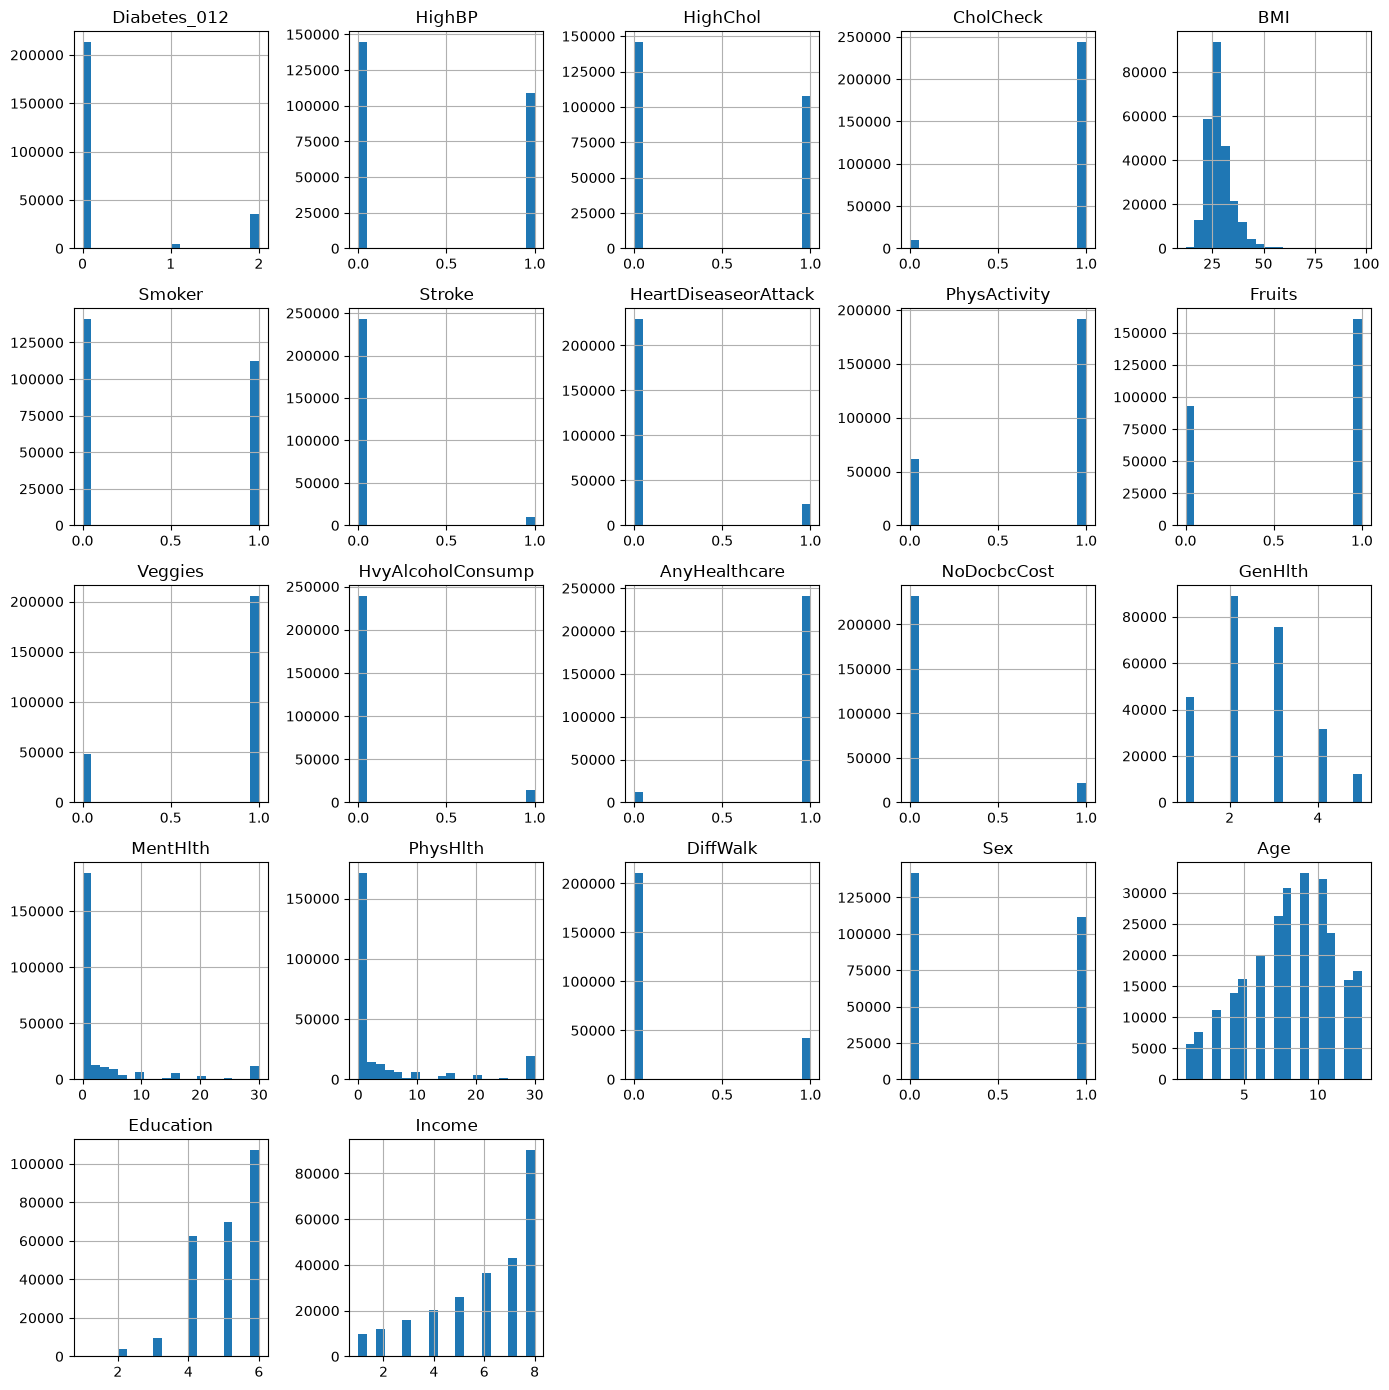

In [11]:
df.hist(figsize=(14, 14), bins=20)
plt.tight_layout()
plt.show()

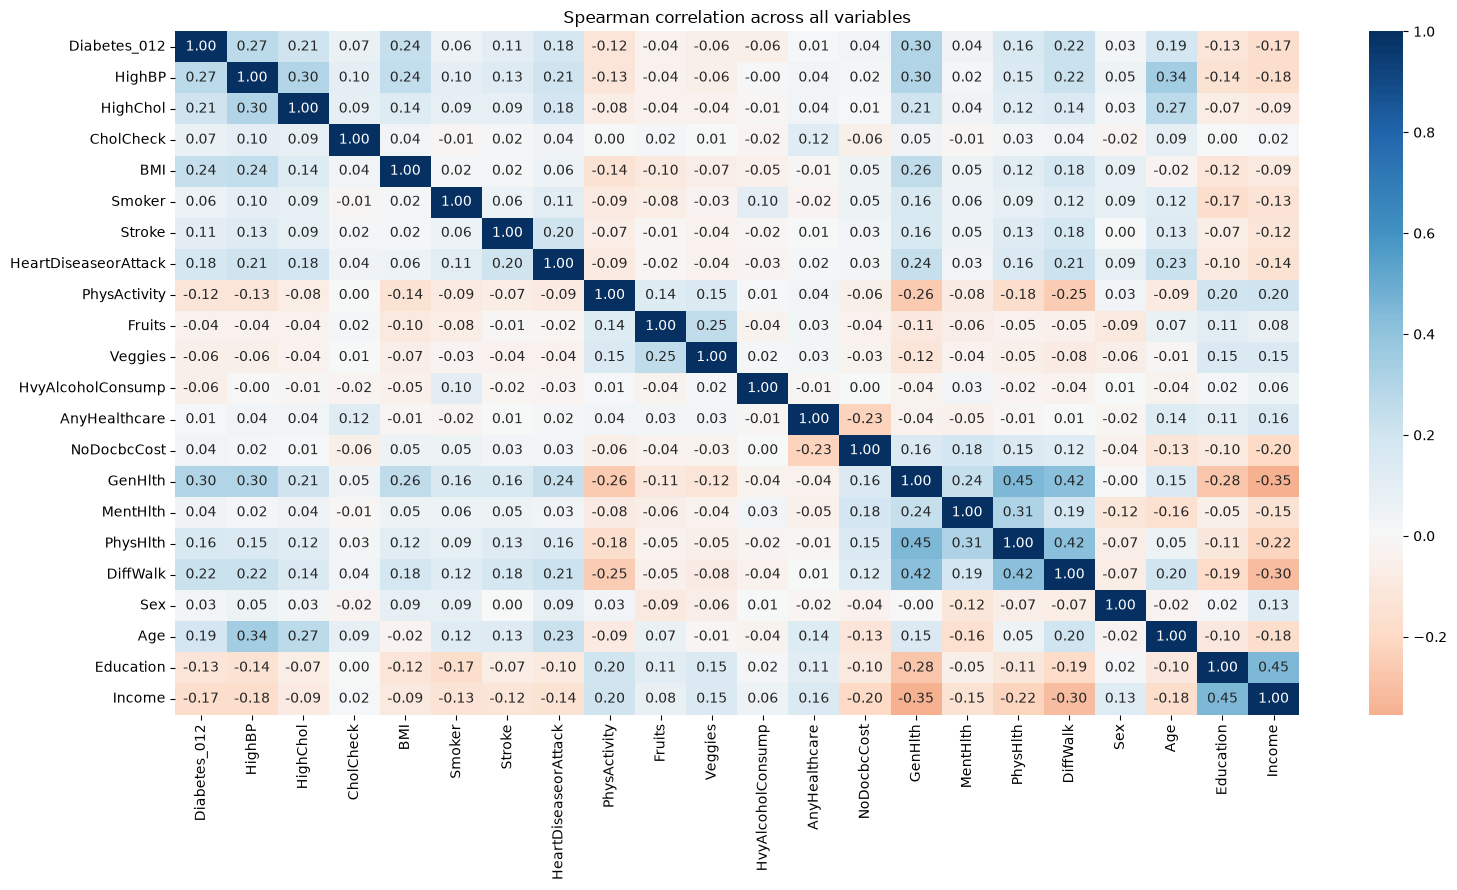

In [12]:
plt.figure(figsize=(16, 9))
sns.heatmap(
    df.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    center=0,
)
plt.title('Spearman correlation across all variables')
plt.tight_layout()
plt.show()

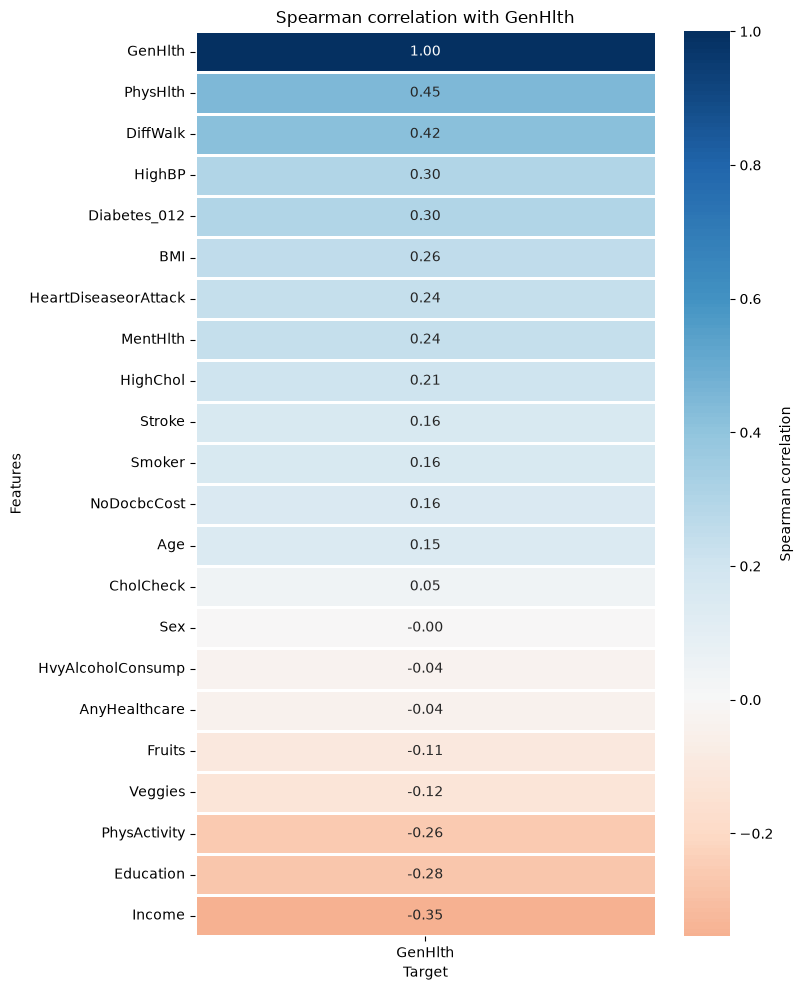

In [13]:
target_col = 'GenHlth'

target_corr = (
    df.corr(method='spearman')[[target_col]]
    .sort_values(by=target_col, ascending=False)
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    target_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    center=0,
    linewidths=0.8,
    cbar_kws={'label': 'Spearman correlation'},
)
plt.title('Spearman correlation with GenHlth')
plt.xlabel('Target')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [14]:
target_col = 'GenHlth'
CORR_THRESHOLD = 0.1

spearman_target_corr = (
    df.corr(method='spearman')[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

high_corr_features = spearman_target_corr.index[
    spearman_target_corr.abs() >= CORR_THRESHOLD
].tolist()
print(f'Features with |Spearman corr with {target_col}| >= {CORR_THRESHOLD} '
      f'({len(high_corr_features)}):')
print(high_corr_features)

Features with |Spearman corr with GenHlth| >= 0.1 (17):
['PhysHlth', 'DiffWalk', 'Income', 'HighBP', 'Diabetes_012', 'Education', 'BMI', 'PhysActivity', 'HeartDiseaseorAttack', 'MentHlth', 'HighChol', 'Stroke', 'Smoker', 'NoDocbcCost', 'Age', 'Veggies', 'Fruits']


,label,count,percent
GenHlth,,,
1.0,Excellent,45299,17.857
2.0,Very Good,89084,35.117
3.0,Good,75646,29.819
4.0,Fair,31570,12.445
5.0,Poor,12081,4.762


12081 89084
Majority-to-minority ratio: 7.37:1


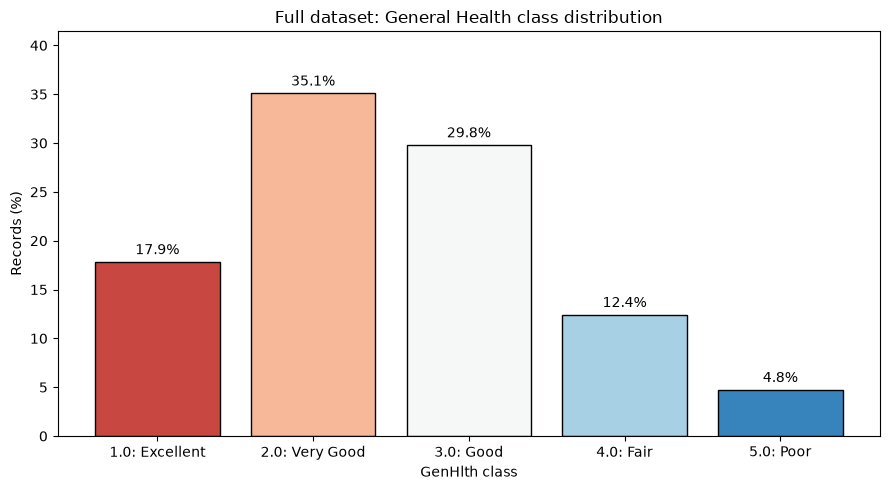

In [15]:
class_names = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}

target_table = df['GenHlth'].value_counts().sort_index().rename('count').to_frame()
target_table['label'] = target_table.index.map(class_names)
target_table['percent'] = 100 * target_table['count'] / len(df)
target_table = target_table[['label', 'count', 'percent']]

display(target_table.round({'percent': 3}))

majority_count = target_table['count'].max()
minority_count = target_table['count'].min()
print(minority_count, majority_count)
print(f'Majority-to-minority ratio: {majority_count / minority_count:.2f}:1')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [f'{number}: {class_names[number]}' for number in target_table.index],
    target_table['percent'],
    color=sns.color_palette('RdBu', 5),
    edgecolor='black',
)
ax.bar_label(bars, labels=[f'{value:.1f}%' for value in target_table['percent']], padding=3)
ax.set_title('Full dataset: General Health class distribution')
ax.set_xlabel('GenHlth class')
ax.set_ylabel('Records (%)')
ax.set_ylim(0, target_table['percent'].max() * 1.18)
plt.tight_layout()
plt.show()


In [16]:
n_unique = df.drop(columns=['GenHlth']).nunique().sort_values()

binary_features  = n_unique[n_unique == 2].index.tolist()
ordinal_features = n_unique[(n_unique > 2) & (n_unique <= 15)].index.tolist()

_high_card = n_unique[n_unique > 15].index.tolist()
count_features      = [c for c in _high_card if c in ('MentHlth', 'PhysHlth')]
continuous_features = [c for c in _high_card if c not in count_features]
numeric_features    = count_features + continuous_features

print(f'Binary features ({len(binary_features)}): {binary_features}')
print(f'Ordinal features ({len(ordinal_features)}): {ordinal_features}')
print(f'Count features ({len(count_features)}): {count_features}')
print(f'Continuous features ({len(continuous_features)}): {continuous_features}')

predictors = [column for column in df.columns if column != 'GenHlth']
all_typed = binary_features + ordinal_features + count_features + continuous_features
assert len(all_typed) == len(set(all_typed)), 'feature-type buckets overlap'
assert set(predictors) == set(all_typed), 'feature-type buckets do not cover all predictors'
print(f'Predictors ({len(predictors)}): {predictors}')

Binary features (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'HeartDiseaseorAttack', 'Stroke', 'Fruits', 'PhysActivity', 'AnyHealthcare', 'NoDocbcCost', 'Veggies', 'HvyAlcoholConsump', 'Sex', 'DiffWalk']
Ordinal features (4): ['Diabetes_012', 'Education', 'Income', 'Age']
Count features (2): ['MentHlth', 'PhysHlth']
Continuous features (1): ['BMI']
Predictors (21): ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


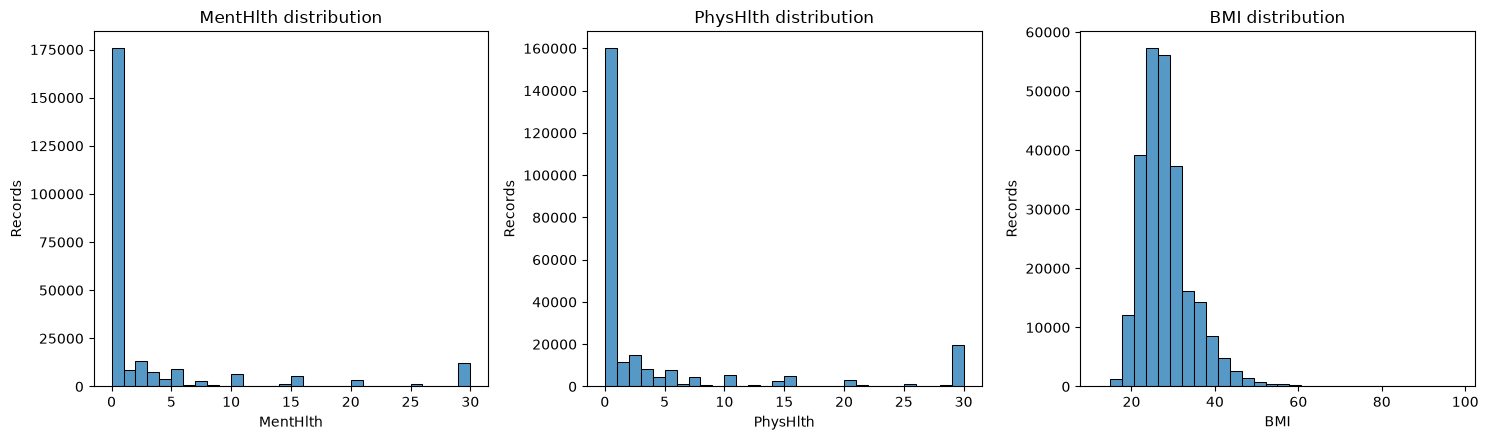

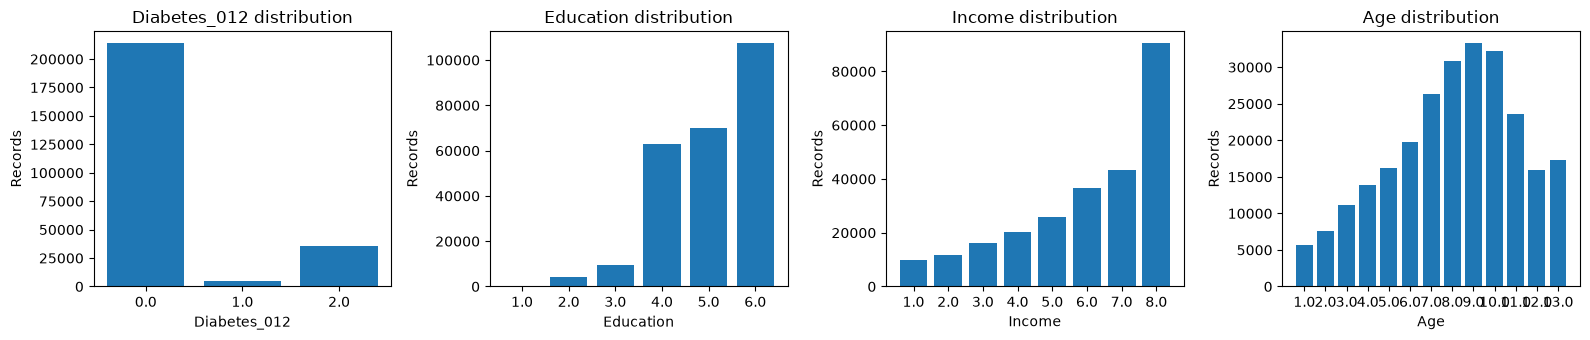

In [17]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4.5))
for ax, feature in zip(np.atleast_1d(axes), numeric_features):
    sns.histplot(df[feature], bins=30, ax=ax)
    ax.set_title(f'{feature} distribution')
    ax.set_ylabel('Records')
plt.tight_layout()
plt.show()

if ordinal_features:
    n_cols = min(4, len(ordinal_features))
    n_rows = int(np.ceil(len(ordinal_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    for ax, feature in zip(np.atleast_1d(axes).flat, ordinal_features):
        counts = df[feature].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(f'{feature} distribution')
        ax.set_xlabel(feature)
        ax.set_ylabel('Records')
    for ax in np.atleast_1d(axes).flat[len(ordinal_features):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

,PhysHlth,DiffWalk,Income,HighBP,Diabetes_012,Education,BMI,PhysActivity,HeartDiseaseorAttack,MentHlth,HighChol,Stroke,Smoker,NoDocbcCost,Age,Veggies,Fruits
GenHlth,,,,,,,,,,,,,,,,,
1.0,0.863,0.024,6.822,0.202,0.057,5.375,25.767,0.883,0.022,1.257,0.262,0.010,0.330,0.040,7.373,0.874,0.715
2.0,1.532,0.057,6.584,0.358,0.157,5.237,27.642,0.827,0.046,1.892,0.382,0.019,0.407,0.053,7.802,0.841,0.656
3.0,3.394,0.170,5.844,0.514,0.379,4.933,29.510,0.723,0.105,3.069,0.478,0.042,0.475,0.093,8.246,0.786,0.603
4.0,11.392,0.462,4.741,0.651,0.653,4.582,30.685,0.578,0.213,6.550,0.572,0.094,0.553,0.159,8.746,0.738,0.562
5.0,23.520,0.750,4.006,0.693,0.787,4.416,30.569,0.442,0.340,11.877,0.623,0.168,0.649,0.226,9.001,0.709,0.552


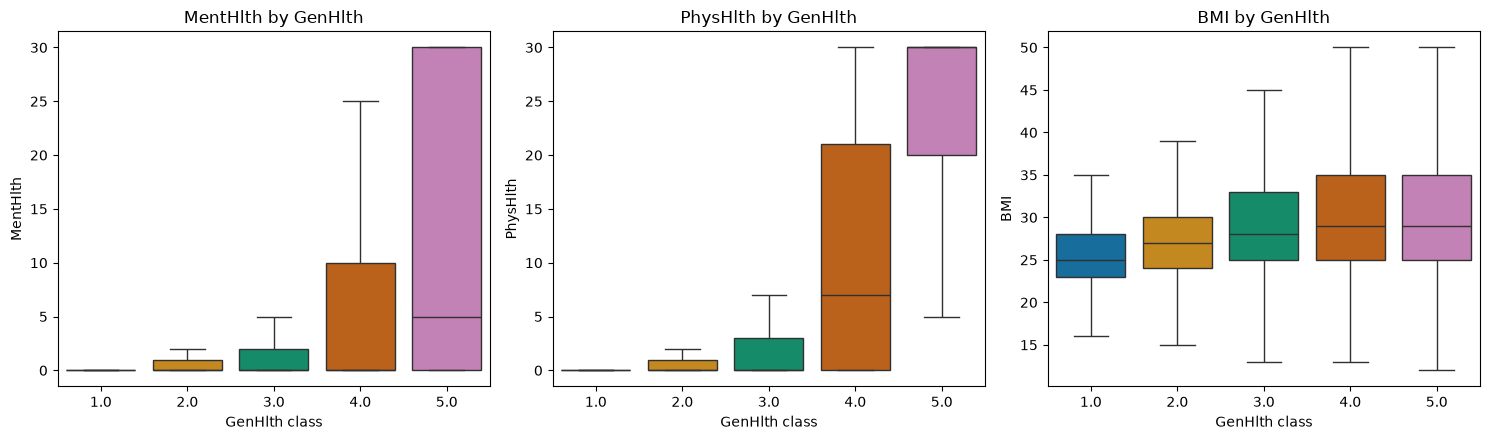

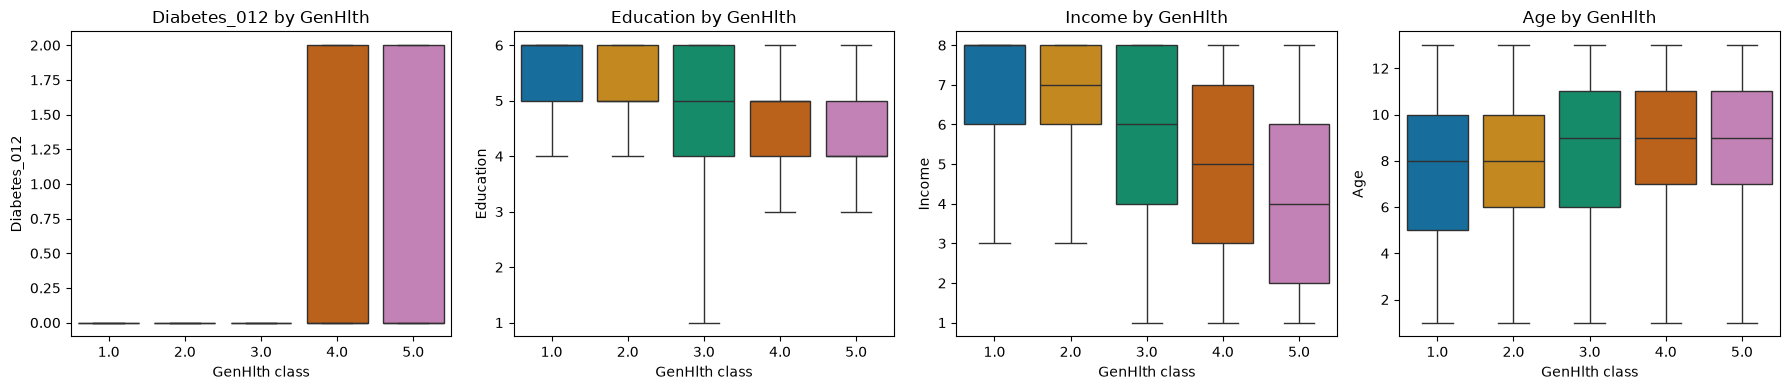

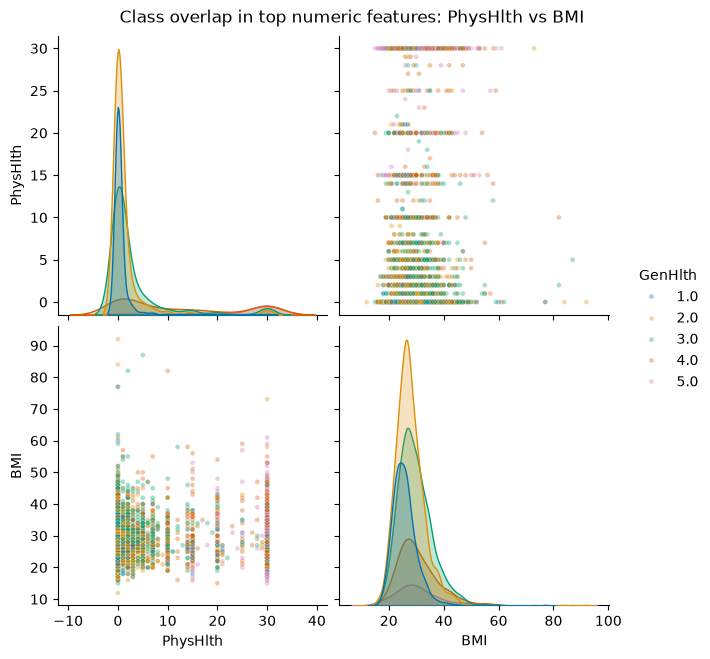

In [18]:
selected_features = high_corr_features

class_means = df.groupby('GenHlth')[selected_features].mean()
display(class_means.round(3))

fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4.5))
for ax, feature in zip(np.atleast_1d(axes), numeric_features):
    sns.boxplot(
        data=df,
        x='GenHlth',
        y=feature,
        hue='GenHlth',
        palette=sns.color_palette('colorblind', 5),
        showfliers=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{feature} by GenHlth')
    ax.set_xlabel('GenHlth class')
plt.tight_layout()
plt.show()

if ordinal_features:
    n_cols = min(4, len(ordinal_features))
    n_rows = int(np.ceil(len(ordinal_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
    for ax, feature in zip(np.atleast_1d(axes).flat, ordinal_features):
        sns.boxplot(
            data=df,
            x='GenHlth',
            y=feature,
            hue='GenHlth',
            palette=sns.color_palette('colorblind', 5),
            showfliers=False,
            legend=False,
            ax=ax,
        )
        ax.set_title(f'{feature} by GenHlth')
        ax.set_xlabel('GenHlth class')
    for ax in np.atleast_1d(axes).flat[len(ordinal_features):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

top_numeric = [f for f in high_corr_features if f in numeric_features][:2]
if len(top_numeric) == 2:
    pair_sample = df.sample(n=min(5000, len(df)), random_state=42)
    sns.pairplot(
        pair_sample,
        vars=top_numeric,
        hue='GenHlth',
        palette=sns.color_palette('colorblind', 5),
        plot_kws={'alpha': 0.35, 's': 12},
        diag_kind='kde',
        height=3.2,
    )
    plt.suptitle(f'Class overlap in top numeric features: {top_numeric[0]} vs {top_numeric[1]}',
                 y=1.02)
    plt.show()

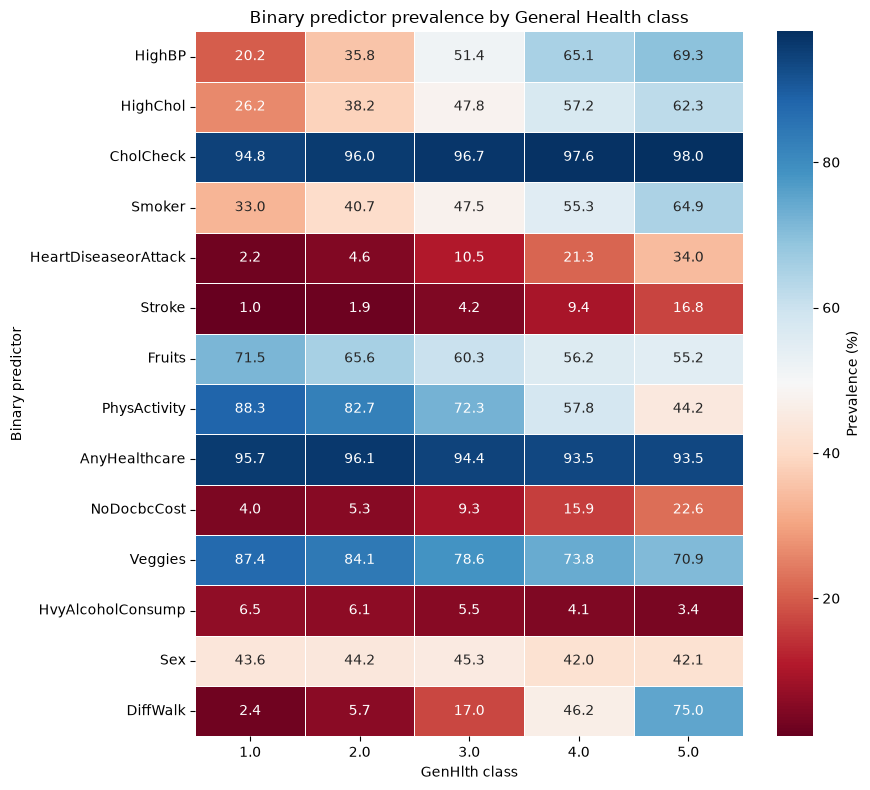

In [19]:
binary_prevalence = 100 * df.groupby('GenHlth')[binary_features].mean().T

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    binary_prevalence,
    annot=True,
    fmt='.1f',
    cmap='RdBu',
    linewidths=0.5,
    cbar_kws={'label': 'Prevalence (%)'},
    ax=ax,
)
ax.set_title('Binary predictor prevalence by General Health class')
ax.set_xlabel('GenHlth class')
ax.set_ylabel('Binary predictor')
plt.tight_layout()
plt.show()


,absolute_spearman_correlation
PhysHlth,0.452
DiffWalk,0.423
Income,0.354
HighBP,0.303
Diabetes_012,0.297
Education,0.276
BMI,0.257
PhysActivity,0.256
HeartDiseaseorAttack,0.242
MentHlth,0.238


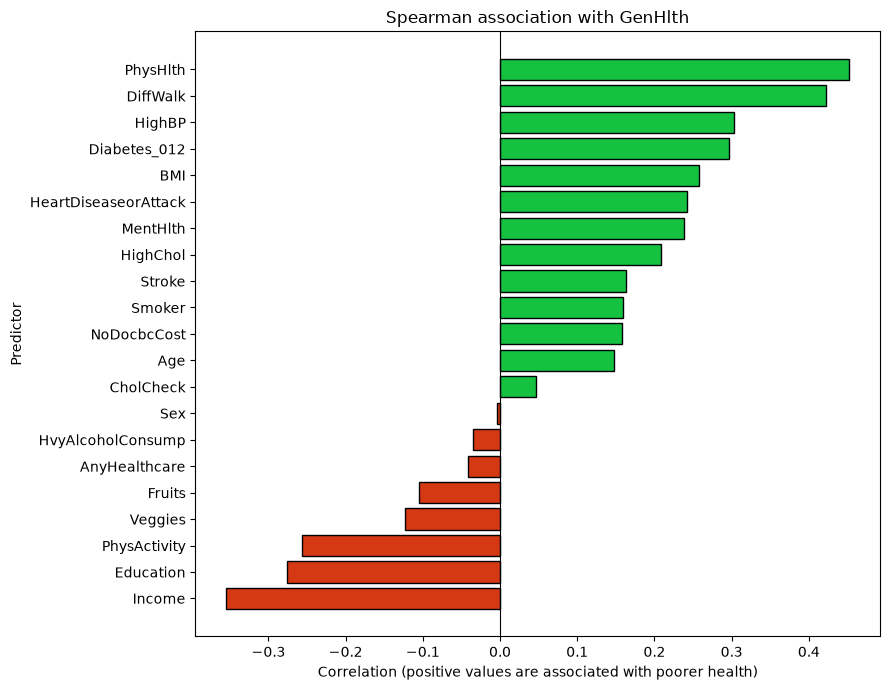

In [20]:
target_correlations = spearman_target_corr.sort_values()

display(
    target_correlations.abs()
    .sort_values(ascending=False)
    .rename('absolute_spearman_correlation')
    .to_frame()
    .round(3)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#D43913' if value < 0 else '#14C240' for value in target_correlations]
ax.barh(target_correlations.index, target_correlations.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman association with GenHlth')
ax.set_xlabel('Correlation (positive values are associated with poorer health)')
ax.set_ylabel('Predictor')
plt.tight_layout()
plt.show()

In [21]:
from scipy import stats
CLASSES = np.array([1, 2, 3, 4, 5])

def _cramers_v(chi2_stat, n, r, c):
    return float(np.sqrt(chi2_stat / (n * (min(r, c) - 1))))

def _kw_adjusted_h(h_stat, n, k):
    return float((h_stat - k + 1) / (n - k))

def _bh_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    if p.ndim != 1 or p.size == 0 or not np.isfinite(p).all() or np.any((p < 0) | (p > 1)):
        raise ValueError('pvalues must be a nonempty finite one-dimensional array in [0, 1].')
    order = np.argsort(p)
    adjusted = p[order] * len(p) / np.arange(1, len(p) + 1)
    adjusted = np.clip(np.minimum.accumulate(adjusted[::-1])[::-1], 0, 1)
    result = np.empty_like(adjusted)
    result[order] = adjusted
    return result

target = df['GenHlth']
n_total, k_classes = len(df), target.nunique()
rows = []
for feature in predictors:
    values = df[feature]
    if feature in binary_features:
        contingency = pd.crosstab(values, target)
        statistic, p_value, _, _ = stats.chi2_contingency(contingency)
        measure = _cramers_v(statistic, n_total, *contingency.shape)
        feature_type, test, measure_name = 'binary', 'chi-squared', "Cramer's V"
    elif feature in ordinal_features:
        statistic, p_value = stats.spearmanr(values, target)
        measure = abs(statistic)
        feature_type, test, measure_name = 'ordinal', 'Spearman rho', '|rho|'
    else:
        groups = [values[target == cls].to_numpy() for cls in CLASSES]
        statistic, p_value = stats.kruskal(*groups)
        measure = _kw_adjusted_h(statistic, n_total, k_classes)
        feature_type = 'count' if feature in count_features else 'continuous'
        test, measure_name = 'Kruskal-Wallis', 'epsilon^2'
    rows.append({
        'feature': feature, 'feature_type': feature_type, 'test': test,
        'statistic': float(statistic), 'p_value': float(p_value),
        'measure_name': measure_name, 'measure_value': float(measure),
        'signed_spearman': float(spearman_target_corr[feature]),
    })

association_tests = pd.DataFrame(rows)
association_tests['p_value_bh'] = _bh_adjust(association_tests['p_value'])
association_tests['significant_bh_0.05'] = association_tests['p_value_bh'] < 0.05
assert len(association_tests) == len(predictors) == 21
for measure_name, table in association_tests.groupby('measure_name', sort=False):
    print(f'Within-measure summary: {measure_name}')
    display(table.sort_values('measure_value', ascending=False).style.format({
        'statistic': '{:.3f}', 'measure_value': '{:.4f}', 'signed_spearman': '{:.4f}',
        'p_value': '{:.3e}', 'p_value_bh': '{:.3e}',
    }))

Within-measure summary: |rho|


,feature,feature_type,test,statistic,p_value,measure_name,measure_value,signed_spearman,p_value_bh,significant_bh_0.05
20,Income,ordinal,Spearman rho,-0.354,0.000e+00,|rho|,0.3543,-0.3543,0.000e+00,True
0,Diabetes_012,ordinal,Spearman rho,0.297,0.000e+00,|rho|,0.2971,0.2971,0.000e+00,True
19,Education,ordinal,Spearman rho,-0.276,0.000e+00,|rho|,0.2758,-0.2758,0.000e+00,True
18,Age,ordinal,Spearman rho,0.147,0.000e+00,|rho|,0.1472,0.1472,0.000e+00,True


Within-measure summary: Cramer's V


,feature,feature_type,test,statistic,p_value,measure_name,measure_value,signed_spearman,p_value_bh,significant_bh_0.05
16,DiffWalk,binary,chi-squared,63347.115,0.000e+00,Cramer's V,0.4997,0.4228,0.000e+00,True
1,HighBP,binary,chi-squared,23417.259,0.000e+00,Cramer's V,0.3038,0.3033,0.000e+00,True
7,HeartDiseaseorAttack,binary,chi-squared,19008.164,0.000e+00,Cramer's V,0.2737,0.2422,0.000e+00,True
8,PhysActivity,binary,chi-squared,18742.967,0.000e+00,Cramer's V,0.2718,-0.2562,0.000e+00,True
2,HighChol,binary,chi-squared,11184.247,0.000e+00,Cramer's V,0.2100,0.2086,0.000e+00,True
6,Stroke,binary,chi-squared,9596.374,0.000e+00,Cramer's V,0.1945,0.1637,0.000e+00,True
13,NoDocbcCost,binary,chi-squared,7742.862,0.000e+00,Cramer's V,0.1747,0.1576,0.000e+00,True
5,Smoker,binary,chi-squared,6777.154,0.000e+00,Cramer's V,0.1634,0.1590,0.000e+00,True
10,Veggies,binary,chi-squared,3898.476,0.000e+00,Cramer's V,0.1240,-0.1225,0.000e+00,True
9,Fruits,binary,chi-squared,2840.847,0.000e+00,Cramer's V,0.1058,-0.1055,0.000e+00,True


Within-measure summary: epsilon^2


,feature,feature_type,test,statistic,p_value,measure_name,measure_value,signed_spearman,p_value_bh,significant_bh_0.05
15,PhysHlth,count,Kruskal-Wallis,68567.421,0.000e+00,epsilon^2,0.2703,0.4518,0.000e+00,True
14,MentHlth,count,Kruskal-Wallis,18422.354,0.000e+00,epsilon^2,0.0726,0.2379,0.000e+00,True
4,BMI,continuous,Kruskal-Wallis,17797.471,0.000e+00,epsilon^2,0.0701,0.2573,0.000e+00,True


,feature,feature_type,test,measure_name,measure_value,strength,signed_spearman,direction,p_value_bh,significant_bh_0.05
0,DiffWalk,binary,chi-squared,Cramer's V,0.4997,large,0.4228,higher -> poorer health,0.0,True
1,Income,ordinal,Spearman rho,|rho|,0.3543,large,-0.3543,higher -> better health,0.0,True
2,HighBP,binary,chi-squared,Cramer's V,0.3038,large,0.3033,higher -> poorer health,0.0,True
3,Diabetes_012,ordinal,Spearman rho,|rho|,0.2971,medium,0.2971,higher -> poorer health,0.0,True
4,Education,ordinal,Spearman rho,|rho|,0.2758,medium,-0.2758,higher -> better health,0.0,True
5,HeartDiseaseorAttack,binary,chi-squared,Cramer's V,0.2737,medium,0.2422,higher -> poorer health,0.0,True
6,PhysActivity,binary,chi-squared,Cramer's V,0.2718,medium,-0.2562,higher -> better health,0.0,True
7,PhysHlth,count,Kruskal-Wallis,epsilon^2,0.2703,medium,0.4518,higher -> poorer health,0.0,True
8,HighChol,binary,chi-squared,Cramer's V,0.2100,medium,0.2086,higher -> poorer health,0.0,True
9,Stroke,binary,chi-squared,Cramer's V,0.1945,medium,0.1637,higher -> poorer health,0.0,True


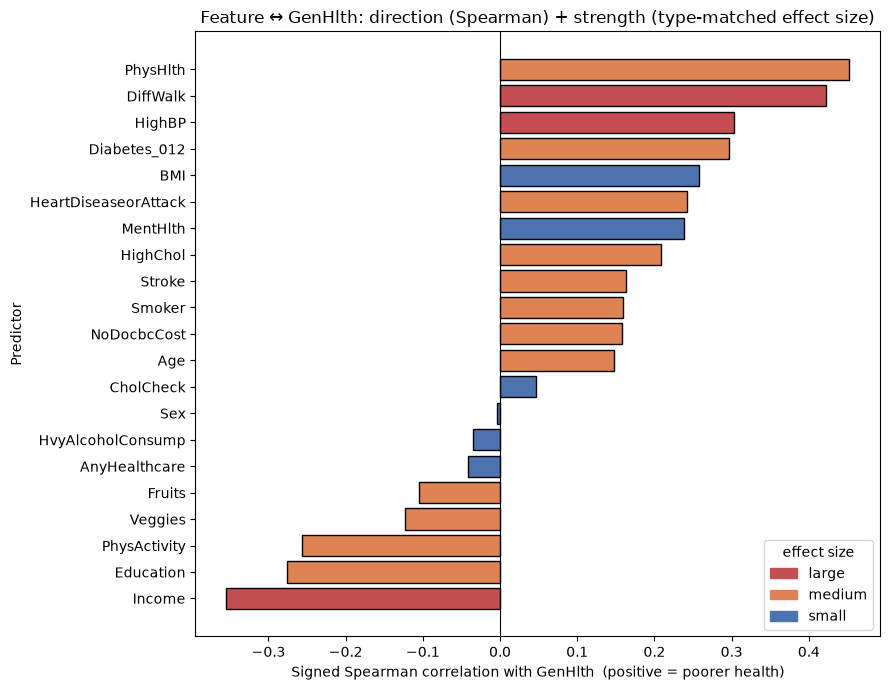

Large effects  (>= 0.30): ['DiffWalk', 'Income', 'HighBP']
Medium effects (0.10-0.30): ['Diabetes_012', 'Education', 'HeartDiseaseorAttack', 'PhysActivity', 'PhysHlth', 'HighChol', 'Stroke', 'NoDocbcCost', 'Smoker', 'Age', 'Veggies', 'Fruits']
Small effects  (< 0.10): ['MentHlth', 'BMI', 'CholCheck', 'AnyHealthcare', 'HvyAlcoholConsump', 'Sex']


In [22]:
feature_target = (
    association_tests[['feature', 'feature_type', 'test',
                       'measure_name', 'measure_value',
                       'p_value_bh', 'significant_bh_0.05']]
    .copy()
)
feature_target['signed_spearman'] = feature_target['feature'].map(spearman_target_corr)
feature_target['direction'] = np.where(
    feature_target['signed_spearman'] > 0, 'higher -> poorer health',
    np.where(feature_target['signed_spearman'] < 0, 'higher -> better health', 'no direction'),
)


def _strength(v):
    if v >= 0.3:
        return 'large'
    if v >= 0.1:
        return 'medium'
    return 'small'


feature_target['strength'] = feature_target['measure_value'].apply(_strength)
feature_target = feature_target.sort_values('measure_value', ascending=False).reset_index(drop=True)

display(
    feature_target[['feature', 'feature_type', 'test', 'measure_name',
                    'measure_value', 'strength', 'signed_spearman', 'direction',
                    'p_value_bh', 'significant_bh_0.05']]
    .round({'measure_value': 4, 'signed_spearman': 4, 'p_value_bh': 6})
)

_strength_color = {'large': '#C44E52', 'medium': '#DD8452', 'small': '#4C72B0'}
plot_df = feature_target.sort_values('signed_spearman')
fig, ax = plt.subplots(figsize=(9, 7))
colors = [_strength_color[s] for s in plot_df['strength']]
ax.barh(plot_df['feature'], plot_df['signed_spearman'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Signed Spearman correlation with GenHlth  (positive = poorer health)')
ax.set_ylabel('Predictor')
ax.set_title('Feature ↔ GenHlth: direction (Spearman) + strength (type-matched effect size)')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in _strength_color.values()]
ax.legend(handles, list(_strength_color.keys()), title='effect size', loc='lower right')
plt.tight_layout()
plt.show()

print('Large effects  (>= 0.30):', feature_target.loc[feature_target['strength'] == 'large', 'feature'].tolist())
print('Medium effects (0.10-0.30):', feature_target.loc[feature_target['strength'] == 'medium', 'feature'].tolist())
print('Small effects  (< 0.10):', feature_target.loc[feature_target['strength'] == 'small', 'feature'].tolist())


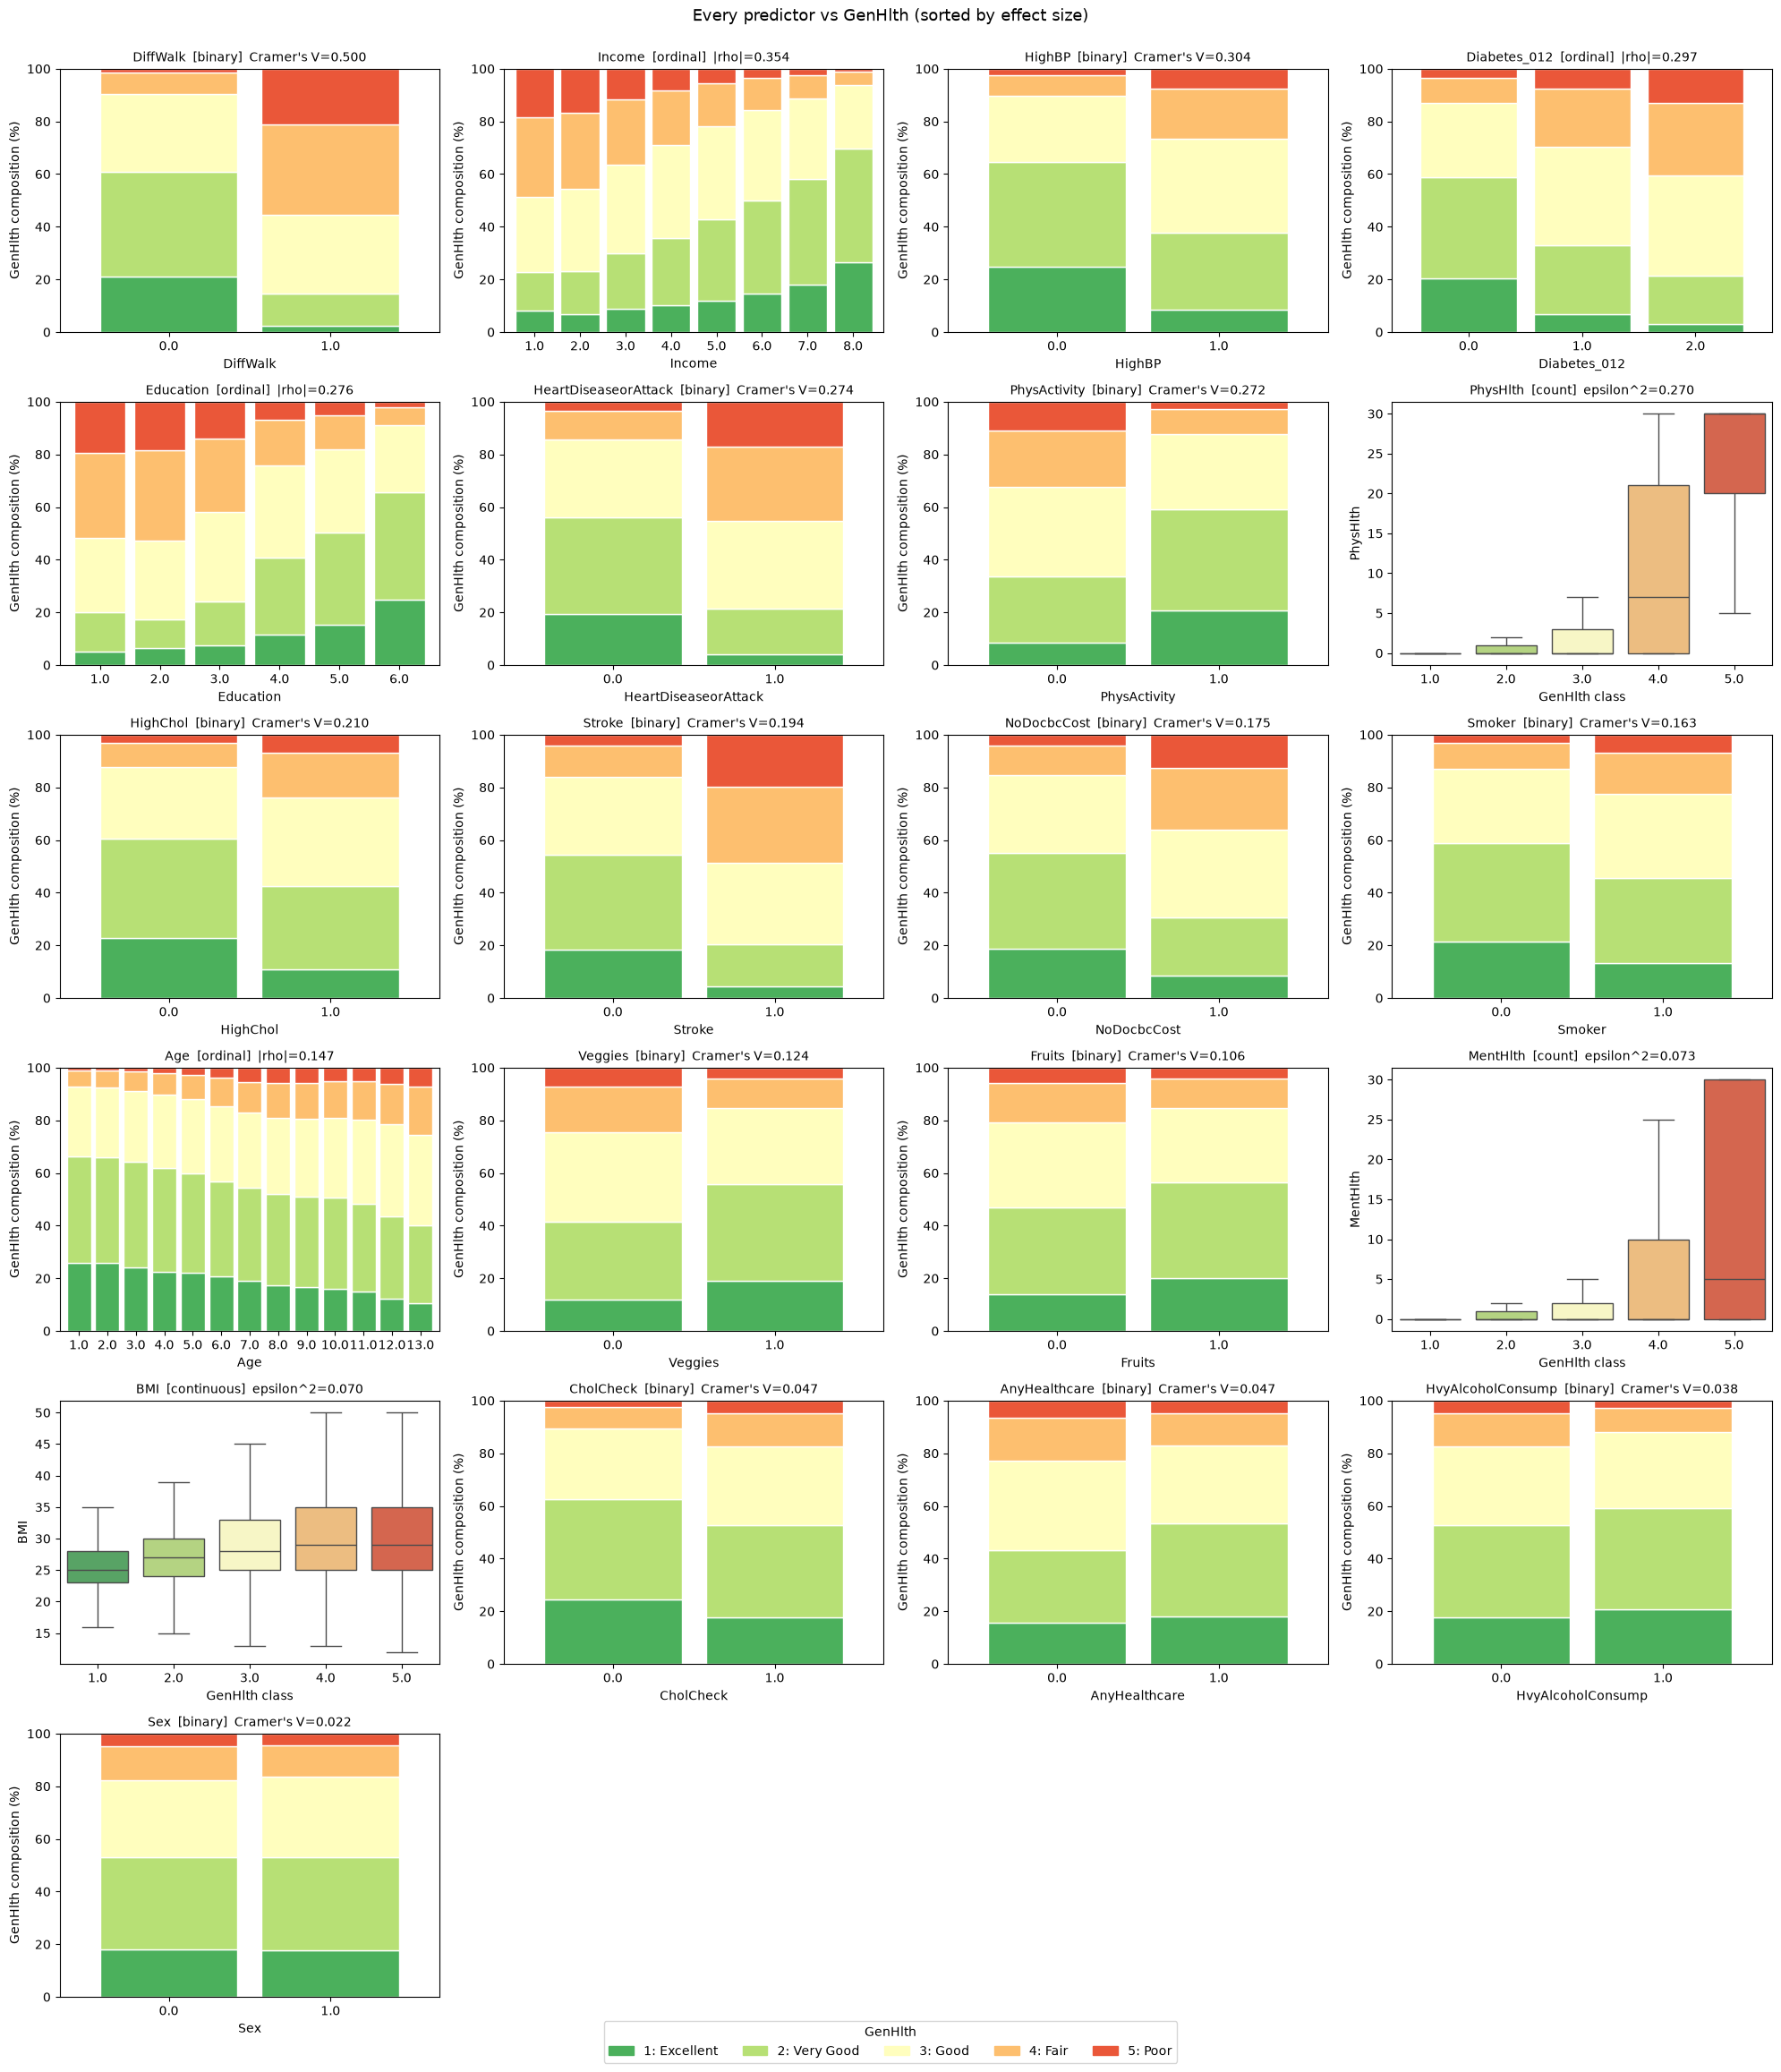

In [23]:
_ORDER = association_tests.sort_values('measure_value', ascending=False)['feature'].tolist()

n_cols = 4
n_rows = int(np.ceil(len(_ORDER) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
axes = axes.ravel()

class_palette = sns.color_palette('RdYlGn_r', 5)
class_labels = [f'{c}: {class_names[c]}' for c in CLASSES]

for ax, feature in zip(axes, _ORDER):
    ftype = (
        'binary' if feature in binary_features
        else 'ordinal' if feature in ordinal_features
        else 'count' if feature in count_features
        else 'continuous'
    )
    row = association_tests.loc[association_tests['feature'] == feature].iloc[0]
    effect = row['measure_value']
    effect_name = row['measure_name']

    if ftype in ('binary', 'ordinal'):
        ct = pd.crosstab(df[feature], df['GenHlth'], normalize='index') * 100
        ct = ct.reindex(columns=CLASSES, fill_value=0)
        ct.plot(kind='bar', stacked=True, ax=ax, color=class_palette,
                width=0.85, legend=False, edgecolor='white')
        ax.set_xlabel(feature)
        ax.set_ylabel('GenHlth composition (%)')
        ax.set_ylim(0, 100)
        ax.tick_params(axis='x', rotation=0)
    else:
        sns.boxplot(
            data=df, x='GenHlth', y=feature,
            hue='GenHlth', palette=class_palette,
            showfliers=False, legend=False, ax=ax,
        )
        ax.set_xlabel('GenHlth class')
        ax.set_ylabel(feature)

    ax.set_title(f'{feature}  [{ftype}]  {effect_name}={effect:.3f}', fontsize=10)

for ax in axes[len(_ORDER):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=class_palette[k]) for k in range(5)]
fig.legend(handles, class_labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.01), title='GenHlth')
fig.suptitle('Every predictor vs GenHlth (sorted by effect size)', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


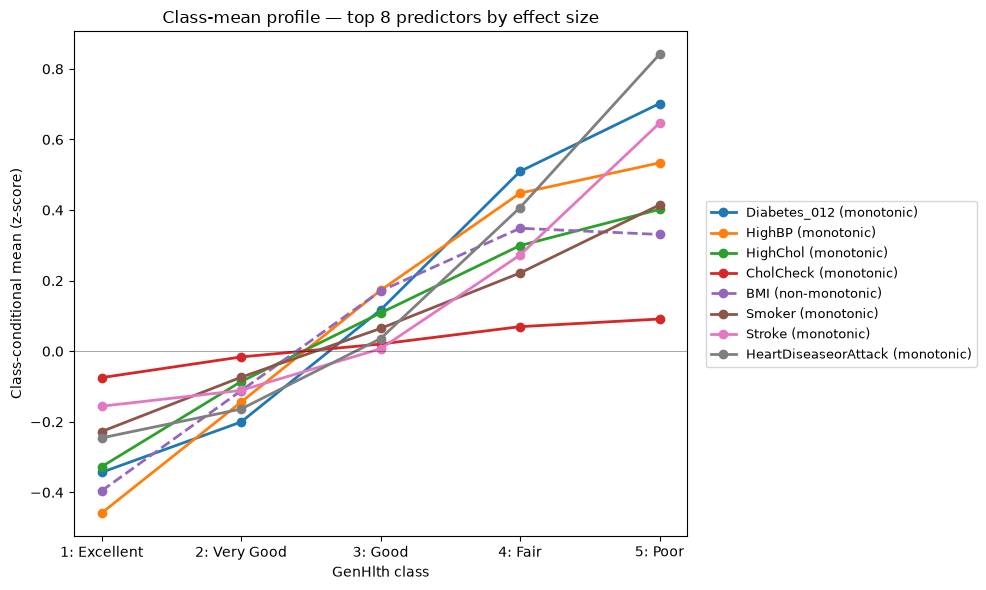

Monotonic across GenHlth 1->5: 7 / 8  (linear-friendly)
Non-monotonic:                1 / 8  (need nonlinear model to exploit)


In [24]:
TOP_K_PROFILE = 8
top_features = association_tests.head(TOP_K_PROFILE)['feature'].tolist()

feature_z = (df[top_features] - df[top_features].mean()) / df[top_features].std()
class_profile = feature_z.groupby(df['GenHlth']).mean().reindex(CLASSES)

def _monotonic(series):
    diffs = np.diff(series.to_numpy())
    return bool(np.all(diffs >= -1e-9) or np.all(diffs <= 1e-9))

monotonic_flags = {f: _monotonic(class_profile[f]) for f in top_features}

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('tab10', len(top_features))
for color, feature in zip(palette, top_features):
    style = '-' if monotonic_flags[feature] else '--'
    label = f"{feature} ({'monotonic' if monotonic_flags[feature] else 'non-monotonic'})"
    ax.plot(class_profile.index, class_profile[feature], style, marker='o',
            color=color, label=label, linewidth=2)
ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
ax.set_xticks(class_profile.index)
ax.set_xticklabels([f'{i}: {class_names[i]}' for i in class_profile.index])
ax.set_xlabel('GenHlth class')
ax.set_ylabel('Class-conditional mean (z-score)')
ax.set_title(f'Class-mean profile — top {TOP_K_PROFILE} predictors by effect size')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

n_mono = sum(monotonic_flags.values())
print(f'Monotonic across GenHlth 1->5: {n_mono} / {TOP_K_PROFILE}  '
      f'(linear-friendly)')
print(f'Non-monotonic:                {TOP_K_PROFILE - n_mono} / {TOP_K_PROFILE}  '
      f'(need nonlinear model to exploit)')


centroids shape: (5, 21)  (5 classes x 21 predictors)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1: Excellent,-0.343,-0.459,-0.327,-0.075,-0.396,-0.228,-0.156,-0.246,0.295,0.168,...,0.039,0.030,-0.159,-0.260,-0.388,-0.386,-0.009,-0.216,0.330,0.371
2: Very Good,-0.201,-0.144,-0.086,-0.016,-0.112,-0.074,-0.111,-0.164,0.164,0.045,...,0.022,0.047,-0.111,-0.174,-0.311,-0.297,0.003,-0.075,0.189,0.256
3: Good,0.117,0.173,0.108,0.020,0.171,0.064,0.007,0.036,-0.079,-0.064,...,-0.007,-0.031,0.032,-0.016,-0.097,0.004,0.026,0.070,-0.119,-0.101
4: Fair,0.510,0.448,0.299,0.070,0.348,0.222,0.273,0.407,-0.415,-0.150,...,-0.065,-0.074,0.269,0.454,0.820,0.786,-0.041,0.234,-0.475,-0.634
5: Poor,0.702,0.534,0.402,0.091,0.331,0.415,0.646,0.841,-0.733,-0.171,...,-0.097,-0.075,0.510,1.173,2.211,1.555,-0.039,0.317,-0.643,-0.989


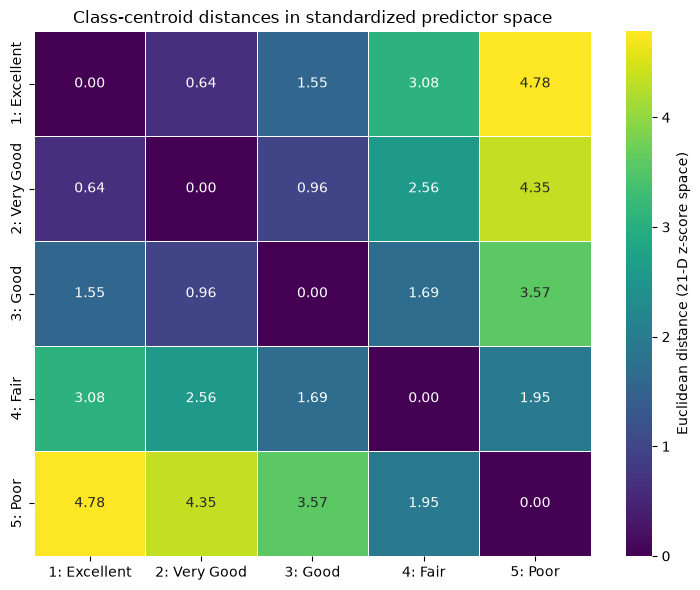

Mean centroid distance, class gap = 1:  1.308
Mean centroid distance, class gap >= 2: 3.316


In [25]:
predictor_z = (df[predictors] - df[predictors].mean()) / df[predictors].std()
centroid_table = predictor_z.groupby(df['GenHlth']).mean().reindex(CLASSES)
centroid_table.index = [f'{i}: {class_names[i]}' for i in CLASSES]
centroids = centroid_table.to_numpy()

print(f'centroids shape: {centroids.shape}  '
      f'(5 classes x {centroids.shape[1]} predictors)')
display(centroid_table.round(3))

diff = centroids[:, None, :] - centroids[None, :, :]
centroid_distances = pd.DataFrame(
    np.sqrt((diff ** 2).sum(axis=-1)),
    index=centroid_table.index,
    columns=centroid_table.index,
)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(centroid_distances, annot=True, fmt='.2f', cmap='viridis',
            linewidths=0.4, cbar_kws={'label': 'Euclidean distance (21-D z-score space)'},
            ax=ax)
ax.set_title('Class-centroid distances in standardized predictor space')
plt.tight_layout()
plt.show()

adjacent_pairs = [(i, j) for i in range(5) for j in range(i + 1, 5) if j - i == 1]
nonadjacent_pairs = [(i, j) for i in range(5) for j in range(i + 1, 5) if j - i >= 2]
adjacent_mean = np.mean([centroid_distances.iat[i, j] for i, j in adjacent_pairs])
nonadjacent_mean = np.mean([centroid_distances.iat[i, j] for i, j in nonadjacent_pairs])
print(f'Mean centroid distance, class gap = 1:  {adjacent_mean:.3f}')
print(f'Mean centroid distance, class gap >= 2: {nonadjacent_mean:.3f}')


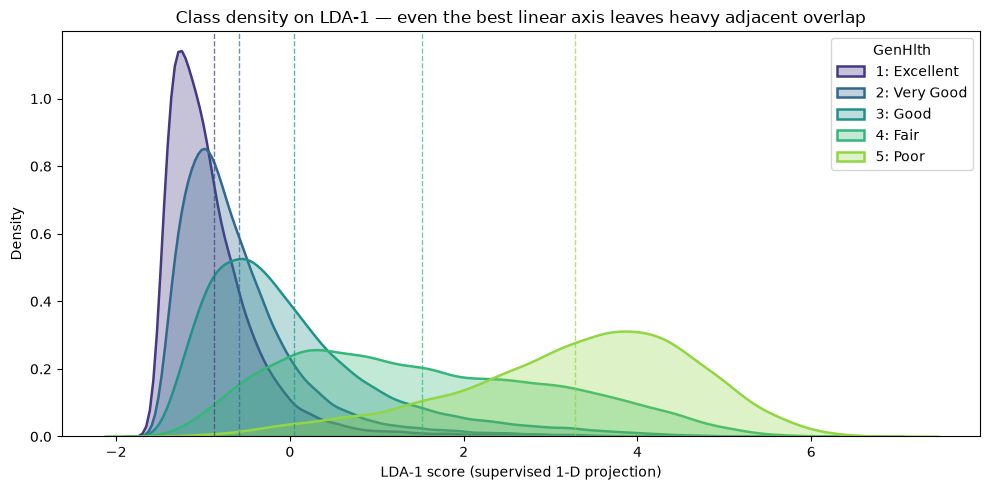

,class,lda1_mean,lda1_std,adjacent_gap
0,1: Excellent,-0.874,0.617,NaN
1,2: Very Good,-0.581,0.749,0.293
2,3: Good,0.047,1.083,0.628
3,4: Fair,1.524,1.537,1.477
4,5: Poor,3.285,1.381,1.761


LDA-1 span from class 1 to class 5:      4.159
Pooled within-class LDA-1 std:           1.130
Class-1 to class-5 separation (sigma):   3.68


In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
lda_scores = lda.fit_transform(predictor_z, df['GenHlth']).ravel()

mean_by_class = np.array([lda_scores[df['GenHlth'].to_numpy() == cls].mean() for cls in CLASSES])
if mean_by_class[0] > mean_by_class[-1]:
    lda_scores = -lda_scores
    mean_by_class = -mean_by_class

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', 5)
for cls, color in zip(CLASSES, palette):
    class_scores = lda_scores[df['GenHlth'].to_numpy() == cls]
    sns.kdeplot(class_scores, ax=ax, color=color, fill=True, alpha=0.3,
                label=f'{cls}: {class_names[cls]}', linewidth=1.8)
for cls, mean_score, color in zip(CLASSES, mean_by_class, palette):
    ax.axvline(mean_score, color=color, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('LDA-1 score (supervised 1-D projection)')
ax.set_ylabel('Density')
ax.set_title('Class density on LDA-1 — even the best linear axis leaves heavy adjacent overlap')
ax.legend(title='GenHlth', loc='upper right')
plt.tight_layout()
plt.show()

lda_class_stats = pd.DataFrame({
    'class': [f'{cls}: {class_names[cls]}' for cls in CLASSES],
    'lda1_mean': mean_by_class,
    'lda1_std': [lda_scores[df['GenHlth'].to_numpy() == cls].std() for cls in CLASSES],
})
lda_class_stats['adjacent_gap'] = lda_class_stats['lda1_mean'].diff()
display(lda_class_stats.round(3))

pooled_std = float(np.sqrt(np.mean(lda_class_stats['lda1_std'] ** 2)))
span_1_to_5 = float(mean_by_class[-1] - mean_by_class[0])
print(f'LDA-1 span from class 1 to class 5:      {span_1_to_5:.3f}')
print(f'Pooled within-class LDA-1 std:           {pooled_std:.3f}')
print(f'Class-1 to class-5 separation (sigma):   {span_1_to_5 / pooled_std:.2f}')


In [27]:
from sklearn.model_selection import train_test_split

SAMPLE_SEED = 42
SAMPLE_SIZE = 20_000
TEST_SIZE = 0.30

sample_df, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['GenHlth'],
    random_state=SAMPLE_SEED,
    test_size=TEST_SIZE,
)
sample_df = sample_df.sort_index()

print(f'Sample rows: {len(sample_df):,}')
print(f'Random seed: {SAMPLE_SEED}')
sample_df

Sample rows: 20,000
Random seed: 42


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
26,2.0,1.0,1.0,1.0,37.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,5.0,0.0,0.0,1.0,1.0,10.0,6.0,5.0
27,2.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,12.0,2.0,4.0
38,0.0,0.0,0.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,4.0,5.0,3.0
61,0.0,1.0,0.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,5.0,1.0,0.0,11.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253620,0.0,1.0,0.0,1.0,23.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,3.0,0.0,30.0,0.0,1.0,7.0,2.0,1.0
253631,0.0,0.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,1.0,9.0,4.0,3.0
253641,0.0,0.0,1.0,1.0,26.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,12.0,4.0,4.0
253643,0.0,0.0,1.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,4.0,2.0


,label,full_count,full_percent,sample_count,sample_percent,difference_percentage_points
GenHlth,,,,,,
1.0,Excellent,45299,17.8567,3571,17.855,-0.0017
2.0,Very Good,89084,35.1167,7023,35.115,-0.0017
3.0,Good,75646,29.8195,5964,29.820,0.0005
4.0,Fair,31570,12.4448,2489,12.445,0.0002
5.0,Poor,12081,4.7623,953,4.765,0.0027


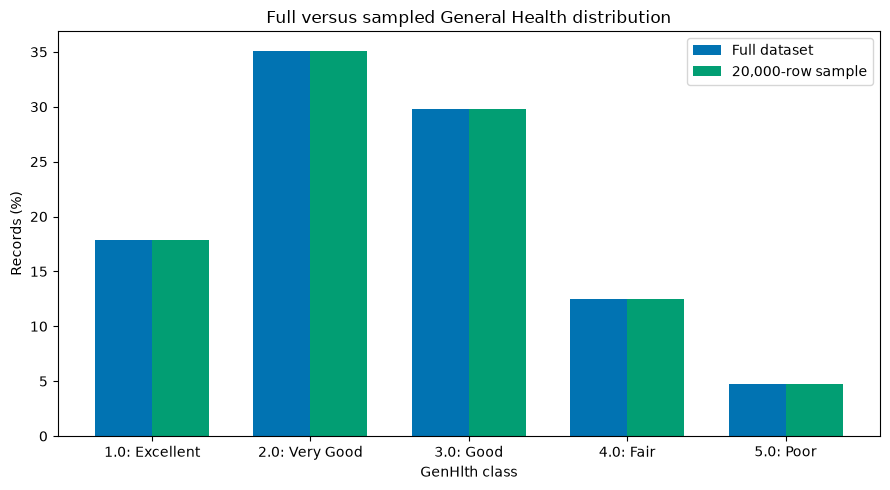

In [28]:
sample_target_table = sample_df['GenHlth'].value_counts().sort_index().rename('sample_count').to_frame()
sample_target_table['sample_percent'] = 100 * sample_target_table['sample_count'] / len(sample_df)

class_comparison = target_table[['label', 'count', 'percent']].rename(
    columns={'count': 'full_count', 'percent': 'full_percent'}
).join(sample_target_table)
class_comparison['difference_percentage_points'] = (
    class_comparison['sample_percent'] - class_comparison['full_percent']
)

display(class_comparison.round(4))

x = np.arange(len(class_comparison))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('colorblind', 10)
ax.bar(x - width / 2, class_comparison['full_percent'], width, label='Full dataset', color=colors[0])
ax.bar(x + width / 2, class_comparison['sample_percent'], width, label='20,000-row sample', color=colors[2])
ax.set_xticks(x, [f'{number}: {class_names[number]}' for number in class_comparison.index])
ax.set_title('Full versus sampled General Health distribution')
ax.set_xlabel('GenHlth class')
ax.set_ylabel('Records (%)')
ax.legend()
plt.tight_layout()
plt.show()


,full_mean,sample_mean,standardized_difference,absolute_standardized_difference
Age,8.0321,7.9956,-0.0120,0.0120
Fruits,0.6343,0.6397,0.0113,0.0113
NoDocbcCost,0.0842,0.0812,-0.0105,0.0105
Stroke,0.0406,0.0387,-0.0095,0.0095
Income,6.0539,6.0725,0.0090,0.0090
Diabetes_012,0.2969,0.2912,-0.0083,0.0083
CholCheck,0.9627,0.9612,-0.0078,0.0078
HeartDiseaseorAttack,0.0942,0.0962,0.0067,0.0067
Sex,0.4403,0.4432,0.0057,0.0057
HighBP,0.4290,0.4268,-0.0044,0.0044


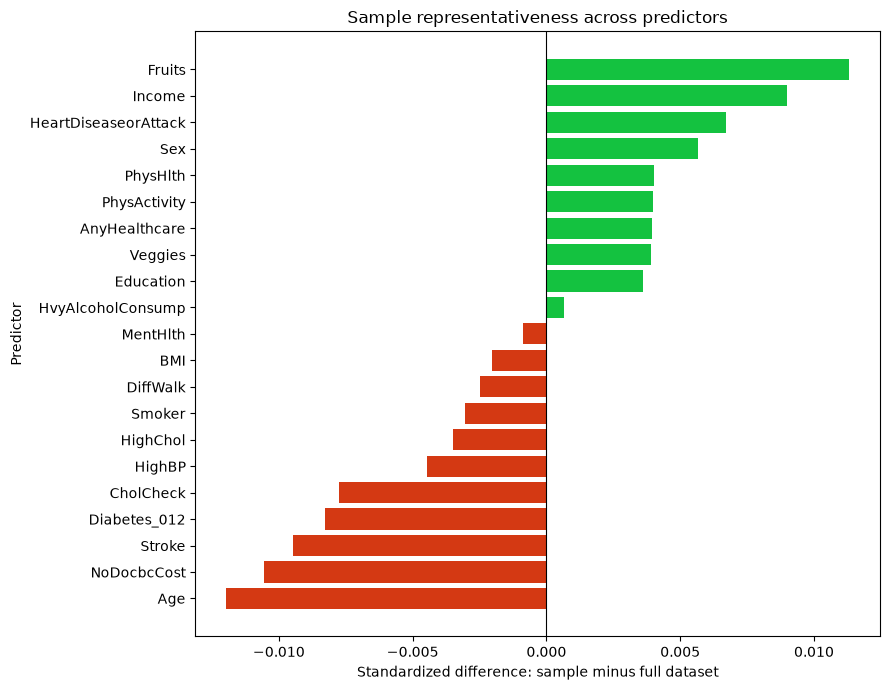

In [29]:
full_means = df[predictors].mean()
sample_means = sample_df[predictors].mean()
full_standard_deviations = df[predictors].std()

feature_comparison = pd.DataFrame({
    'full_mean': full_means,
    'sample_mean': sample_means,
})
feature_comparison['standardized_difference'] = (
    feature_comparison['sample_mean'] - feature_comparison['full_mean']
) / full_standard_deviations
feature_comparison['absolute_standardized_difference'] = (
    feature_comparison['standardized_difference'].abs()
)
feature_comparison = feature_comparison.sort_values(
    'absolute_standardized_difference', ascending=False
)

display(feature_comparison.round(4))

plot_data = feature_comparison.sort_values('standardized_difference')
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#D43913" if value < 0 else "#14C240" for value in plot_data['standardized_difference']]
ax.barh(plot_data.index, plot_data['standardized_difference'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sample representativeness across predictors')
ax.set_xlabel('Standardized difference: sample minus full dataset')
ax.set_ylabel('Predictor')
plt.tight_layout()
plt.show()


In [30]:
sample_audit = pd.Series({
    'rows': len(sample_df),
    'columns': sample_df.shape[1],
    'missing_values': int(sample_df.isna().sum().sum()),
    'duplicate_rows': int(sample_df.duplicated().sum()),
    'classes_present': sample_df['GenHlth'].nunique(),
    'largest_class_difference_percentage_points': (
        class_comparison['difference_percentage_points'].abs().max()
    ),
    'largest_predictor_standardized_difference': (
        feature_comparison['absolute_standardized_difference'].max()
    ),
})

display(sample_audit.to_frame('value').round(6))


sample_quality = pd.DataFrame({
    'feature_type': quality_table['feature_type'],
    'missing': sample_df.isna().sum(),
    'unique_values': sample_df.nunique(),
    'minimum': sample_df.min(),
    'q25': sample_df.quantile(0.25),
    'median': sample_df.median(),
    'q75': sample_df.quantile(0.75),
    'maximum': sample_df.max(),
    'mean': sample_df.mean(),
    'standard_deviation': sample_df.std(),
})
display(sample_quality.round(3))


,value
rows,20000.000000
columns,22.000000
missing_values,0.000000
duplicate_rows,411.000000
classes_present,5.000000
largest_class_difference_percentage_points,0.002701
largest_predictor_standardized_difference,0.011957


,feature_type,missing,unique_values,minimum,q25,median,q75,maximum,mean,standard_deviation
Diabetes_012,ordinal,0,3,0.0,0.0,0.0,0.0,2.0,0.291,0.693
HighBP,binary,0,2,0.0,0.0,0.0,1.0,1.0,0.427,0.495
HighChol,binary,0,2,0.0,0.0,0.0,1.0,1.0,0.422,0.494
CholCheck,binary,0,2,0.0,1.0,1.0,1.0,1.0,0.961,0.193
BMI,continuous,0,70,12.0,24.0,27.0,31.0,98.0,28.369,6.582
Smoker,binary,0,2,0.0,0.0,0.0,1.0,1.0,0.442,0.497
Stroke,binary,0,2,0.0,0.0,0.0,0.0,1.0,0.039,0.193
HeartDiseaseorAttack,binary,0,2,0.0,0.0,0.0,0.0,1.0,0.096,0.295
PhysActivity,binary,0,2,0.0,1.0,1.0,1.0,1.0,0.758,0.428
Fruits,binary,0,2,0.0,0.0,1.0,1.0,1.0,0.640,0.480


## Hypothesis (pre)
to be written

In [31]:
MODEL_SEED = 42
TEST_SIZE = 0.30

X = sample_df.drop(columns='GenHlth')
y = sample_df['GenHlth'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=MODEL_SEED,
)

assert X_train.index.is_unique
assert X_test.index.is_unique
assert set(X_train.index).isdisjoint(set(X_test.index))
assert len(X_train) + len(X_test) == len(sample_df)

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()
split_summary = pd.DataFrame({
    'class_name': pd.Series(class_names),
    'train_count': train_counts,
    'train_percent': 100 * train_counts / len(y_train),
    'test_count': test_counts,
    'test_percent': 100 * test_counts / len(y_test),
})

print(f'Training rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')
print(f'Split seed: {MODEL_SEED}')
display(split_summary.round(3))

train_profiles = pd.MultiIndex.from_frame(X_train)
test_profiles = pd.MultiIndex.from_frame(X_test)
matching_predictors = test_profiles.isin(train_profiles)
train_labeled = pd.MultiIndex.from_frame(X_train.assign(GenHlth=y_train))
test_labeled = pd.MultiIndex.from_frame(X_test.assign(GenHlth=y_test))
matching_labeled = test_labeled.isin(train_labeled)
profile_overlap = pd.Series({
    'test_rows': len(X_test),
    'test_rows_with_predictors_seen_in_train': int(matching_predictors.sum()),
    'test_rows_with_predictors_and_label_seen_in_train': int(matching_labeled.sum()),
})
display(profile_overlap.to_frame('count'))


Training rows: 14,000
Test rows: 6,000
Split seed: 42


,class_name,train_count,train_percent,test_count,test_percent
1,Excellent,2500,17.857,1071,17.850
2,Very Good,4916,35.114,2107,35.117
3,Good,4175,29.821,1789,29.817
4,Fair,1742,12.443,747,12.450
5,Poor,667,4.764,286,4.767


,count
test_rows,6000
test_rows_with_predictors_seen_in_train,330
test_rows_with_predictors_and_label_seen_in_train,182


In [32]:
from sklearn.model_selection import StratifiedKFold

CV_FOLDS = 5
CV_SEED = 42

CLASS_NAMES = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']
CLASSES = np.array([1, 2, 3, 4, 5])

inner_splitter = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=CV_SEED,
)
cv_splits = list(inner_splitter.split(X_train, y_train))

split_counts = pd.DataFrame({
    'class_name': CLASS_NAMES,
    'train_count': y_train.value_counts().reindex(CLASSES).fillna(0).astype(int),
    'test_count': y_test.value_counts().reindex(CLASSES).fillna(0).astype(int),
})
split_counts['train_percent'] = 100 * split_counts['train_count'] / len(y_train)
split_counts['test_percent'] = 100 * split_counts['test_count'] / len(y_test)

fold_counts = []
for fold, (fit_pos, val_pos) in enumerate(cv_splits, start=1):
    for role, positions in [('fit', fit_pos), ('validation', val_pos)]:
        counts = y_train.iloc[positions].value_counts().reindex(CLASSES, fill_value=0)
        for label in CLASSES:
            fold_counts.append({
                'fold': fold,
                'role': role,
                'class': int(label),
                'count': int(counts[label]),
                'percent': 100 * counts[label] / len(positions),
            })
display(split_counts.round(3))
display(pd.DataFrame(fold_counts).round(3))

,class_name,train_count,test_count,train_percent,test_percent
GenHlth,,,,,
1,Excellent,2500,1071,17.857,17.850
2,Very Good,4916,2107,35.114,35.117
3,Good,4175,1789,29.821,29.817
4,Fair,1742,747,12.443,12.450
5,Poor,667,286,4.764,4.767


,fold,role,class,count,percent
0,1,fit,1,2000,17.857
1,1,fit,2,3932,35.107
2,1,fit,3,3340,29.821
3,1,fit,4,1394,12.446
4,1,fit,5,534,4.768
5,1,validation,1,500,17.857
6,1,validation,2,984,35.143
7,1,validation,3,835,29.821
8,1,validation,4,348,12.429
9,1,validation,5,133,4.750


In [33]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.tree import DecisionTreeClassifier

In [34]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42).fit(X_train, y_train)
yp = dummy.predict(X_test)

print('Majority-class baseline:')
print(f'  accuracy         : {accuracy_score(y_test, yp):.4f}')
print(f'  macro F1         : {f1_score(y_test, yp, average="macro", zero_division=0):.4f}')
print(f'  balanced accuracy: {balanced_accuracy_score(y_test, yp):.4f}')

y_train_shuffled = y_train.sample(frac=1, random_state=42).to_numpy()
dt_shuffled = DecisionTreeClassifier(max_depth=6, random_state=42).fit(X_train, y_train_shuffled)
yp_shuffled = dt_shuffled.predict(X_test)

print('Shuffled-label DT:')
print(f'  accuracy: {accuracy_score(y_test, yp_shuffled):.4f}')
print(f'  macro F1: {f1_score(y_test, yp_shuffled, average="macro", zero_division=0):.4f}')
print(f'  balanced accuracy: {balanced_accuracy_score(y_test, yp_shuffled):.4f}')

Majority-class baseline:
  accuracy         : 0.3512
  macro F1         : 0.1040
  balanced accuracy: 0.2000
Shuffled-label DT:
  accuracy: 0.3260
  macro F1: 0.1327
  balanced accuracy: 0.1908


In [35]:
import time

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SCORING = 'f1_macro'  

results = []


def make_model_pipeline(model, needs_scaling):
    if needs_scaling:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return Pipeline([('model', model)])


def time_fit_predict(estimator, X_fit, y_fit, X_predict):
    t0 = time.perf_counter()
    estimator.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = estimator.predict(X_predict)
    predict_seconds = time.perf_counter() - t0

    return fit_seconds, predict_seconds, y_pred


In [36]:
def confusion_diagnostics(y_true, y_pred, classes=CLASSES):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    total = cm.sum()
    n_classes = len(classes)

    diag_mass = float(np.trace(cm)) / total
    adjacent_mass = 0
    far_mass = 0
    for i in range(n_classes):
        for j in range(n_classes):
            if i == j:
                continue
            distance = abs(i - j)
            if distance == 1:
                adjacent_mass += cm[i, j]
            else:
                far_mass += cm[i, j]
    adjacent_mass = float(adjacent_mass) / total
    far_mass = float(far_mass) / total

    with np.errstate(divide='ignore', invalid='ignore'):
        cm_normalized = cm / cm.sum(axis=1, keepdims=True)
        cm_normalized = np.nan_to_num(cm_normalized)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=classes, zero_division=0,
    )
    per_class = pd.DataFrame({
        'class': [f'{c}: {class_names[c]}' for c in classes],
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
    })

    return {
        'cm': cm,
        'cm_normalized': cm_normalized,
        'diagonal_mass': diag_mass,
        'adjacent_mass': adjacent_mass,
        'diagonal_pm1_mass': diag_mass + adjacent_mass,
        'far_mass': far_mass,
        'per_class': per_class,
    }


def evaluate_model(estimator, X_train, y_train, X_test, y_test, name, notes=''):
    fit_seconds, predict_seconds, y_pred = time_fit_predict(
        estimator, X_train, y_train, X_test,
    )

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    diag = confusion_diagnostics(y_test, y_pred)

    record = {
        'model': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'balanced_accuracy': bal_acc,
        'diagonal_mass': diag['diagonal_mass'],
        'adjacent_mass': diag['adjacent_mass'],
        'diagonal_pm1_mass': diag['diagonal_pm1_mass'],
        'far_mass': diag['far_mass'],
        'fit_seconds': fit_seconds,
        'predict_seconds': predict_seconds,
        'notes': notes,
    }
    return record, diag, y_pred

In [37]:
def cv_complexity_curve(pipeline_factory, X, y, param_values, cv=None, scoring=SCORING, n_jobs=-1):

    if cv is None:
        cv = inner_splitter

    param_values = list(param_values)
    if len(param_values) < 3:
        raise ValueError(
            f'at least three hyperparameter values are required to characterise the curve; '
            f'got {len(param_values)}: {param_values}'
        )
    seen = []
    for value in param_values:
        if any(value == prior for prior in seen):
            raise ValueError(
                f'duplicate hyperparameter values are not allowed; got: {param_values}'
            )
        seen.append(value)

    train_means, train_stds, val_means, val_stds = [], [], [], []
    for value in param_values:
        estimator = pipeline_factory(value)
        cv_result = cross_validate(
            estimator, X, y,
            cv=cv, scoring=scoring, n_jobs=n_jobs,
            return_train_score=True,
        )
        train_means.append(cv_result['train_score'].mean())
        train_stds.append(cv_result['train_score'].std())
        val_means.append(cv_result['test_score'].mean())
        val_stds.append(cv_result['test_score'].std())

    train_means = np.array(train_means)
    val_means = np.array(val_means)
    best_idx = int(np.argmax(val_means))
    return {
        'param_values': param_values,
        'train_mean': train_means,
        'train_std': np.array(train_stds),
        'val_mean': val_means,
        'val_std': np.array(val_stds),
        'best_index': best_idx,
        'best_value': param_values[best_idx],
        'best_val_score': float(val_means[best_idx]),
    }


def cv_learning_curve(estimator_factory, X, y, train_sizes, cv=None, scoring=SCORING, n_jobs=-1):

    x_has_index = hasattr(X, 'index')
    y_has_index = hasattr(y, 'index')
    if x_has_index != y_has_index:
        raise TypeError(
            'X and y must both be pandas objects or both be array-like; got mixed types.'
        )
    if x_has_index and y_has_index:
        if not X.index.equals(y.index):
            raise ValueError(
                'X.index and y.index differ; refusing to reindex silently. '
                'Align inputs upstream (they must refer to the same observations in the same order).'
            )
    if len(X) != len(y):
        raise ValueError(f'X and y have different lengths ({len(X)} vs {len(y)}).')

    if cv is None:
        cv = inner_splitter

    estimator = estimator_factory()
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=cv, scoring=scoring, n_jobs=n_jobs,
        shuffle=False,
    )
    return {
        'sizes': sizes,
        'train_mean': train_scores.mean(axis=1),
        'train_std': train_scores.std(axis=1),
        'val_mean': val_scores.mean(axis=1),
        'val_std': val_scores.std(axis=1),
    }


In [38]:
from sklearn.linear_model import LogisticRegression

_test_X = pd.DataFrame({'a': range(30), 'b': range(30, 60)})
_test_y = pd.Series([0, 1, 2] * 10, index=_test_X.index)


def _lr_pipeline(C):
    return LogisticRegression(C=C, max_iter=200, random_state=0)


assert cv_complexity_curve(_lr_pipeline, _test_X, _test_y,
                           [0.1, 1.0, 10.0], cv=3)['param_values'] == [0.1, 1.0, 10.0]

for _bad_grid in ([1.0], [1.0, 1.0, 1.0], [0.1, 1.0, 10.0, 1.0]):
    try:
        cv_complexity_curve(_lr_pipeline, _test_X, _test_y, _bad_grid, cv=3)
    except ValueError:
        pass
    else:
        raise AssertionError(f'cv_complexity_curve accepted invalid grid: {_bad_grid}')


def _dt_null_pipeline(depth):
    return DecisionTreeClassifier(max_depth=depth, random_state=0)


assert cv_complexity_curve(_dt_null_pipeline, _test_X, _test_y,
                           [2, 4, None], cv=3)['param_values'] == [2, 4, None]


def _lc_factory():
    return LogisticRegression(max_iter=200, random_state=0)


assert 'val_mean' in cv_learning_curve(_lc_factory, _test_X, _test_y,
                                       train_sizes=[0.5, 1.0], cv=3)
assert 'val_mean' in cv_learning_curve(_lc_factory, _test_X.to_numpy(), _test_y.to_numpy(),
                                       train_sizes=[0.5, 1.0], cv=3)

for _label, _bad_X, _bad_y in [
    ('reordered pandas y', _test_X, _test_y.iloc[::-1]),
    ('length-mismatched numpy', _test_X.to_numpy(), _test_y.to_numpy()[:20]),
    ('mixed pandas/numpy', _test_X, _test_y.to_numpy()),
]:
    try:
        cv_learning_curve(_lc_factory, _bad_X, _bad_y, train_sizes=[0.5, 1.0], cv=3)
    except (ValueError, TypeError):
        pass
    else:
        raise AssertionError(f'cv_learning_curve accepted invalid inputs: {_label}')



In [39]:
_TRAIN_COLOR = '#4C72B0'
_VAL_COLOR = '#C44E52'


def plot_complexity_curve(curve, param_label, metric_label='Macro-F1', title=None, ax=None):
    values = curve['param_values']
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 4.5))

    x_positions = np.arange(len(values))
    train_mean, train_std = curve['train_mean'], curve['train_std']
    val_mean, val_std = curve['val_mean'], curve['val_std']

    ax.plot(x_positions, train_mean, marker='o', color=_TRAIN_COLOR, label='Train')
    ax.fill_between(x_positions, train_mean - train_std, train_mean + train_std,
                    color=_TRAIN_COLOR, alpha=0.15)
    ax.plot(x_positions, val_mean, marker='s', color=_VAL_COLOR, label='CV validation')
    ax.fill_between(x_positions, val_mean - val_std, val_mean + val_std,
                    color=_VAL_COLOR, alpha=0.15)
    ax.axvline(curve['best_index'], color='black', linestyle='--', linewidth=1, alpha=0.6,
               label=f'best = {curve["best_value"]}')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(v) for v in values])
    ax.set_xlabel(param_label)
    ax.set_ylabel(metric_label)
    if title:
        ax.set_title(title)
    ax.legend()
    return ax


def plot_learning_curve(curve, metric_label='Macro-F1', title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 4.5))
    sizes = curve['sizes']
    train_mean, train_std = curve['train_mean'], curve['train_std']
    val_mean, val_std = curve['val_mean'], curve['val_std']

    ax.plot(sizes, train_mean, marker='o', color=_TRAIN_COLOR, label='Train')
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std,
                    color=_TRAIN_COLOR, alpha=0.15)
    ax.plot(sizes, val_mean, marker='s', color=_VAL_COLOR, label='CV validation')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    color=_VAL_COLOR, alpha=0.15)
    ax.set_xlabel('Training-set size')
    ax.set_ylabel(metric_label)
    if title:
        ax.set_title(title)
    ax.legend()
    return ax


def plot_confusion_matrix(diag, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5.5))
    labels = [f'{c}: {class_names[c]}' for c in CLASSES]
    sns.heatmap(
        diag['cm_normalized'] * 100,
        annot=True, fmt='.1f', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Row-normalized (per-class recall %)'},
        ax=ax,
    )
    subtitle = (f'diagonal={diag["diagonal_mass"] * 100:.1f}% | '
                f'±1={diag["adjacent_mass"] * 100:.1f}% | '
                f'|Δ|≥2={diag["far_mass"] * 100:.1f}%')
    ax.set_title(f'{title}\n{subtitle}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    return ax

Harness metrics (single-shot on held-out test set):
  accuracy         : 0.3512
  macro F1         : 0.1040
  balanced accuracy: 0.2000
  fit / predict s  : 0.0009 / 0.0004

H6 confusion mass split (dummy should sit at 100% diagonal *for the majority row only*):
  diagonal mass    : 35.12%
  adjacent (±1)    : 47.67%
  far (|Δ|≥2)      : 17.22%


,class,precision,recall,f1,support
0,1: Excellent,0.0000,0.0,0.0000,1071
1,2: Very Good,0.3512,1.0,0.5198,2107
2,3: Good,0.0000,0.0,0.0000,1789
3,4: Fair,0.0000,0.0,0.0000,747
4,5: Poor,0.0000,0.0,0.0000,286


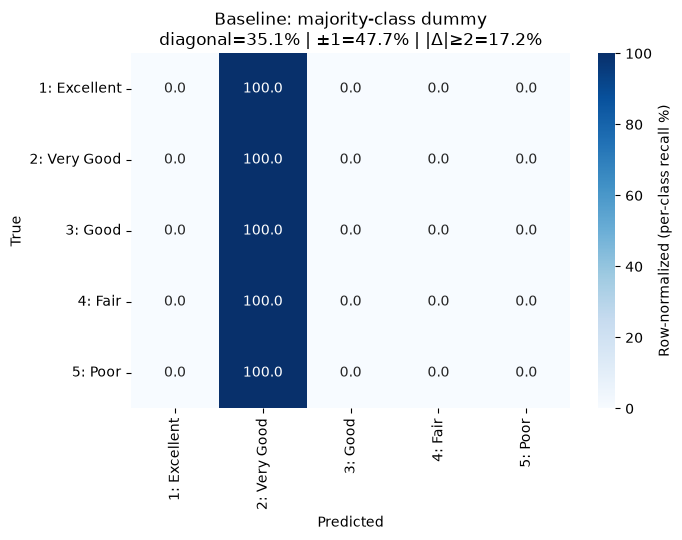

,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,Baseline: majority-class dummy,0.3512,0.104,0.2,0.3512,0.4767,0.8278,0.1722,0.0009,0.0004,Sanity check; must beat this on Macro-F1 and b...


In [40]:
dummy_pipe = make_model_pipeline(
    DummyClassifier(strategy='most_frequent', random_state=MODEL_SEED),
    needs_scaling=False,
)
dummy_record, dummy_diag, _ = evaluate_model(
    dummy_pipe, X_train, y_train, X_test, y_test,
    name='Baseline: majority-class dummy',
    notes='Sanity check; must beat this on Macro-F1 and balanced accuracy.',
)
results.append(dummy_record)

print('Harness metrics (single-shot on held-out test set):')
print(f'  accuracy         : {dummy_record["accuracy"]:.4f}')
print(f'  macro F1         : {dummy_record["macro_f1"]:.4f}')
print(f'  balanced accuracy: {dummy_record["balanced_accuracy"]:.4f}')
print(f'  fit / predict s  : {dummy_record["fit_seconds"]:.4f} / {dummy_record["predict_seconds"]:.4f}')
print()
print('H6 confusion mass split (dummy should sit at 100% diagonal *for the majority row only*):')
print(f'  diagonal mass    : {dummy_record["diagonal_mass"] * 100:.2f}%')
print(f'  adjacent (±1)    : {dummy_record["adjacent_mass"] * 100:.2f}%')
print(f'  far (|Δ|≥2)      : {dummy_record["far_mass"] * 100:.2f}%')

display(dummy_diag['per_class'].round(4))

plot_confusion_matrix(dummy_diag, title='Baseline: majority-class dummy')
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).round(4))


dt

In [48]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_basic = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='entropy')
dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)
y_pred_train_basic = dt_basic.predict(X_train)

print(f'Depth : {dt_basic.get_depth()}')
print(f'Leaves: {dt_basic.get_n_leaves()}')
print(f'Train accuracy : {accuracy_score(y_train, y_pred_train_basic):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_basic):.4f}')
print(f'Test macro F1 : {f1_score(y_test, y_pred_basic, average="macro", zero_division=0):.4f}')

Depth : 34
Leaves: 6968
Train accuracy : 0.9856
Test accuracy : 0.3808
Test macro F1 : 0.3625


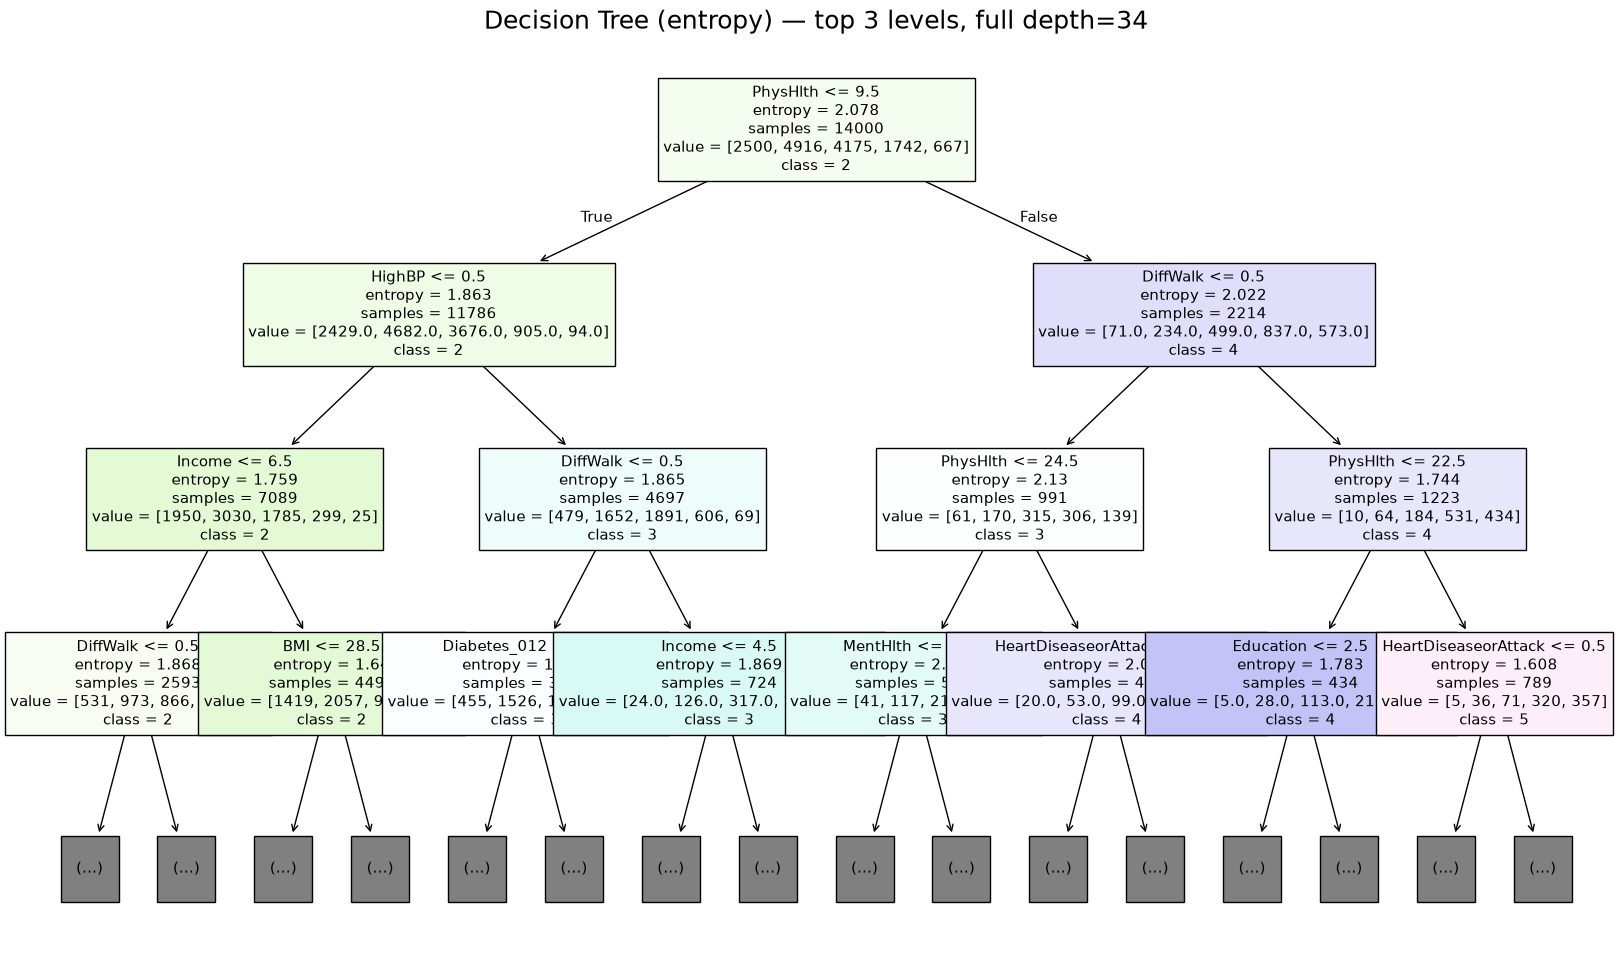

In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(
    dt_basic,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_basic.classes_],
    filled=True,
    fontsize=11,
    max_depth=3,
)
plt.title(f'Decision Tree (entropy) — top 3 levels, full depth={dt_basic.get_depth()}', fontsize=18)
plt.show()

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_basic = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='gini')
dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)
y_pred_train_basic = dt_basic.predict(X_train)

print(f'Depth : {dt_basic.get_depth()}')
print(f'Leaves: {dt_basic.get_n_leaves()}')
print(f'Train accuracy : {accuracy_score(y_train, y_pred_train_basic):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_basic):.4f}')
print(f'Test macro F1 : {f1_score(y_test, y_pred_basic, average="macro", zero_division=0):.4f}')

Depth : 33
Leaves: 6872
Train accuracy : 0.9856
Test accuracy : 0.3707
Test macro F1 : 0.3518


In [43]:
from sklearn.tree import DecisionTreeClassifier

dt_basic = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='log_loss')
dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)
y_pred_train_basic = dt_basic.predict(X_train)

print(f'Depth : {dt_basic.get_depth()}')
print(f'Leaves: {dt_basic.get_n_leaves()}')
print(f'Train accuracy : {accuracy_score(y_train, y_pred_train_basic):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_basic):.4f}')
print(f'Test macro F1 : {f1_score(y_test, y_pred_basic, average="macro", zero_division=0):.4f}')

Depth : 34
Leaves: 6968
Train accuracy : 0.9856
Test accuracy : 0.3808
Test macro F1 : 0.3625


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [4, 6, 8, 10, 12, 14, 16, 18, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'class_weight': [None, 'balanced'],
}

dt_grid_search_no_refit = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=MODEL_SEED),
    param_grid=dt_param_grid,
    scoring='f1_macro',
    cv=inner_splitter,
    n_jobs=-1,
    refit=False,
    return_train_score=True,
    error_score='raise',
)

dt_grid_search_no_refit.fit(X_train, y_train)

print(f'Best params: {dt_grid_search_no_refit.best_params_}')
print(f'Best CV Macro-F1: {dt_grid_search_no_refit.best_score_:.4f}')

Best params: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV Macro-F1: 0.4193


In [45]:
dt_best_from_grid = DecisionTreeClassifier(
    random_state=MODEL_SEED,
    **dt_grid_search_no_refit.best_params_,
)
dt_best_from_grid.fit(X_train, y_train)

y_pred_best = dt_best_from_grid.predict(X_test)
y_pred_train_best = dt_best_from_grid.predict(X_train)

print(f'Params used   : {dt_grid_search_no_refit.best_params_}')
print(f'Depth : {dt_best_from_grid.get_depth()}')
print(f'Leaves: {dt_best_from_grid.get_n_leaves()}')
print(f'Train accuracy : {accuracy_score(y_train, y_pred_train_best):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Test macro F1 : {f1_score(y_test, y_pred_best, average="macro", zero_division=0):.4f}')

Params used   : {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 15, 'min_samples_split': 2}
Depth : 10
Leaves: 313
Train accuracy : 0.5182
Test accuracy : 0.4492
Test macro F1 : 0.4101


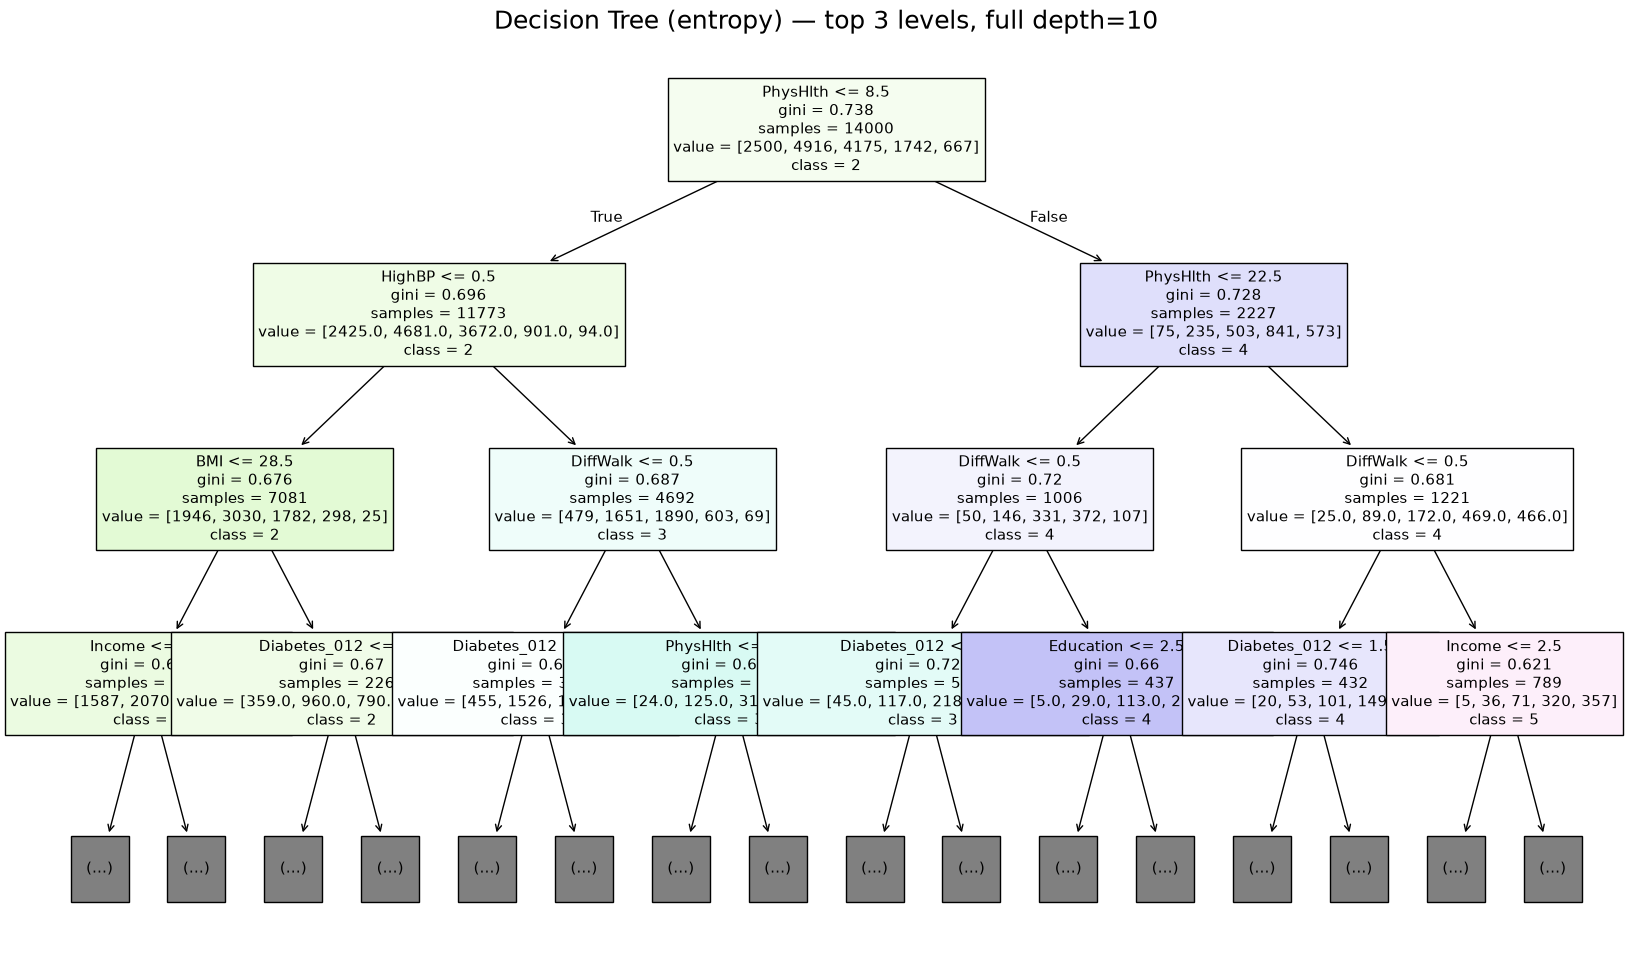

In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(
    dt_best_from_grid,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_best_from_grid.classes_],
    filled=True,
    fontsize=11,
    max_depth=3,  
)
plt.title(f'Decision Tree (entropy) — top 3 levels, full depth={dt_best_from_grid.get_depth()}', fontsize=18)
plt.show()

In [46]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_param_distributions = {
    'max_depth': randint(3, 30),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf': randint(1, 50),
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced'],
}

dt_random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=MODEL_SEED),
    param_distributions=dt_param_distributions,
    n_iter=100,
    scoring='f1_macro',
    cv=inner_splitter,
    n_jobs=-1,
    refit=True,
    random_state=MODEL_SEED,
    return_train_score=True,
    error_score='raise',
)

dt_random_search.fit(X_train, y_train)

print(f'Best params: {dt_random_search.best_params_}')
print(f'Best CV Macro-F1: {dt_random_search.best_score_:.4f}')

dt_random_best_model = dt_random_search.best_estimator_
y_pred_random = dt_random_best_model.predict(X_test)
y_pred_train_random = dt_random_best_model.predict(X_train)

print(f'Depth : {dt_random_best_model.get_depth()}')
print(f'Leaves: {dt_random_best_model.get_n_leaves()}')
print(f'Train accuracy : {accuracy_score(y_train, y_pred_train_random):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_random):.4f}')
print(f'Test macro F1 : {f1_score(y_test, y_pred_random, average="macro", zero_division=0):.4f}')

Best params: {'class_weight': None, 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 44, 'min_samples_split': 45}
Best CV Macro-F1: 0.4261
Depth : 10
Leaves: 167
Train accuracy : 0.4949
Test accuracy : 0.4520
Test macro F1 : 0.4327


,ccp_alpha,n_leaves,depth,train_accuracy,test_accuracy,test_macro_f1
0,0.0000,6968,34,0.9856,0.3808,0.3625
1,0.0000,6968,34,0.9856,0.3808,0.3625
2,0.0000,6968,34,0.9856,0.3808,0.3625
3,0.0000,6968,34,0.9856,0.3808,0.3625
4,0.0000,6964,34,0.9856,0.3808,0.3625
...,...,...,...,...,...,...
3908,0.0142,6,3,0.4119,0.4072,0.2583
3909,0.0166,5,3,0.4113,0.4122,0.2726
3910,0.0179,4,3,0.4113,0.4122,0.2726
3911,0.0185,3,2,0.4113,0.4122,0.2726


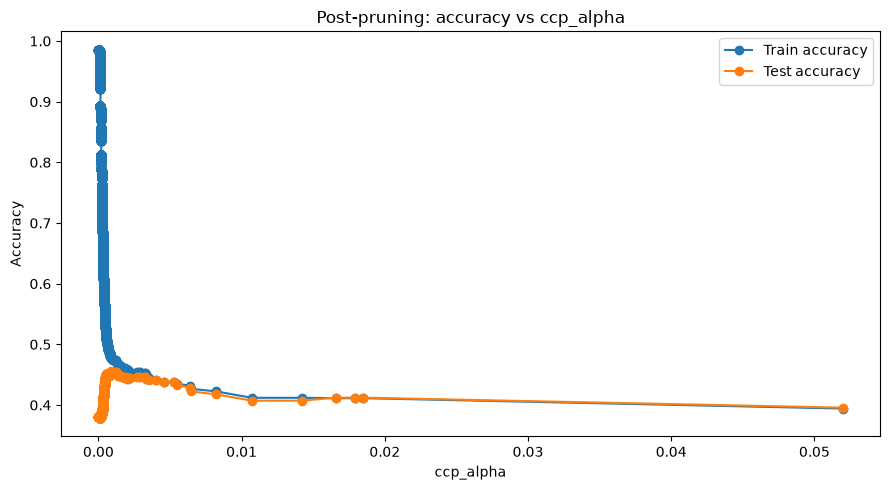

Selected ccp_alpha: 0.001353
Pruned tree — depth=10, leaves=40
Train accuracy : 0.4668
Test accuracy  : 0.4492
Test macro F1  : 0.4338


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='entropy').fit(X_train, y_train)
ccp_path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1] 

pruned_models = []
pruning_results = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=MODEL_SEED, ccp_alpha=alpha, criterion='entropy').fit(X_train, y_train)
    pruned_models.append(clf)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    test_f1 = f1_score(y_test, clf.predict(X_test), average='macro', zero_division=0)
    pruning_results.append({
        'ccp_alpha': alpha,
        'n_leaves': clf.get_n_leaves(),
        'depth': clf.get_depth(),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'test_macro_f1': test_f1,
    })

pruning_df = pd.DataFrame(pruning_results)
display(pruning_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pruning_df['ccp_alpha'], pruning_df['train_accuracy'], marker='o', label='Train accuracy')
ax.plot(pruning_df['ccp_alpha'], pruning_df['test_accuracy'], marker='o', label='Test accuracy')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-pruning: accuracy vs ccp_alpha')
ax.legend()
plt.tight_layout()
plt.show()

best_index = int(pruning_df['test_macro_f1'].idxmax())
best_row = pruning_df.loc[best_index]
best_ccp_alpha = best_row['ccp_alpha']
dt_pruned = pruned_models[best_index]

print(f'Selected ccp_alpha: {best_ccp_alpha:.6f}')
print(f'Pruned tree — depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()}')
print(f'Train accuracy : {best_row["train_accuracy"]:.4f}')
print(f'Test accuracy  : {best_row["test_accuracy"]:.4f}')
print(f'Test macro F1  : {best_row["test_macro_f1"]:.4f}')

,ccp_alpha,n_leaves,depth,train_accuracy,test_accuracy,test_macro_f1
0,0.0000,6872,33,0.9856,0.3707,0.3518
1,0.0000,6872,33,0.9856,0.3707,0.3518
2,0.0000,6872,33,0.9856,0.3707,0.3518
3,0.0000,6872,33,0.9856,0.3707,0.3518
4,0.0000,6872,33,0.9856,0.3707,0.3518
...,...,...,...,...,...,...
3196,0.0035,6,3,0.4115,0.4123,0.2729
3197,0.0042,5,3,0.4115,0.4123,0.2729
3198,0.0046,4,3,0.4115,0.4123,0.2729
3199,0.0056,3,2,0.4115,0.4123,0.2729


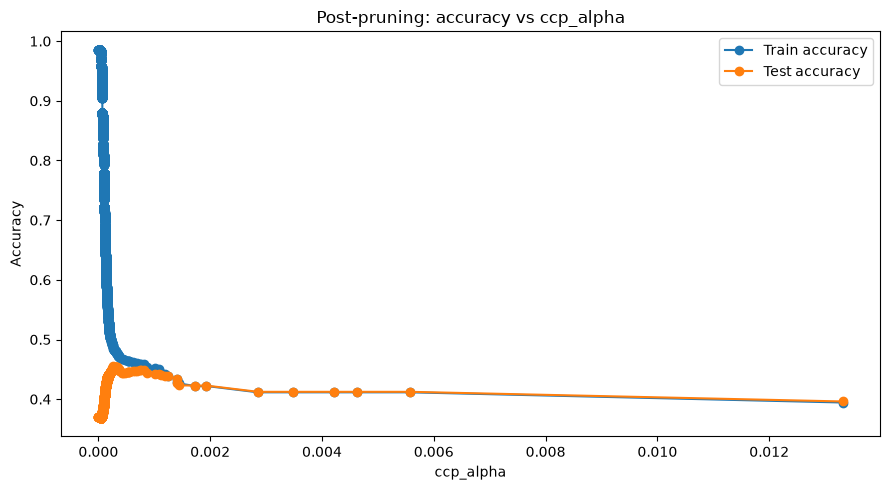

Selected ccp_alpha: 0.000254
Pruned tree — depth=13, leaves=82
Train accuracy : 0.4901
Test accuracy  : 0.4507
Test macro F1  : 0.4273


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='gini').fit(X_train, y_train)
ccp_path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1] 

pruned_models = []
pruning_results = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=MODEL_SEED, ccp_alpha=alpha, criterion='gini').fit(X_train, y_train)
    pruned_models.append(clf)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    test_f1 = f1_score(y_test, clf.predict(X_test), average='macro', zero_division=0)
    pruning_results.append({
        'ccp_alpha': alpha,
        'n_leaves': clf.get_n_leaves(),
        'depth': clf.get_depth(),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'test_macro_f1': test_f1,
    })

pruning_df = pd.DataFrame(pruning_results)
display(pruning_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pruning_df['ccp_alpha'], pruning_df['train_accuracy'], marker='o', label='Train accuracy')
ax.plot(pruning_df['ccp_alpha'], pruning_df['test_accuracy'], marker='o', label='Test accuracy')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-pruning: accuracy vs ccp_alpha')
ax.legend()
plt.tight_layout()
plt.show()

best_index = int(pruning_df['test_macro_f1'].idxmax())
best_row = pruning_df.loc[best_index]
best_ccp_alpha = best_row['ccp_alpha']
dt_pruned = pruned_models[best_index]

print(f'Selected ccp_alpha: {best_ccp_alpha:.6f}')
print(f'Pruned tree — depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()}')
print(f'Train accuracy : {best_row["train_accuracy"]:.4f}')
print(f'Test accuracy  : {best_row["test_accuracy"]:.4f}')
print(f'Test macro F1  : {best_row["test_macro_f1"]:.4f}')

,ccp_alpha,n_leaves,depth,train_accuracy,test_accuracy,test_macro_f1
0,0.0000,6968,34,0.9856,0.3808,0.3625
1,0.0000,6968,34,0.9856,0.3808,0.3625
2,0.0000,6968,34,0.9856,0.3808,0.3625
3,0.0000,6968,34,0.9856,0.3808,0.3625
4,0.0000,6964,34,0.9856,0.3808,0.3625
...,...,...,...,...,...,...
3908,0.0142,6,3,0.4119,0.4072,0.2583
3909,0.0166,5,3,0.4113,0.4122,0.2726
3910,0.0179,4,3,0.4113,0.4122,0.2726
3911,0.0185,3,2,0.4113,0.4122,0.2726


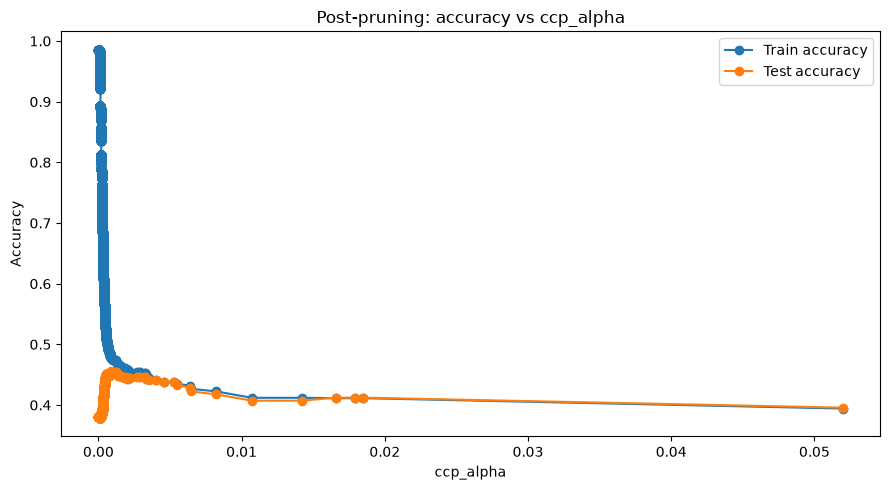

Selected ccp_alpha: 0.001353
Pruned tree — depth=10, leaves=40
Train accuracy : 0.4668
Test accuracy  : 0.4492
Test macro F1  : 0.4338


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(random_state=MODEL_SEED, criterion='log_loss').fit(X_train, y_train)
ccp_path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1] 

pruned_models = []
pruning_results = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=MODEL_SEED, ccp_alpha=alpha, criterion='log_loss').fit(X_train, y_train)
    pruned_models.append(clf)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    test_f1 = f1_score(y_test, clf.predict(X_test), average='macro', zero_division=0)
    pruning_results.append({
        'ccp_alpha': alpha,
        'n_leaves': clf.get_n_leaves(),
        'depth': clf.get_depth(),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'test_macro_f1': test_f1,
    })

pruning_df = pd.DataFrame(pruning_results)
display(pruning_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pruning_df['ccp_alpha'], pruning_df['train_accuracy'], marker='o', label='Train accuracy')
ax.plot(pruning_df['ccp_alpha'], pruning_df['test_accuracy'], marker='o', label='Test accuracy')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-pruning: accuracy vs ccp_alpha')
ax.legend()
plt.tight_layout()
plt.show()

best_index = int(pruning_df['test_macro_f1'].idxmax())
best_row = pruning_df.loc[best_index]
best_ccp_alpha = best_row['ccp_alpha']
dt_pruned = pruned_models[best_index]

print(f'Selected ccp_alpha: {best_ccp_alpha:.6f}')
print(f'Pruned tree — depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()}')
print(f'Train accuracy : {best_row["train_accuracy"]:.4f}')
print(f'Test accuracy  : {best_row["test_accuracy"]:.4f}')
print(f'Test macro F1  : {best_row["test_macro_f1"]:.4f}')

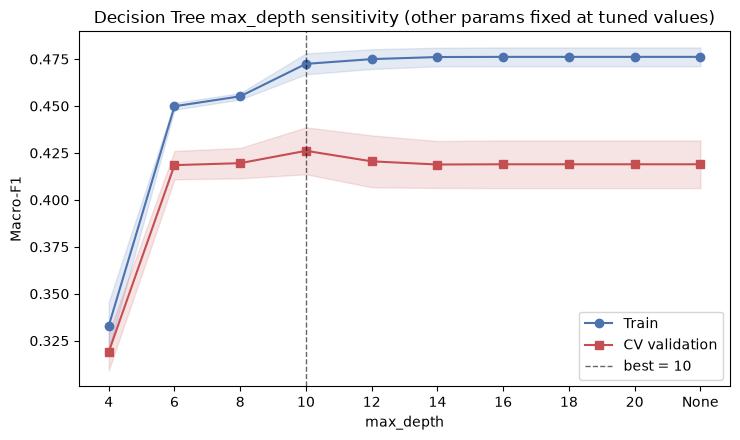

Tuned DT (from grid/random search): {'class_weight': None, 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 44, 'min_samples_split': 45}, CV Macro-F1=0.4261


In [116]:
_dt_grid_best_score = dt_grid_search_no_refit.best_score_
_dt_random_best_score = dt_random_search.best_score_

if _dt_random_best_score >= _dt_grid_best_score:
    dt_best_params = dt_random_search.best_params_
    depth_best_score = _dt_random_best_score
else:
    dt_best_params = dt_grid_search_no_refit.best_params_
    depth_best_score = _dt_grid_best_score

# visualize max_depth sensitivity at the already-tuned other hyperparameters, not a fresh search
_dt_depth_base_params = {k: v for k, v in dt_best_params.items() if k != 'max_depth'}
DT_MAX_DEPTH_VALUES = [4, 6, 8, 10, 12, 14, 16, 18, 20, None]

def _dt_depth_pipeline(max_depth):
    return DecisionTreeClassifier(max_depth=max_depth, random_state=MODEL_SEED, **_dt_depth_base_params)

depth_curve = cv_complexity_curve(_dt_depth_pipeline, X_train, y_train, DT_MAX_DEPTH_VALUES)

plot_complexity_curve(depth_curve, param_label='max_depth', title='Decision Tree max_depth sensitivity (other params fixed at tuned values)')
plt.tight_layout()
plt.show()

print(f'Tuned DT (from grid/random search): {dt_best_params}, CV Macro-F1={depth_best_score:.4f}')

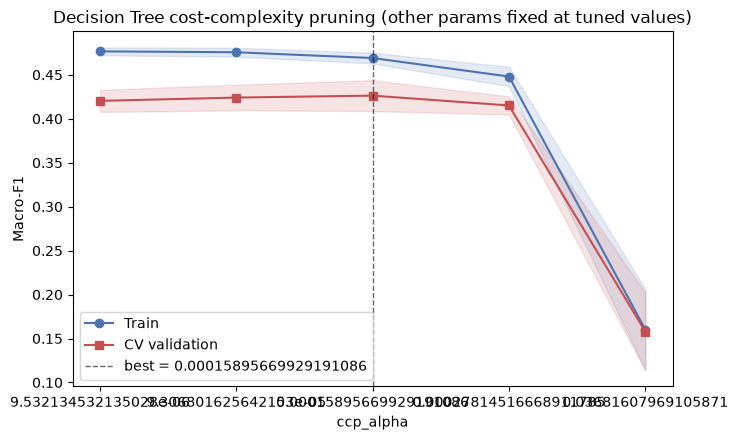

Best ccp_alpha: 0.000159, CV Macro-F1=0.4263


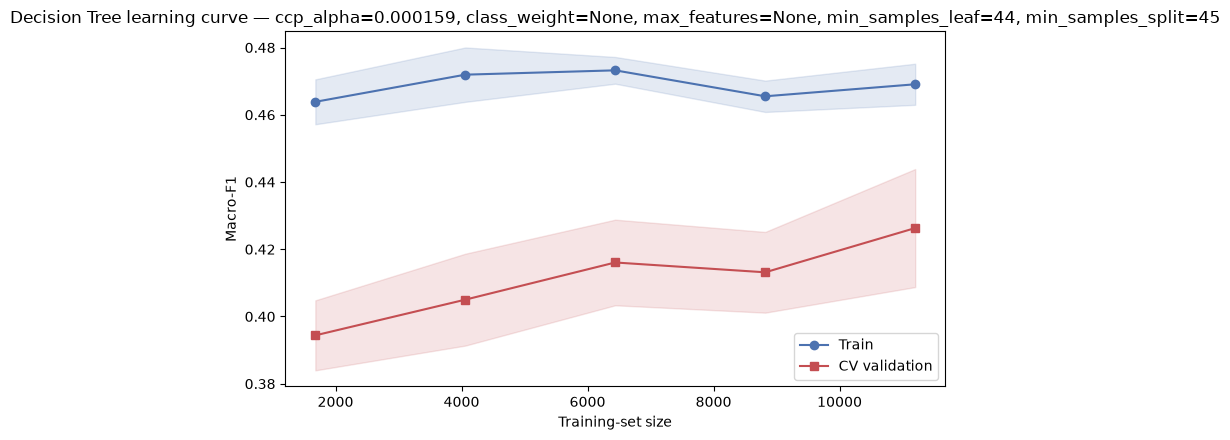

Decision Tree winner: ccp_alpha=0.000159, class_weight=None, max_features=None, min_samples_leaf=44, min_samples_split=45
Test accuracy : 0.4502
Test Macro-F1 : 0.4265


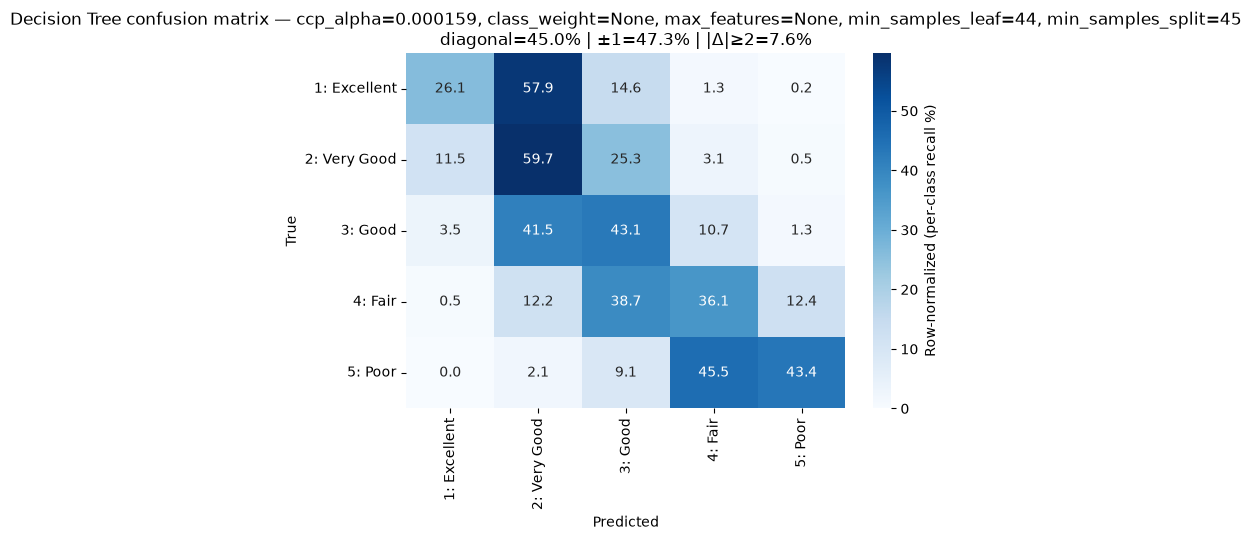

,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,Baseline: majority-class dummy,0.3512,0.1040,0.2000,0.3512,0.4767,0.8278,0.1722,0.0009,0.0004,Sanity check; must beat this on Macro-F1 and b...
1,"kNN (k=26, distance, euclidean)",0.4492,0.4148,0.3911,0.4492,0.4628,0.9120,0.0880,0.0596,0.1392,"k=26, distance, euclidean; scaled"
2,"SVM linear SVC (C=10, class_weight=balanced)",0.4050,0.4114,0.4899,0.4050,0.4487,0.8537,0.1463,211.2432,2.0861,"linear kernel; C=10, class_weight=balanced; sc..."
3,"SVM RBF SVC (C=100, gamma=0.01, class_weight=N...",0.4605,0.4114,0.3972,0.4605,0.4628,0.9233,0.0767,102.6385,7.7193,"RBF kernel; C=100, gamma=0.01, class_weight=No..."
4,"SVM LinearSVC reference (C=1, class_weight=None)",0.4510,0.3238,0.3401,0.4510,0.4950,0.9460,0.0540,0.1153,0.0042,"linear solver reference; C=1, class_weight=Non..."
5,"PyTorch MLP ((64, 32), ReLU)",0.4757,0.4448,0.4278,0.4757,0.4582,0.9338,0.0662,18.2825,0.0073,activation=ReLU; weight_decay=1e-05; plain SGD
6,Decision Tree (max_depth=6),0.4378,0.4188,0.4078,0.4378,0.4847,0.9225,0.0775,0.0209,0.0023,winner chosen by higher CV Macro-F1 between ma...
7,"Decision Tree (ccp_alpha=0.000159, class_weigh...",0.4502,0.4265,0.4166,0.4502,0.4733,0.9235,0.0765,0.0287,0.0016,winner = better of tuned GridSearchCV/Randomiz...


In [117]:
# ccp_alpha was never part of the grid/random search grids, so this is genuinely new tuning
_dt_alpha_base_params = {k: v for k, v in dt_best_params.items() if k != 'max_depth'}
_alpha_path = DecisionTreeClassifier(random_state=MODEL_SEED, **_dt_alpha_base_params).fit(X_train, y_train).cost_complexity_pruning_path(X_train, y_train).ccp_alphas
_alpha_path = np.unique(_alpha_path[_alpha_path > 0])
_idx = np.unique(np.linspace(0, len(_alpha_path) - 1, 5).astype(int))
DT_CCP_ALPHA_VALUES = _alpha_path[_idx].tolist()

def _dt_alpha_pipeline(ccp_alpha):
    return DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=MODEL_SEED, **_dt_alpha_base_params)

alpha_curve = cv_complexity_curve(_dt_alpha_pipeline, X_train, y_train, DT_CCP_ALPHA_VALUES)

plot_complexity_curve(alpha_curve, param_label='ccp_alpha', title='Decision Tree cost-complexity pruning (other params fixed at tuned values)')
plt.tight_layout()
plt.show()

alpha_best_score = alpha_curve['best_val_score']
print(f'Best ccp_alpha: {alpha_curve["best_value"]:.6f}, CV Macro-F1={alpha_best_score:.4f}')

if alpha_best_score > depth_best_score:
    winner_label = f'ccp_alpha={alpha_curve["best_value"]:.6f}, ' + ', '.join(f'{k}={v}' for k, v in _dt_alpha_base_params.items())
    dt_winner_factory = lambda: DecisionTreeClassifier(ccp_alpha=alpha_curve['best_value'], random_state=MODEL_SEED, **_dt_alpha_base_params)
else:
    winner_label = ', '.join(f'{k}={v}' for k, v in dt_best_params.items())
    dt_winner_factory = lambda: DecisionTreeClassifier(random_state=MODEL_SEED, **dt_best_params)

dt_learning = cv_learning_curve(dt_winner_factory, X_train, y_train, train_sizes=np.linspace(0.15, 1.0, 5))
plot_learning_curve(dt_learning, title=f'Decision Tree learning curve — {winner_label}')
plt.tight_layout()
plt.show()

dt_record, dt_diag, dt_y_pred = evaluate_model(
    dt_winner_factory(), X_train, y_train, X_test, y_test,
    name=f'Decision Tree ({winner_label})',
    notes=f'winner = better of tuned GridSearchCV/RandomizedSearchCV vs ccp_alpha pruning; {winner_label}',
)
results.append(dt_record)

print(f'Decision Tree winner: {winner_label}')
print(f'Test accuracy : {dt_record["accuracy"]:.4f}')
print(f'Test Macro-F1 : {dt_record["macro_f1"]:.4f}')

plot_confusion_matrix(dt_diag, title=f'Decision Tree confusion matrix — {winner_label}')
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).round(4))

knn

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=1 baseline (Euclidean, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=1 baseline (Euclidean, uniform, scaled):
  train accuracy : 0.9848
  test accuracy  : 0.3775
  test macro F1  : 0.3598
  train-test gap : 0.6073


In [73]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=1, metric='manhattan', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=1 baseline (Manhattan, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=1 baseline (Manhattan, uniform, scaled):
  train accuracy : 0.9848
  test accuracy  : 0.3720
  test macro F1  : 0.3576
  train-test gap : 0.6128


In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=5 baseline (Euclidean, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=5 baseline (Euclidean, uniform, scaled):
  train accuracy : 0.5785
  test accuracy  : 0.4015
  test macro F1  : 0.3783
  train-test gap : 0.1770


In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=5, metric='manhattan', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=5 baseline (Manhattan, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=5 baseline (Manhattan, uniform, scaled):
  train accuracy : 0.5718
  test accuracy  : 0.3878
  test macro F1  : 0.3613
  train-test gap : 0.1840


In [76]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=10, metric='euclidean', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=10 baseline (Euclidean, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=10 baseline (Euclidean, uniform, scaled):
  train accuracy : 0.5288
  test accuracy  : 0.4212
  test macro F1  : 0.3958
  train-test gap : 0.1076


In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=10, metric='manhattan', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=10 baseline (Manhattan, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=10 baseline (Manhattan, uniform, scaled):
  train accuracy : 0.5273
  test accuracy  : 0.4200
  test macro F1  : 0.3908
  train-test gap : 0.1073


In [79]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=15 baseline (Euclidean, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=15 baseline (Euclidean, uniform, scaled):
  train accuracy : 0.5016
  test accuracy  : 0.4380
  test macro F1  : 0.4078
  train-test gap : 0.0636


In [80]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline_pipe = make_model_pipeline(
    KNeighborsClassifier(n_neighbors=15, metric='manhattan', n_jobs=-1),
    needs_scaling=True,
)
knn_baseline_pipe.fit(X_train, y_train)

_yp_train = knn_baseline_pipe.predict(X_train)
_yp_test = knn_baseline_pipe.predict(X_test)
train_acc_knn = accuracy_score(y_train, _yp_train)
test_acc_knn = accuracy_score(y_test, _yp_test)
test_f1_knn = f1_score(y_test, _yp_test, average='macro', zero_division=0)

print('kNN k=15 baseline (Manhattan, uniform, scaled):')
print(f'  train accuracy : {train_acc_knn:.4f}')
print(f'  test accuracy  : {test_acc_knn:.4f}')
print(f'  test macro F1  : {test_f1_knn:.4f}')
print(f'  train-test gap : {train_acc_knn - test_acc_knn:.4f}')

kNN k=15 baseline (Manhattan, uniform, scaled):
  train accuracy : 0.5045
  test accuracy  : 0.4368
  test macro F1  : 0.4077
  train-test gap : 0.0677


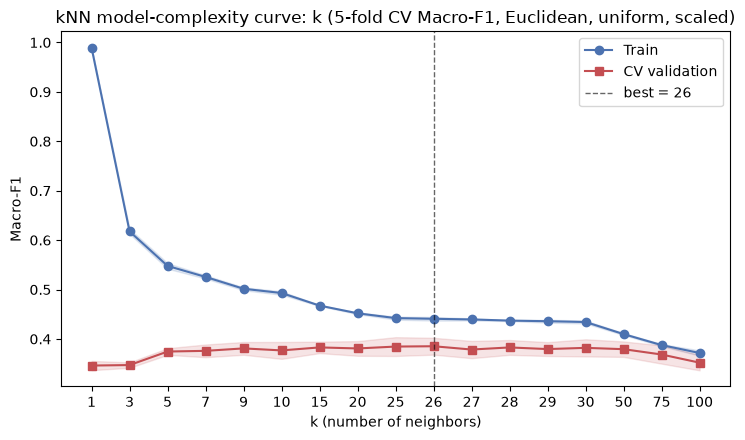

Best k CV Macro-F1: 0.3853 at k = 26


In [67]:
# K_VALUES = [3, 11, 31, 51, 101]
K_VALUES = [1, 3, 5, 7, 9, 10, 15, 20, 25, 26, 27, 28, 29, 30, 50, 75, 100]


def _knn_euclid_uniform_pipeline(k):
    return make_model_pipeline(
        KNeighborsClassifier(n_neighbors=k, weights='uniform',
                             metric='euclidean', n_jobs=-1),
        needs_scaling=True,
    )


knn_k_curve = cv_complexity_curve(
    _knn_euclid_uniform_pipeline, X_train, y_train, K_VALUES,
)

plot_complexity_curve(
    knn_k_curve,
    param_label='k (number of neighbors)',
    title='kNN model-complexity curve: k (5-fold CV Macro-F1, Euclidean, uniform, scaled)',
)
plt.tight_layout()
plt.show()

print(f'Best k CV Macro-F1: {knn_k_curve["best_val_score"]:.4f} '
      f'at k = {knn_k_curve["best_value"]}')


In [68]:
_best_k_euclid = knn_k_curve['best_value']
_weighting_rows = []
for weight_mode in ['uniform', 'distance']:
    pipe = make_model_pipeline(
        KNeighborsClassifier(n_neighbors=_best_k_euclid, weights=weight_mode,
                             metric='euclidean', n_jobs=-1),
        needs_scaling=True,
    )
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=inner_splitter, scoring=SCORING, n_jobs=-1,
    )
    _weighting_rows.append({
        'weighting': weight_mode,
        'cv_macro_f1_mean': float(scores['test_score'].mean()),
        'cv_macro_f1_std': float(scores['test_score'].std()),
    })

weighting_df = pd.DataFrame(_weighting_rows).round(4)
display(weighting_df)

_best_weighting_row = max(_weighting_rows, key=lambda r: r['cv_macro_f1_mean'])
best_weighting = _best_weighting_row['weighting']
_weighting_delta = (
    next(r['cv_macro_f1_mean'] for r in _weighting_rows if r['weighting'] == 'distance')
    - next(r['cv_macro_f1_mean'] for r in _weighting_rows if r['weighting'] == 'uniform')
)
print(f'At k = {_best_k_euclid}: best weighting = {best_weighting} '
      f'(Δ distance - uniform = {_weighting_delta:+.4f})')


,weighting,cv_macro_f1_mean,cv_macro_f1_std
0,uniform,0.3853,0.0171
1,distance,0.3911,0.0154


At k = 26: best weighting = distance (Δ distance - uniform = +0.0058)


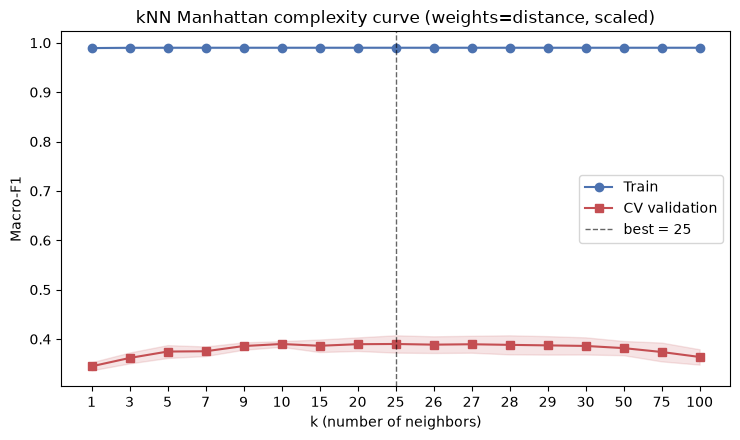

Euclidean (k=26, distance):  0.3911
Manhattan (k=25, distance): 0.3900
Δ (Manhattan - Euclidean) = -0.0011
Winner: euclidean, k = 26, weights = distance, CV Macro-F1 = 0.3911


In [69]:
def _knn_manhattan_pipeline(k):
    return make_model_pipeline(
        KNeighborsClassifier(n_neighbors=k, weights=best_weighting,
                             metric='manhattan', n_jobs=-1),
        needs_scaling=True,
    )


knn_manhattan_curve = cv_complexity_curve(
    _knn_manhattan_pipeline, X_train, y_train, K_VALUES,
)

plot_complexity_curve(
    knn_manhattan_curve,
    param_label='k (number of neighbors)',
    title=f'kNN Manhattan complexity curve (weights={best_weighting}, scaled)',
)
plt.tight_layout()
plt.show()

_euclid_best_at_weight = next(r['cv_macro_f1_mean'] for r in _weighting_rows if r['weighting'] == best_weighting)
_manhattan_best_at_weight = knn_manhattan_curve['best_val_score']
metric_delta = _manhattan_best_at_weight - _euclid_best_at_weight

if _manhattan_best_at_weight > _euclid_best_at_weight:
    best_metric = 'manhattan'
    final_k = knn_manhattan_curve['best_value']
    final_val_score = _manhattan_best_at_weight
else:
    best_metric = 'euclidean'
    final_k = _best_k_euclid
    final_val_score = _euclid_best_at_weight

print(f'Euclidean (k={_best_k_euclid}, {best_weighting}):  {_euclid_best_at_weight:.4f}')
print(f'Manhattan (k={knn_manhattan_curve["best_value"]}, {best_weighting}): {_manhattan_best_at_weight:.4f}')
print(f'Δ (Manhattan - Euclidean) = {metric_delta:+.4f}')
print(f'Winner: {best_metric}, k = {final_k}, weights = {best_weighting}, '
      f'CV Macro-F1 = {final_val_score:.4f}')


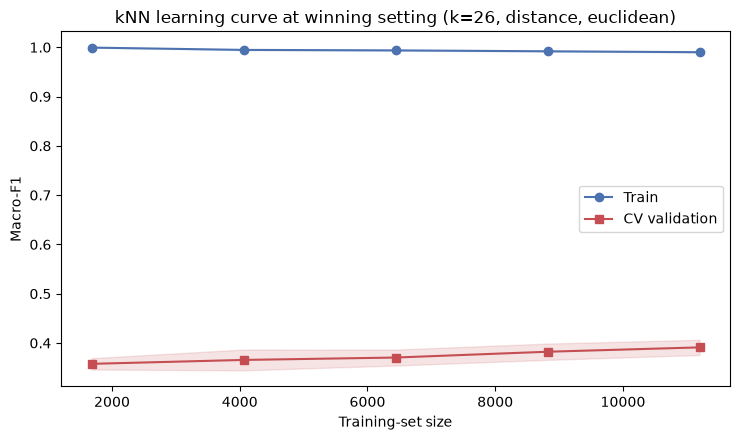

Sizes evaluated: [np.int64(1680), np.int64(4060), np.int64(6439), np.int64(8820), np.int64(11200)]
Val Macro-F1 at largest size: 0.3911 ± 0.0154


In [81]:
LEARNING_SIZES = np.linspace(0.15, 1.0, 5)
def _knn_winner_factory():
    return make_model_pipeline(
        KNeighborsClassifier(n_neighbors=final_k, weights=best_weighting,
                             metric=best_metric, n_jobs=-1),
        needs_scaling=True,
    )


knn_learning = cv_learning_curve(
    _knn_winner_factory, X_train, y_train, train_sizes=LEARNING_SIZES,
)

plot_learning_curve(
    knn_learning,
    title=f'kNN learning curve at winning setting (k={final_k}, {best_weighting}, {best_metric})',
)
plt.tight_layout()
plt.show()

print(f'Sizes evaluated: {list(knn_learning["sizes"])}')
print(f'Val Macro-F1 at largest size: '
      f'{knn_learning["val_mean"][-1]:.4f} ± {knn_learning["val_std"][-1]:.4f}')


kNN winner: k=26, distance, euclidean
Test accuracy         : 0.4492
Test Macro-F1         : 0.4148
Test balanced accuracy: 0.3911
Runtime               : fit = 0.060s, predict = 0.1392s
H6 mass split         : diag = 44.9% | ±1 = 46.3% | |Δ|≥2 = 8.8%


,class,precision,recall,f1,support
0,1: Excellent,0.4183,0.3109,0.3567,1071
1,2: Very Good,0.4513,0.6198,0.5223,2107
2,3: Good,0.4480,0.4164,0.4316,1789
3,4: Fair,0.4494,0.2972,0.3578,747
4,5: Poor,0.5817,0.3112,0.4055,286


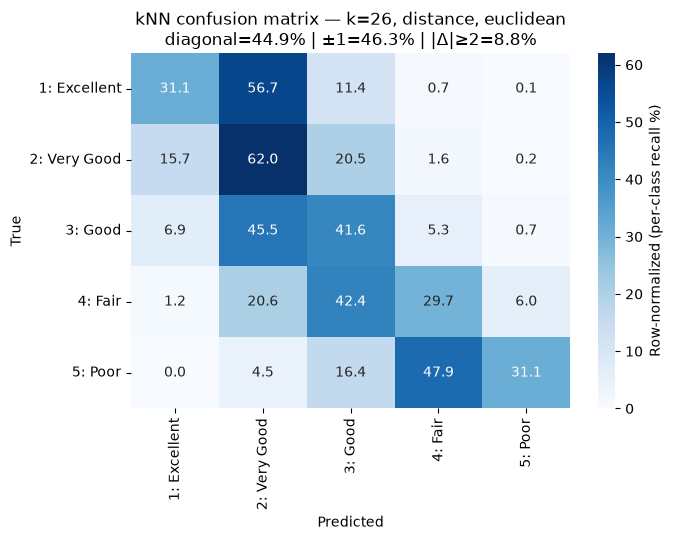

,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,Baseline: majority-class dummy,0.3512,0.1040,0.2000,0.3512,0.4767,0.8278,0.1722,0.0009,0.0004,Sanity check; must beat this on Macro-F1 and b...
1,"kNN (k=26, distance, euclidean)",0.4492,0.4148,0.3911,0.4492,0.4628,0.9120,0.0880,0.0596,0.1392,"k=26, distance, euclidean; scaled"


In [82]:
knn_final_pipe = _knn_winner_factory()
knn_label = f'k={final_k}, {best_weighting}, {best_metric}'
knn_record, knn_diag, knn_y_pred = evaluate_model(
    knn_final_pipe, X_train, y_train, X_test, y_test,
    name=f'kNN ({knn_label})',
    notes=f'{knn_label}; scaled',
)
results.append(knn_record)

print(f'kNN winner: {knn_label}')
print(f'Test accuracy         : {knn_record["accuracy"]:.4f}')
print(f'Test Macro-F1         : {knn_record["macro_f1"]:.4f}')
print(f'Test balanced accuracy: {knn_record["balanced_accuracy"]:.4f}')
print(f'Runtime               : fit = {knn_record["fit_seconds"]:.3f}s, '
      f'predict = {knn_record["predict_seconds"]:.4f}s')
print(f'H6 mass split         : diag = {knn_record["diagonal_mass"] * 100:.1f}% | '
      f'±1 = {knn_record["adjacent_mass"] * 100:.1f}% | '
      f'|Δ|≥2 = {knn_record["far_mass"] * 100:.1f}%')

display(knn_diag['per_class'].round(4))

plot_confusion_matrix(knn_diag, title=f'kNN confusion matrix — {knn_label}')
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).round(4))


svm

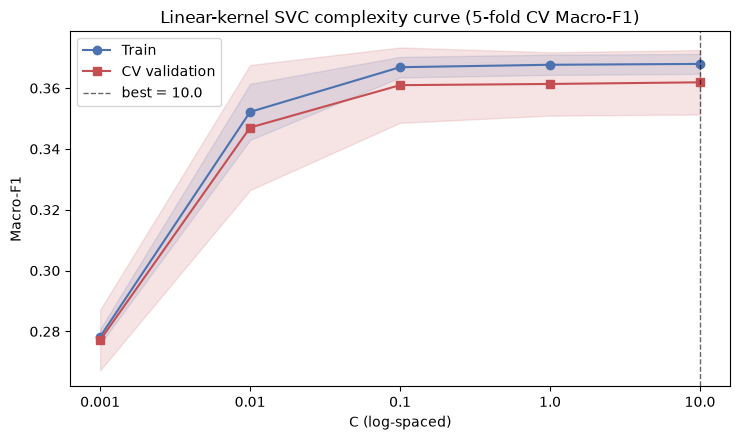

Best linear SVC: C=10.0, CV Macro-F1=0.3619


In [83]:
from sklearn.svm import LinearSVC, SVC

SVM_C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0]
SVM_CACHE_MB = 2048
SVM_N_JOBS = 20


def _linear_svc_pipeline(C, class_weight=None):
    return make_model_pipeline(
        SVC(
            kernel='linear',
            C=C,
            class_weight=class_weight,
            cache_size=SVM_CACHE_MB,
            probability=False,
            random_state=MODEL_SEED,
        ),
        needs_scaling=True,
    )


linear_svc_curve = cv_complexity_curve(
    lambda C: _linear_svc_pipeline(C, class_weight=None),
    X_train,
    y_train,
    SVM_C_VALUES,
    n_jobs=SVM_N_JOBS,
)

plot_complexity_curve(
    linear_svc_curve,
    param_label='C (log-spaced)',
    title='Linear-kernel SVC complexity curve (5-fold CV Macro-F1)',
)
plt.tight_layout()
plt.show()

linear_svc_best_C = linear_svc_curve['best_value']
print(f'Best linear SVC: C={linear_svc_best_C}, '
      f'CV Macro-F1={linear_svc_curve["best_val_score"]:.4f}')

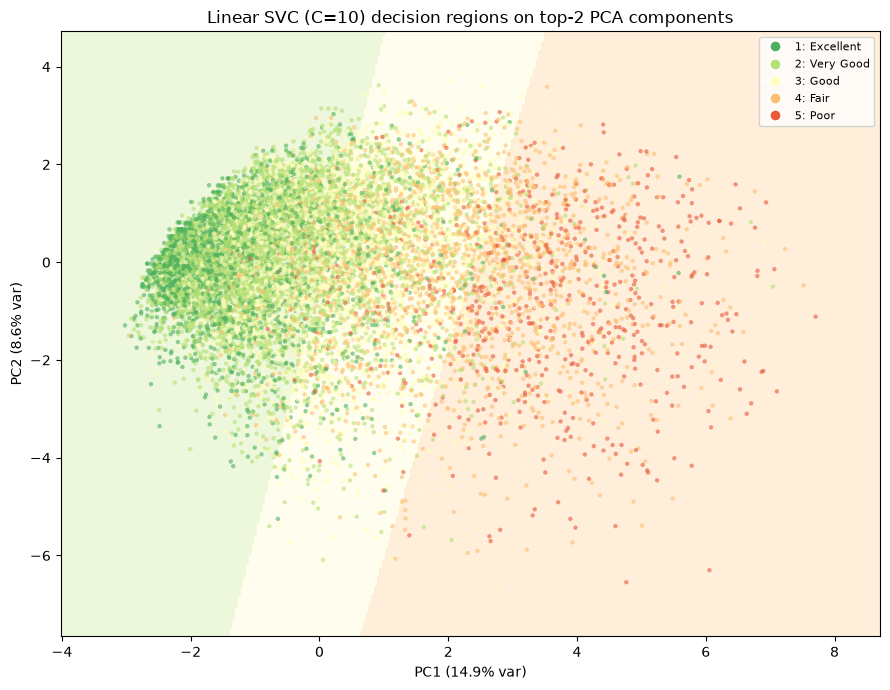

Top-2 PCs explain 23.4% of total variance — these boundaries approximate the real 21-D linear decision surface.


In [84]:
from sklearn.decomposition import PCA

# Visualization only: the tuned linear SVC fits in 21-D and can't be plotted directly,
# so a separate linear SVC is fit on the top-2 PCA components purely for display.
_linear_svc_scaler = _linear_svc_pipeline(linear_svc_best_C).named_steps['scaler'].fit(X_train)
X_train_scaled = _linear_svc_scaler.transform(X_train)
pca = PCA(n_components=2, random_state=MODEL_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)

svc_viz = SVC(kernel='linear', C=linear_svc_best_C, cache_size=SVM_CACHE_MB, random_state=MODEL_SEED)
svc_viz.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_predictions = svc_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

class_palette = sns.color_palette('RdYlGn_r', 5)
cmap = matplotlib.colors.ListedColormap(class_palette)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, grid_predictions, alpha=0.25, cmap=cmap, levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=cmap, s=10, alpha=0.6, edgecolor='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
ax.set_title(f'Linear SVC (C={linear_svc_best_C:g}) decision regions on top-2 PCA components')
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_palette[i],
               label=f'{c}: {class_names[c]}', markersize=8)
    for i, c in enumerate(CLASSES)
]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Top-2 PCs explain {pca.explained_variance_ratio_[:2].sum() * 100:.1f}% of total variance — '
      'these boundaries approximate the real 21-D linear decision surface.')

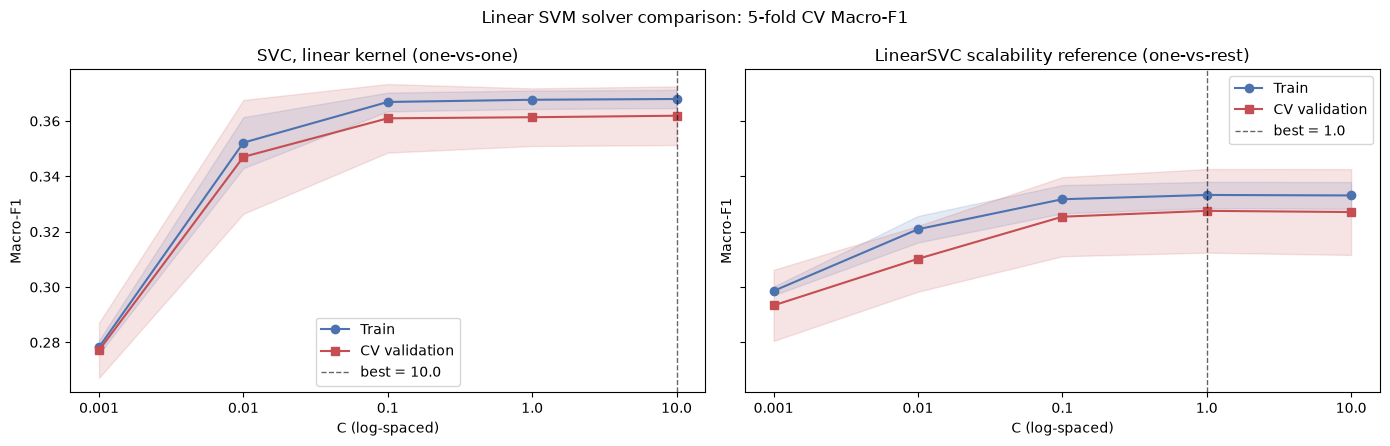

,estimator,multiclass_strategy,best_C,best_cv_macro_f1
0,SVC(kernel=linear),one-vs-one,10.0,0.3619
1,LinearSVC,one-vs-rest,1.0,0.3275


In [85]:
def _linear_svc_fast_pipeline(C):
    return make_model_pipeline(
        LinearSVC(
            C=C,
            class_weight=None,
            dual='auto',
            max_iter=20_000,
            random_state=MODEL_SEED,
        ),
        needs_scaling=True,
    )


linear_svc_fast_curve = cv_complexity_curve(
    _linear_svc_fast_pipeline,
    X_train,
    y_train,
    SVM_C_VALUES,
    n_jobs=SVM_N_JOBS,
)
linear_svc_fast_best_C = linear_svc_fast_curve['best_value']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
plot_complexity_curve(
    linear_svc_curve,
    param_label='C (log-spaced)',
    title='SVC, linear kernel (one-vs-one)',
    ax=axes[0],
)
plot_complexity_curve(
    linear_svc_fast_curve,
    param_label='C (log-spaced)',
    title='LinearSVC scalability reference (one-vs-rest)',
    ax=axes[1],
)
fig.suptitle('Linear SVM solver comparison: 5-fold CV Macro-F1')
plt.tight_layout()
plt.show()

linear_solver_comparison = pd.DataFrame([
    {
        'estimator': 'SVC(kernel=linear)',
        'multiclass_strategy': 'one-vs-one',
        'best_C': linear_svc_best_C,
        'best_cv_macro_f1': linear_svc_curve['best_val_score'],
    },
    {
        'estimator': 'LinearSVC',
        'multiclass_strategy': 'one-vs-rest',
        'best_C': linear_svc_fast_best_C,
        'best_cv_macro_f1': linear_svc_fast_curve['best_val_score'],
    },
])
display(linear_solver_comparison.round(4))


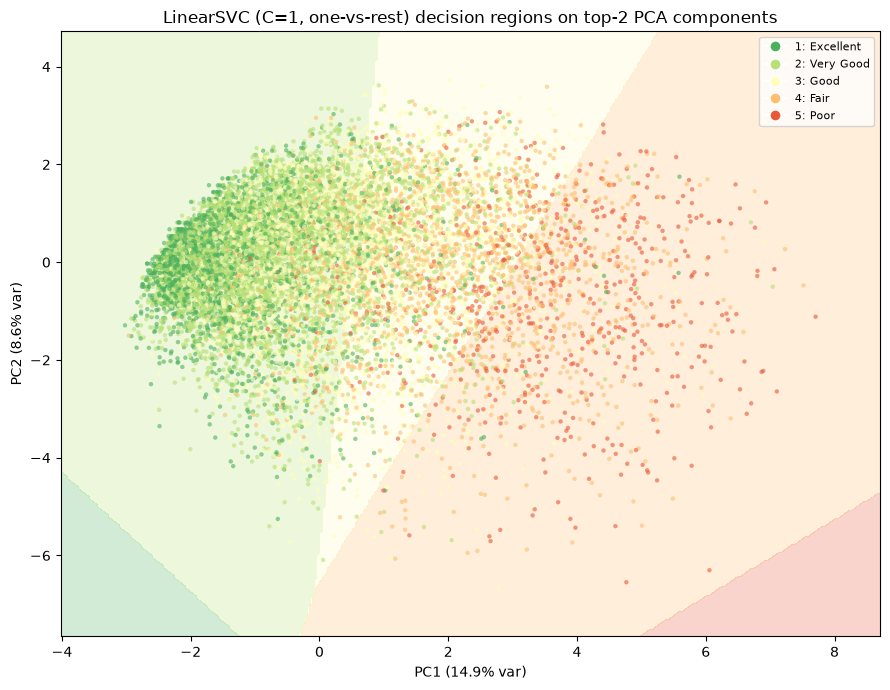

Top-2 PCs explain 23.4% of total variance — these boundaries approximate the real 21-D one-vs-rest linear decision surface.


In [86]:
# Visualization only: LinearSVC (one-vs-rest) fit on top-2 PCA components purely for display.
_linear_svc_fast_scaler = _linear_svc_fast_pipeline(linear_svc_fast_best_C).named_steps['scaler'].fit(X_train)
X_train_scaled_fast = _linear_svc_fast_scaler.transform(X_train)
pca_fast = PCA(n_components=2, random_state=MODEL_SEED)
X_train_pca_fast = pca_fast.fit_transform(X_train_scaled_fast)

svc_fast_viz = LinearSVC(C=linear_svc_fast_best_C, dual='auto', max_iter=20_000, random_state=MODEL_SEED)
svc_fast_viz.fit(X_train_pca_fast, y_train)

x_min, x_max = X_train_pca_fast[:, 0].min() - 1, X_train_pca_fast[:, 0].max() + 1
y_min, y_max = X_train_pca_fast[:, 1].min() - 1, X_train_pca_fast[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_predictions_fast = svc_fast_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

class_palette = sns.color_palette('RdYlGn_r', 5)
cmap = matplotlib.colors.ListedColormap(class_palette)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, grid_predictions_fast, alpha=0.25, cmap=cmap, levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
ax.scatter(X_train_pca_fast[:, 0], X_train_pca_fast[:, 1], c=y_train, cmap=cmap, s=10, alpha=0.6, edgecolor='none')
ax.set_xlabel(f'PC1 ({pca_fast.explained_variance_ratio_[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_fast.explained_variance_ratio_[1] * 100:.1f}% var)')
ax.set_title(f'LinearSVC (C={linear_svc_fast_best_C:g}, one-vs-rest) decision regions on top-2 PCA components')
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_palette[i],
               label=f'{c}: {class_names[c]}', markersize=8)
    for i, c in enumerate(CLASSES)
]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Top-2 PCs explain {pca_fast.explained_variance_ratio_[:2].sum() * 100:.1f}% of total variance — '
      'these boundaries approximate the real 21-D one-vs-rest linear decision surface.')

,C,gamma,mean_train_score,std_train_score,mean_validation_score,std_validation_score,mean_fit_time,mean_score_time
6,100.0,0.01,0.6014,0.0035,0.4064,0.0140,393.2654,4.9575
4,30.0,0.01,0.5371,0.0024,0.4059,0.0155,222.8903,20.6291
1,1.0,0.10,0.6346,0.0031,0.4033,0.0130,104.9722,18.6239
3,10.0,0.10,0.8216,0.0008,0.3842,0.0060,313.8149,6.1288
2,10.0,0.01,0.4606,0.0052,0.3790,0.0170,115.1739,18.4781
5,30.0,0.10,0.8636,0.0004,0.3761,0.0042,405.6493,6.8475
7,100.0,0.10,0.8956,0.0009,0.3729,0.0035,437.4530,5.7068
0,1.0,0.01,0.3801,0.0028,0.3574,0.0164,11.1475,4.0686


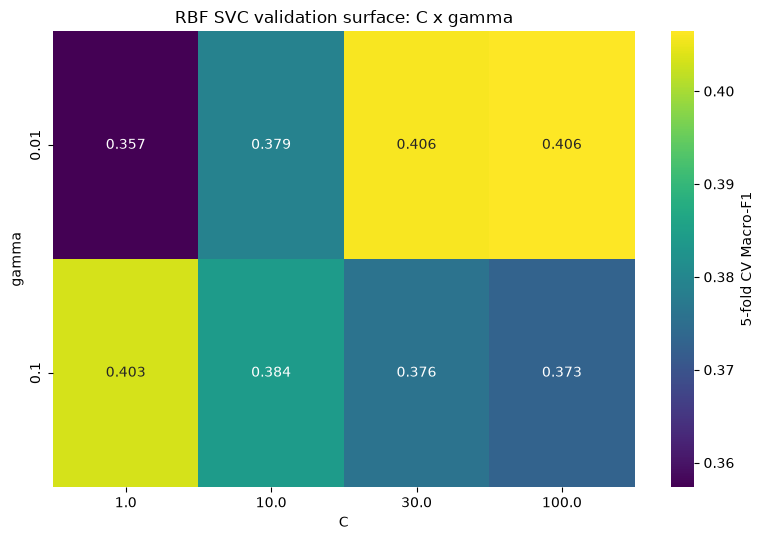

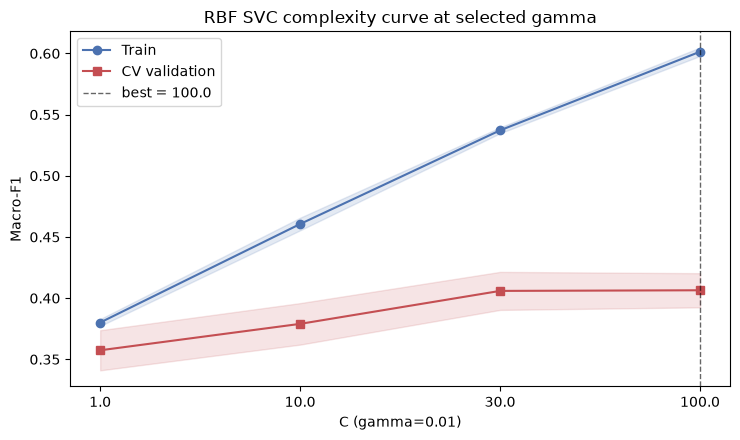

RBF grid runtime: 803.2s for 8 settings x 5 folds
Best RBF SVC: C=100, gamma=0.01, CV Macro-F1=0.4064
Boundary check: C boundary=True, gamma boundary=True


In [89]:

from sklearn.model_selection import GridSearchCV

SVM_RBF_C_VALUES = [1.0, 10.0, 30.0, 100.0]
SVM_GAMMA_VALUES = [0.01, 0.1]

def _rbf_svc_pipeline(C, gamma, class_weight=None):
    return make_model_pipeline(
        SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            class_weight=class_weight,
            cache_size=SVM_CACHE_MB,
            probability=False,
            random_state=MODEL_SEED,
        ),
        needs_scaling=True,
    )


rbf_search = GridSearchCV(
    estimator=_rbf_svc_pipeline(C=1.0, gamma='scale'),
    param_grid={
        'model__C': SVM_RBF_C_VALUES,
        'model__gamma': SVM_GAMMA_VALUES,
    },
    scoring=SCORING,
    cv=inner_splitter,
    n_jobs=SVM_N_JOBS,
    return_train_score=True,
    refit=False,
    error_score='raise',
)
_rbf_search_started = time.perf_counter()
rbf_search.fit(X_train, y_train)
rbf_grid_seconds = time.perf_counter() - _rbf_search_started

rbf_cv = pd.DataFrame(rbf_search.cv_results_)
rbf_best_index = int(rbf_cv['mean_test_score'].idxmax())
rbf_best_C = float(rbf_cv.loc[rbf_best_index, 'param_model__C'])
rbf_best_gamma = float(rbf_cv.loc[rbf_best_index, 'param_model__gamma'])
rbf_best_cv_macro_f1 = float(rbf_cv.loc[rbf_best_index, 'mean_test_score'])

rbf_grid_table = rbf_cv[[
    'param_model__C', 'param_model__gamma',
    'mean_train_score', 'std_train_score',
    'mean_test_score', 'std_test_score',
    'mean_fit_time', 'mean_score_time',
]].rename(columns={
    'param_model__C': 'C',
    'param_model__gamma': 'gamma',
    'mean_test_score': 'mean_validation_score',
    'std_test_score': 'std_validation_score',
})
display(rbf_grid_table.sort_values('mean_validation_score', ascending=False).round(4))

validation_pivot = rbf_grid_table.pivot(index='gamma', columns='C', values='mean_validation_score')
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    validation_pivot,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    cbar_kws={'label': '5-fold CV Macro-F1'},
    ax=ax,
)
ax.set_title('RBF SVC validation surface: C x gamma')
ax.set_xlabel('C')
ax.set_ylabel('gamma')
plt.tight_layout()
plt.show()

rbf_slice = rbf_grid_table[rbf_grid_table['gamma'] == rbf_best_gamma].sort_values('C')
rbf_C_curve = {
    'param_values': rbf_slice['C'].tolist(),
    'train_mean': rbf_slice['mean_train_score'].to_numpy(),
    'train_std': rbf_slice['std_train_score'].to_numpy(),
    'val_mean': rbf_slice['mean_validation_score'].to_numpy(),
    'val_std': rbf_slice['std_validation_score'].to_numpy(),
    'best_index': int(np.argmax(rbf_slice['mean_validation_score'].to_numpy())),
    'best_value': rbf_best_C,
    'best_val_score': rbf_best_cv_macro_f1,
}
plot_complexity_curve(
    rbf_C_curve,
    param_label=f'C (gamma={rbf_best_gamma:g})',
    title='RBF SVC complexity curve at selected gamma',
)
plt.tight_layout()
plt.show()

print(f'RBF grid runtime: {rbf_grid_seconds:.1f}s for {len(rbf_cv)} settings x {CV_FOLDS} folds')
print(f'Best RBF SVC: C={rbf_best_C:g}, gamma={rbf_best_gamma:g}, '
      f'CV Macro-F1={rbf_best_cv_macro_f1:.4f}')
print(f'Boundary check: C boundary={rbf_best_C in (min(SVM_RBF_C_VALUES), max(SVM_RBF_C_VALUES))}, '
      f'gamma boundary={rbf_best_gamma in (min(SVM_GAMMA_VALUES), max(SVM_GAMMA_VALUES))}')

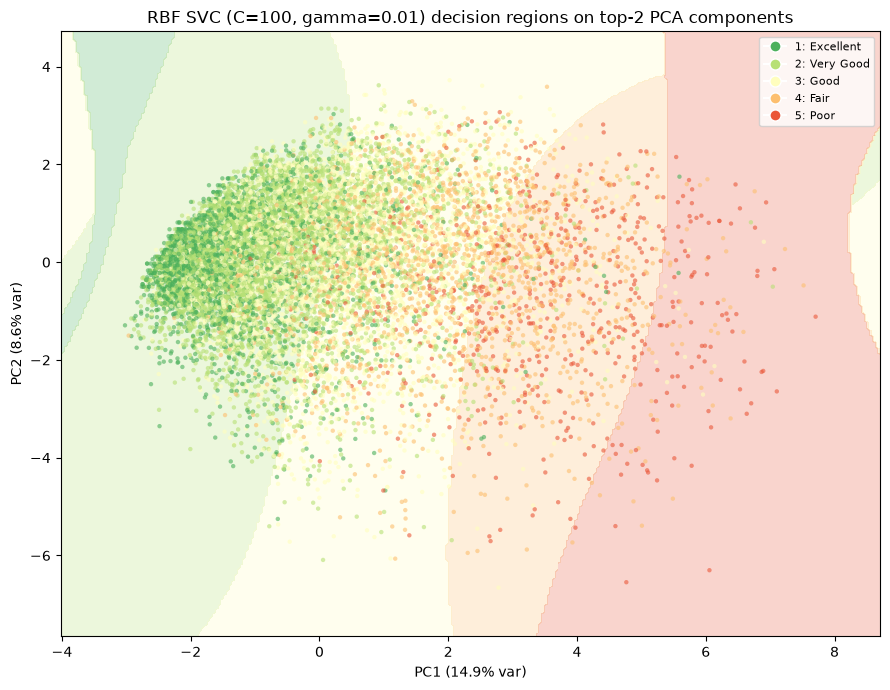

Top-2 PCs explain 23.4% of total variance — the curved RBF boundary above is only an approximation in 2-D; the real decision surface lives in 21-D.


In [90]:
# Visualization only: RBF SVC fit on top-2 PCA components purely for display.
_rbf_svc_scaler = _rbf_svc_pipeline(rbf_best_C, rbf_best_gamma).named_steps['scaler'].fit(X_train)
X_train_scaled_rbf = _rbf_svc_scaler.transform(X_train)
pca_rbf = PCA(n_components=2, random_state=MODEL_SEED)
X_train_pca_rbf = pca_rbf.fit_transform(X_train_scaled_rbf)

svc_rbf_viz = SVC(
    kernel='rbf', C=rbf_best_C, gamma=rbf_best_gamma,
    cache_size=SVM_CACHE_MB, random_state=MODEL_SEED,
)
svc_rbf_viz.fit(X_train_pca_rbf, y_train)

x_min, x_max = X_train_pca_rbf[:, 0].min() - 1, X_train_pca_rbf[:, 0].max() + 1
y_min, y_max = X_train_pca_rbf[:, 1].min() - 1, X_train_pca_rbf[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_predictions_rbf = svc_rbf_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

class_palette = sns.color_palette('RdYlGn_r', 5)
cmap = matplotlib.colors.ListedColormap(class_palette)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, grid_predictions_rbf, alpha=0.25, cmap=cmap, levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
ax.scatter(X_train_pca_rbf[:, 0], X_train_pca_rbf[:, 1], c=y_train, cmap=cmap, s=10, alpha=0.6, edgecolor='none')
ax.set_xlabel(f'PC1 ({pca_rbf.explained_variance_ratio_[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_rbf.explained_variance_ratio_[1] * 100:.1f}% var)')
ax.set_title(f'RBF SVC (C={rbf_best_C:g}, gamma={rbf_best_gamma:g}) decision regions on top-2 PCA components')
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_palette[i],
               label=f'{c}: {class_names[c]}', markersize=8)
    for i, c in enumerate(CLASSES)
]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Top-2 PCs explain {pca_rbf.explained_variance_ratio_[:2].sum() * 100:.1f}% of total variance — '
      'the curved RBF boundary above is only an approximation in 2-D; the real decision surface lives in 21-D.')

In [91]:
SVM_WEIGHT_MIN_GAIN = 0.005


def _weight_cv_row(kernel, class_weight):
    if kernel == 'linear':
        estimator = _linear_svc_pipeline(linear_svc_best_C, class_weight=class_weight)
    elif kernel == 'rbf':
        estimator = _rbf_svc_pipeline(rbf_best_C, rbf_best_gamma, class_weight=class_weight)
    else:
        raise ValueError(f'Unsupported kernel: {kernel}')

    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=inner_splitter,
        scoring=SCORING,
        n_jobs=SVM_N_JOBS,
        return_train_score=True,
        error_score='raise',
    )
    return {
        'kernel': kernel,
        'class_weight': 'None' if class_weight is None else class_weight,
        'train_macro_f1_mean': float(scores['train_score'].mean()),
        'cv_macro_f1_mean': float(scores['test_score'].mean()),
        'cv_macro_f1_std': float(scores['test_score'].std()),
        'fit_seconds_mean': float(scores['fit_time'].mean()),
    }


weight_rows = [
    _weight_cv_row(kernel, class_weight)
    for kernel in ['linear', 'rbf']
    for class_weight in [None, 'balanced']
]
svm_weight_comparison = pd.DataFrame(weight_rows)
display(svm_weight_comparison.round(4))


def _select_class_weight(kernel):
    kernel_rows = svm_weight_comparison.set_index(['kernel', 'class_weight']).loc[kernel]
    unweighted = float(kernel_rows.loc['None', 'cv_macro_f1_mean'])
    balanced = float(kernel_rows.loc['balanced', 'cv_macro_f1_mean'])
    gain = balanced - unweighted
    selected = 'balanced' if gain >= SVM_WEIGHT_MIN_GAIN else None
    return selected, gain


linear_svc_class_weight, linear_weight_gain = _select_class_weight('linear')
rbf_svc_class_weight, rbf_weight_gain = _select_class_weight('rbf')

print(f'Linear class weight: {linear_svc_class_weight}; balanced gain={linear_weight_gain:+.4f}')
print(f'RBF class weight:    {rbf_svc_class_weight}; balanced gain={rbf_weight_gain:+.4f}')
print(f'Retention rule: use balanced only when CV Macro-F1 gain >= {SVM_WEIGHT_MIN_GAIN:.3f}.')

,kernel,class_weight,train_macro_f1_mean,cv_macro_f1_mean,cv_macro_f1_std,fit_seconds_mean
0,linear,None,0.3680,0.3619,0.0106,225.5925
1,linear,balanced,0.4115,0.4068,0.0071,295.0733
2,rbf,None,0.6014,0.4064,0.0140,149.9745
3,rbf,balanced,0.6005,0.4024,0.0089,106.8370


Linear class weight: balanced; balanced gain=+0.0449
RBF class weight:    None; balanced gain=-0.0041
Retention rule: use balanced only when CV Macro-F1 gain >= 0.005.


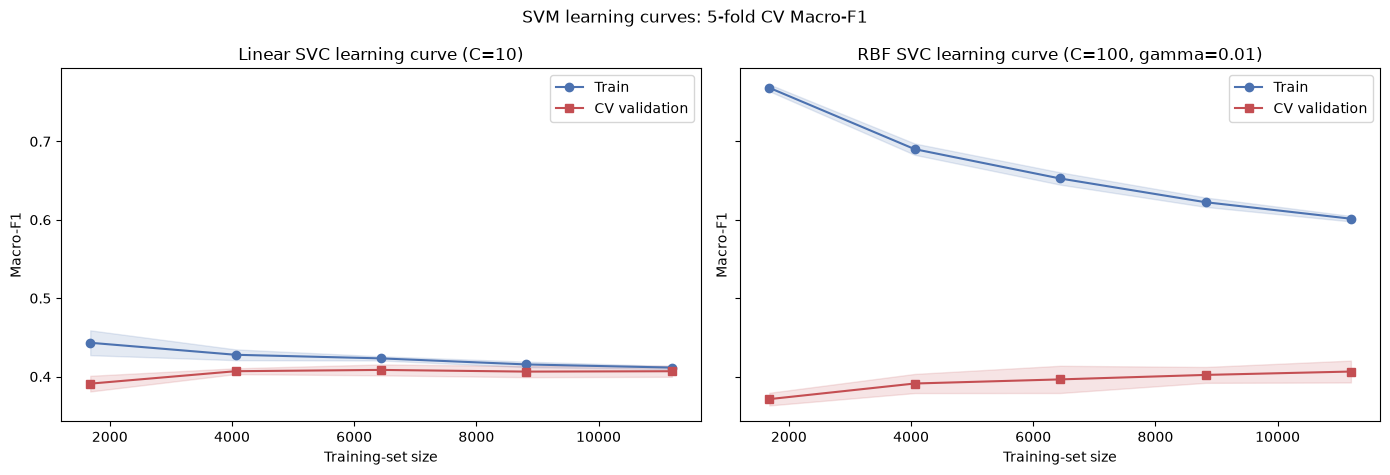

,training_rows,linear_train_macro_f1,linear_validation_macro_f1,rbf_train_macro_f1,rbf_validation_macro_f1
0,1680,0.4431,0.3910,0.7684,0.3713
1,4060,0.4278,0.4069,0.6901,0.3912
2,6439,0.4232,0.4085,0.6527,0.3964
3,8820,0.4155,0.4064,0.6225,0.4021
4,11200,0.4115,0.4068,0.6014,0.4064


In [92]:
def _linear_svc_winner_factory():
    return _linear_svc_pipeline(
        linear_svc_best_C,
        class_weight=linear_svc_class_weight,
    )


def _rbf_svc_winner_factory():
    return _rbf_svc_pipeline(
        rbf_best_C,
        rbf_best_gamma,
        class_weight=rbf_svc_class_weight,
    )


linear_svm_learning = cv_learning_curve(
    _linear_svc_winner_factory,
    X_train,
    y_train,
    train_sizes=LEARNING_SIZES,
    n_jobs=SVM_N_JOBS,
)
rbf_svm_learning = cv_learning_curve(
    _rbf_svc_winner_factory,
    X_train,
    y_train,
    train_sizes=LEARNING_SIZES,
    n_jobs=SVM_N_JOBS,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
plot_learning_curve(
    linear_svm_learning,
    title=f'Linear SVC learning curve (C={linear_svc_best_C:g})',
    ax=axes[0],
)
plot_learning_curve(
    rbf_svm_learning,
    title=f'RBF SVC learning curve (C={rbf_best_C:g}, gamma={rbf_best_gamma:g})',
    ax=axes[1],
)
fig.suptitle('SVM learning curves: 5-fold CV Macro-F1')
plt.tight_layout()
plt.show()

svm_learning_summary = pd.DataFrame({
    'training_rows': linear_svm_learning['sizes'],
    'linear_train_macro_f1': linear_svm_learning['train_mean'],
    'linear_validation_macro_f1': linear_svm_learning['val_mean'],
    'rbf_train_macro_f1': rbf_svm_learning['train_mean'],
    'rbf_validation_macro_f1': rbf_svm_learning['val_mean'],
})
display(svm_learning_summary.round(4))

c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,"SVM linear SVC (C=10, class_weight=balanced)",0.4050,0.4114,0.4899,0.4050,0.4487,0.8537,0.1463,211.2432,2.0861,"linear kernel; C=10, class_weight=balanced; sc..."
1,"SVM RBF SVC (C=100, gamma=0.01, class_weight=N...",0.4605,0.4114,0.3972,0.4605,0.4628,0.9233,0.0767,102.6385,7.7193,"RBF kernel; C=100, gamma=0.01, class_weight=No..."
2,"SVM LinearSVC reference (C=1, class_weight=None)",0.4510,0.3238,0.3401,0.4510,0.4950,0.9460,0.0540,0.1153,0.0042,"linear solver reference; C=1, class_weight=Non..."


,model,class,precision,recall,f1,support
0,Linear SVC,1: Excellent,0.3406,0.7124,0.4609,1071
1,Linear SVC,2: Very Good,0.4823,0.2715,0.3474,2107
2,Linear SVC,3: Good,0.4792,0.3482,0.4034,1789
3,Linear SVC,4: Fair,0.3859,0.3307,0.3562,747
4,Linear SVC,5: Poor,0.3549,0.7867,0.4891,286
5,RBF SVC,1: Excellent,0.4617,0.2306,0.3076,1071
6,RBF SVC,2: Very Good,0.4642,0.6891,0.5547,2107
7,RBF SVC,3: Good,0.4601,0.4131,0.4353,1789
8,RBF SVC,4: Fair,0.4316,0.2999,0.3539,747
9,RBF SVC,5: Poor,0.4764,0.3531,0.4056,286


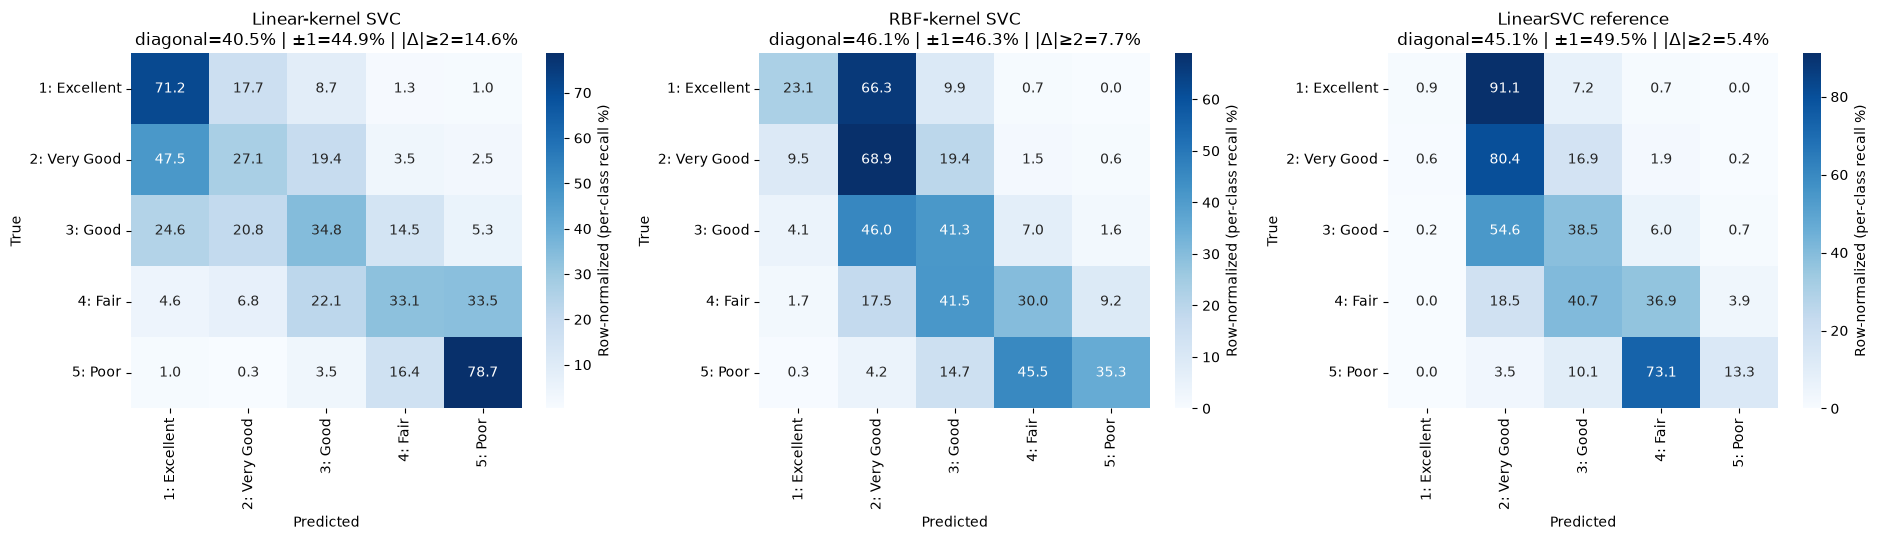

c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,class,linear_svc_support_vectors,rbf_svc_support_vectors
0,1: Excellent,2077,2443
1,2: Very Good,4916,4549
2,3: Good,4172,3955
3,4: Fair,1733,1648
4,5: Poor,406,602


H1 kernel comparison, test Macro-F1 (RBF - linear): +0.0000
SVM linear SVC (C=10, class_weight=balanced): accuracy=0.4050, Macro-F1=0.4114, balanced_accuracy=0.4899, diagonal+/-1=0.854, far=0.146, fit=211.243s, predict=2.086s
SVM RBF SVC (C=100, gamma=0.01, class_weight=None): accuracy=0.4605, Macro-F1=0.4114, balanced_accuracy=0.3972, diagonal+/-1=0.923, far=0.077, fit=102.639s, predict=7.719s
SVM LinearSVC reference (C=1, class_weight=None): accuracy=0.4510, Macro-F1=0.3238, balanced_accuracy=0.3401, diagonal+/-1=0.946, far=0.054, fit=0.115s, predict=0.004s


In [93]:
linear_svc_label = (
    f'C={linear_svc_best_C:g}, class_weight={linear_svc_class_weight}'
)
rbf_svc_label = (
    f'C={rbf_best_C:g}, gamma={rbf_best_gamma:g}, class_weight={rbf_svc_class_weight}'
)
linear_svc_fast_label = f'C={linear_svc_fast_best_C:g}, class_weight=None'

linear_svc_record, linear_svc_diag, linear_svc_y_pred = evaluate_model(
    _linear_svc_winner_factory(),
    X_train,
    y_train,
    X_test,
    y_test,
    name=f'SVM linear SVC ({linear_svc_label})',
    notes=f'linear kernel; {linear_svc_label}; scaled; one-vs-one',
)
rbf_svc_record, rbf_svc_diag, rbf_svc_y_pred = evaluate_model(
    _rbf_svc_winner_factory(),
    X_train,
    y_train,
    X_test,
    y_test,
    name=f'SVM RBF SVC ({rbf_svc_label})',
    notes=f'RBF kernel; {rbf_svc_label}; scaled; one-vs-one',
)
linear_svc_fast_record, linear_svc_fast_diag, linear_svc_fast_y_pred = evaluate_model(
    _linear_svc_fast_pipeline(linear_svc_fast_best_C),
    X_train,
    y_train,
    X_test,
    y_test,
    name=f'SVM LinearSVC reference ({linear_svc_fast_label})',
    notes=f'linear solver reference; {linear_svc_fast_label}; scaled; one-vs-rest',
)
results.extend([linear_svc_record, rbf_svc_record, linear_svc_fast_record])

svm_records = pd.DataFrame([
    linear_svc_record,
    rbf_svc_record,
    linear_svc_fast_record,
])
display(svm_records.round(4))

svm_per_class = pd.concat([
    linear_svc_diag['per_class'].assign(model='Linear SVC'),
    rbf_svc_diag['per_class'].assign(model='RBF SVC'),
    linear_svc_fast_diag['per_class'].assign(model='LinearSVC reference'),
], ignore_index=True)
display(svm_per_class[['model', 'class', 'precision', 'recall', 'f1', 'support']].round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
plot_confusion_matrix(linear_svc_diag, title='Linear-kernel SVC', ax=axes[0])
plot_confusion_matrix(rbf_svc_diag, title='RBF-kernel SVC', ax=axes[1])
plot_confusion_matrix(linear_svc_fast_diag, title='LinearSVC reference', ax=axes[2])
plt.tight_layout()
plt.show()

linear_support = _linear_svc_winner_factory().fit(X_train, y_train).named_steps['model'].n_support_
rbf_support = _rbf_svc_winner_factory().fit(X_train, y_train).named_steps['model'].n_support_
support_vectors = pd.DataFrame({
    'class': [f'{c}: {class_names[c]}' for c in CLASSES],
    'linear_svc_support_vectors': linear_support,
    'rbf_svc_support_vectors': rbf_support,
})
display(support_vectors)

h1_rbf_minus_linear = rbf_svc_record['macro_f1'] - linear_svc_record['macro_f1']
print(f'H1 kernel comparison, test Macro-F1 (RBF - linear): {h1_rbf_minus_linear:+.4f}')
for record in [linear_svc_record, rbf_svc_record, linear_svc_fast_record]:
    print(
        f"{record['model']}: accuracy={record['accuracy']:.4f}, "
        f"Macro-F1={record['macro_f1']:.4f}, balanced_accuracy={record['balanced_accuracy']:.4f}, "
        f"diagonal+/-1={record['diagonal_pm1_mass']:.3f}, far={record['far_mass']:.3f}, "
        f"fit={record['fit_seconds']:.3f}s, predict={record['predict_seconds']:.3f}s"
    )


nn

In [94]:
from sklearn.neural_network import MLPClassifier

mlp_simple = make_model_pipeline(
    MLPClassifier(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='sgd',
        momentum=0.0,
        nesterovs_momentum=False,
        learning_rate_init=0.01,
        max_iter=200,
        random_state=MODEL_SEED,
    ),
    needs_scaling=True,
)

mlp_simple.fit(X_train, y_train)
train_acc = accuracy_score(y_train, mlp_simple.predict(X_train))
test_acc = accuracy_score(y_test, mlp_simple.predict(X_test))
test_f1 = f1_score(y_test, mlp_simple.predict(X_test), average='macro', zero_division=0)

print('Baseline MLP (single hidden layer, plain SGD):')
print(f'  train accuracy : {train_acc:.4f}')
print(f'  test accuracy  : {test_acc:.4f}')
print(f'  test macro F1  : {test_f1:.4f}')
print(f'  beats dummy?   : {test_f1 > dummy_record["macro_f1"]}')

Baseline MLP (single hidden layer, plain SGD):
  train accuracy : 0.4877
  test accuracy  : 0.4737
  test macro F1  : 0.4452
  beats dummy?   : True


c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached 

,architecture,train_macro_f1,val_macro_f1,val_macro_f1_std
0,"(8,)",0.4480,0.4353,0.0117
1,"(32,)",0.4566,0.4302,0.0067
2,"(64,)",0.4658,0.4352,0.0178
3,"(128,)",0.4774,0.4416,0.0067
4,"(64, 32)",0.4801,0.4395,0.0121


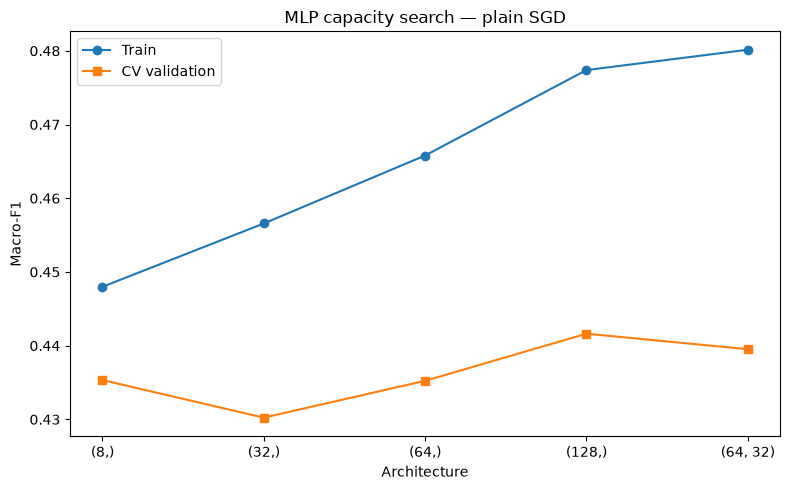

Best architecture: (128,)


In [98]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MLP_ARCHITECTURES = [(8,), (32,), (64,), (128,), (64, 32)]
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_mlp_pipeline(hidden_layers):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',
            solver='sgd',
            momentum=0.0,
            nesterovs_momentum=False,
            learning_rate_init=0.01,
            max_iter=200,
            random_state=42,
        )),
    ])

architecture_rows = []
for architecture in MLP_ARCHITECTURES:
    scores = cross_validate(
        make_mlp_pipeline(architecture), X_train, y_train,
        cv=cv_splitter, scoring='f1_macro', return_train_score=True,
    )
    architecture_rows.append({
        'architecture': architecture,
        'train_macro_f1': scores['train_score'].mean(),
        'val_macro_f1': scores['test_score'].mean(),
        'val_macro_f1_std': scores['test_score'].std(),
    })

architecture_df = pd.DataFrame(architecture_rows)
display(architecture_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x_positions = np.arange(len(architecture_df))
ax.plot(x_positions, architecture_df['train_macro_f1'], marker='o', label='Train')
ax.plot(x_positions, architecture_df['val_macro_f1'], marker='s', label='CV validation')
ax.set_xticks(x_positions)
ax.set_xticklabels([str(a) for a in architecture_df['architecture']])
ax.set_xlabel('Architecture')
ax.set_ylabel('Macro-F1')
ax.set_title('MLP capacity search — plain SGD')
ax.legend()
plt.tight_layout()
plt.show()

best_architecture = architecture_df.loc[architecture_df['val_macro_f1'].idxmax(), 'architecture']
print(f'Best architecture: {best_architecture}')

c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Pagarwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached 

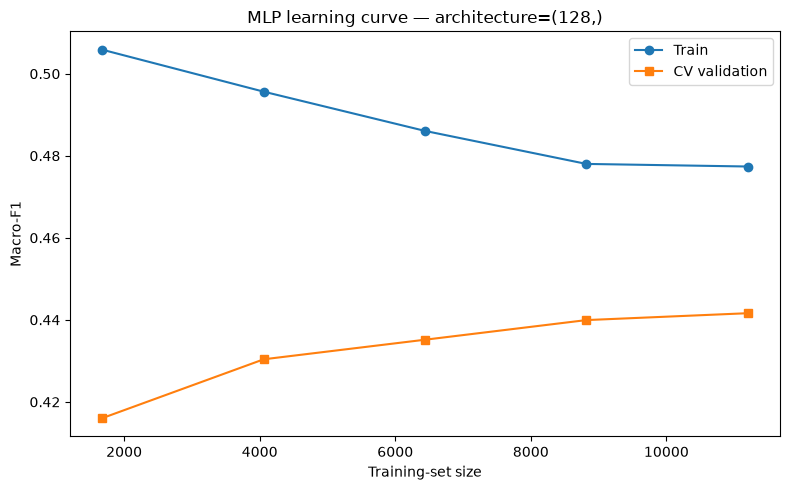

In [99]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    make_mlp_pipeline(best_architecture), X_train, y_train,
    train_sizes=np.linspace(0.15, 1.0, 5),
    cv=cv_splitter, scoring='f1_macro',
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1), marker='s', label='CV validation')
ax.set_xlabel('Training-set size')
ax.set_ylabel('Macro-F1')
ax.set_title(f'MLP learning curve — architecture={best_architecture}')
ax.legend()
plt.tight_layout()
plt.show()

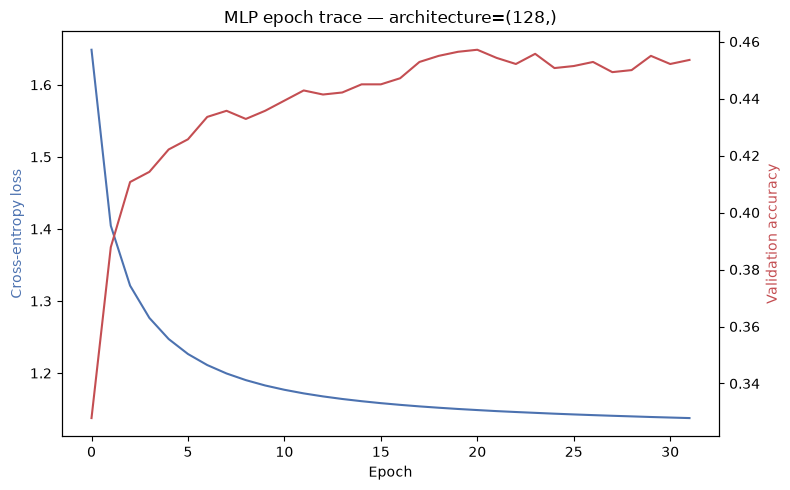

Epochs completed: 32


In [100]:
mlp_diagnostic = MLPClassifier(
    hidden_layer_sizes=best_architecture,
    activation='relu',
    solver='sgd',
    momentum=0.0,
    nesterovs_momentum=False,
    learning_rate_init=0.01,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
)
X_train_scaled = StandardScaler().fit_transform(X_train)
mlp_diagnostic.fit(X_train_scaled, y_train)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(mlp_diagnostic.loss_curve_, color='#4C72B0', label='Training loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss', color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(mlp_diagnostic.validation_scores_, color='#C44E52', label='Validation score')
ax2.set_ylabel('Validation accuracy', color='#C44E52')

ax1.set_title(f'MLP epoch trace — architecture={best_architecture}')
fig.tight_layout()
plt.show()

print(f'Epochs completed: {mlp_diagnostic.n_iter_}')

,alpha,train_macro_f1,val_macro_f1
0,0.0000,0.4361,0.4219
1,0.0001,0.4361,0.4219
2,0.0010,0.4361,0.4219
3,0.0100,0.4362,0.4219


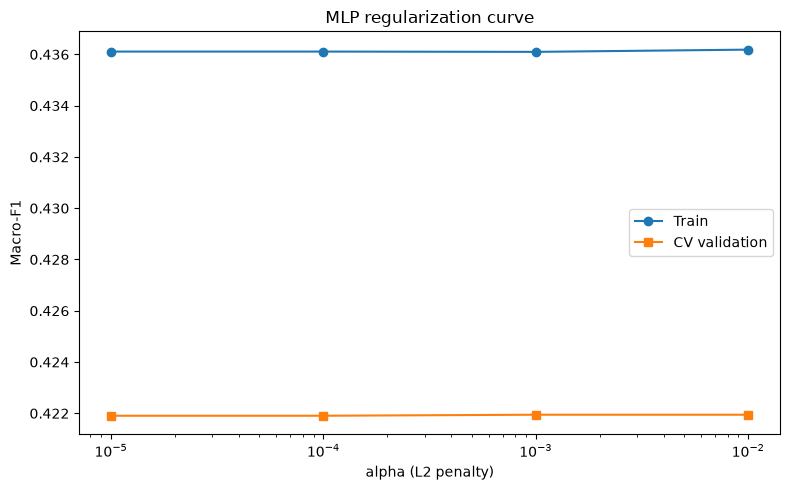

Best alpha: 0.001


In [101]:
ALPHA_VALUES = [1e-5, 1e-4, 1e-3, 1e-2]

alpha_rows = []
for alpha in ALPHA_VALUES:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=best_architecture,
            activation='relu',
            solver='sgd',
            momentum=0.0,
            nesterovs_momentum=False,
            learning_rate_init=0.01,
            alpha=alpha,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42,
        )),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_splitter, scoring='f1_macro', return_train_score=True)
    alpha_rows.append({
        'alpha': alpha,
        'train_macro_f1': scores['train_score'].mean(),
        'val_macro_f1': scores['test_score'].mean(),
    })

alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_df['alpha'], alpha_df['train_macro_f1'], marker='o', label='Train')
ax.plot(alpha_df['alpha'], alpha_df['val_macro_f1'], marker='s', label='CV validation')
ax.set_xscale('log')
ax.set_xlabel('alpha (L2 penalty)')
ax.set_ylabel('Macro-F1')
ax.set_title('MLP regularization curve')
ax.legend()
plt.tight_layout()
plt.show()

best_alpha = alpha_df.loc[alpha_df['val_macro_f1'].idxmax(), 'alpha']
print(f'Best alpha: {best_alpha:g}')

In [102]:
ACTIVATIONS = ['relu', 'tanh', 'logistic', 'identity']

activation_rows = []
for activation in ACTIVATIONS:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=best_architecture,
            activation=activation,
            solver='sgd',
            momentum=0.0,
            nesterovs_momentum=False,
            learning_rate_init=0.01,
            alpha=best_alpha,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42,
        )),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_splitter, scoring='f1_macro')
    activation_rows.append({
        'activation': activation,
        'val_macro_f1': scores['test_score'].mean(),
        'val_macro_f1_std': scores['test_score'].std(),
    })

activation_df = pd.DataFrame(activation_rows).sort_values('val_macro_f1', ascending=False)
display(activation_df.round(4))

best_activation = activation_df.iloc[0]['activation']
print(f'Best activation: {best_activation}')

,activation,val_macro_f1,val_macro_f1_std
0,relu,0.4219,0.0175
3,identity,0.4200,0.0177
1,tanh,0.4162,0.0042
2,logistic,0.2660,0.0147


Best activation: relu


Architecture : (128,)
Activation   : relu
Alpha        : 0.001
Test accuracy: 0.4620
Test Macro-F1: 0.4147
Balanced acc : 0.3963


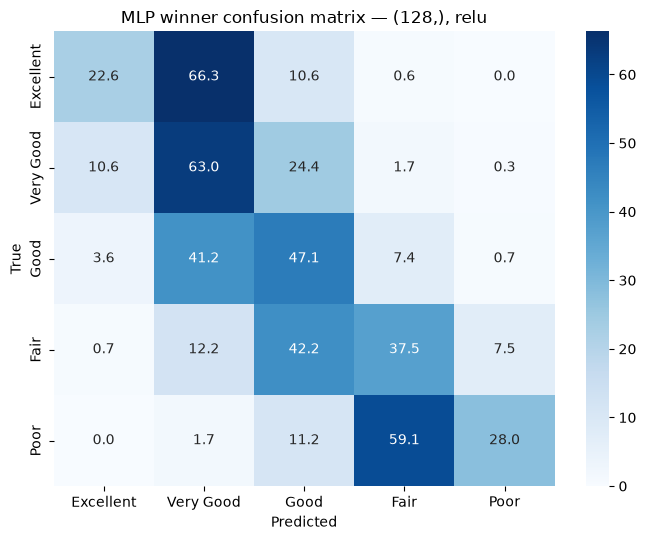

In [103]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
import seaborn as sns

mlp_winner = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=best_architecture,
        activation=best_activation,
        solver='sgd',
        momentum=0.0,
        nesterovs_momentum=False,
        learning_rate_init=0.01,
        alpha=best_alpha,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
    )),
])
mlp_winner.fit(X_train, y_train)
y_pred_winner = mlp_winner.predict(X_test)

winner_accuracy = accuracy_score(y_test, y_pred_winner)
winner_macro_f1 = f1_score(y_test, y_pred_winner, average='macro', zero_division=0)
winner_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_winner)

print(f'Architecture : {best_architecture}')
print(f'Activation   : {best_activation}')
print(f'Alpha        : {best_alpha:g}')
print(f'Test accuracy: {winner_accuracy:.4f}')
print(f'Test Macro-F1: {winner_macro_f1:.4f}')
print(f'Balanced acc : {winner_balanced_accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred_winner, labels=CLASSES)
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm_normalized * 100, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=[class_names[c] for c in CLASSES],
    yticklabels=[class_names[c] for c in CLASSES], ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'MLP winner confusion matrix — {best_architecture}, {best_activation}')
plt.tight_layout()
plt.show()

sklearn MLP winner: architecture=(128,), activation=relu
Test accuracy : 0.4620
Test Macro-F1 : 0.4147


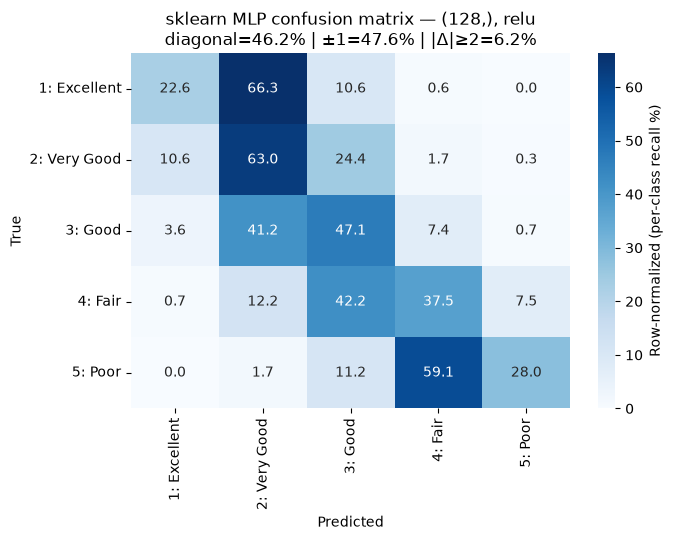

,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,Baseline: majority-class dummy,0.3512,0.1040,0.2000,0.3512,0.4767,0.8278,0.1722,0.0009,0.0004,Sanity check; must beat this on Macro-F1 and b...
1,"kNN (k=26, distance, euclidean)",0.4492,0.4148,0.3911,0.4492,0.4628,0.9120,0.0880,0.0596,0.1392,"k=26, distance, euclidean; scaled"
2,"SVM linear SVC (C=10, class_weight=balanced)",0.4050,0.4114,0.4899,0.4050,0.4487,0.8537,0.1463,211.2432,2.0861,"linear kernel; C=10, class_weight=balanced; sc..."
3,"SVM RBF SVC (C=100, gamma=0.01, class_weight=N...",0.4605,0.4114,0.3972,0.4605,0.4628,0.9233,0.0767,102.6385,7.7193,"RBF kernel; C=100, gamma=0.01, class_weight=No..."
4,"SVM LinearSVC reference (C=1, class_weight=None)",0.4510,0.3238,0.3401,0.4510,0.4950,0.9460,0.0540,0.1153,0.0042,"linear solver reference; C=1, class_weight=Non..."
5,"PyTorch MLP ((64, 32), ReLU)",0.4757,0.4448,0.4278,0.4757,0.4582,0.9338,0.0662,18.2825,0.0073,activation=ReLU; weight_decay=1e-05; plain SGD
6,Decision Tree (max_depth=6),0.4378,0.4188,0.4078,0.4378,0.4847,0.9225,0.0775,0.0209,0.0023,winner chosen by higher CV Macro-F1 between ma...
7,"Decision Tree (ccp_alpha=0.000159, class_weigh...",0.4502,0.4265,0.4166,0.4502,0.4733,0.9235,0.0765,0.0287,0.0016,winner = better of tuned GridSearchCV/Randomiz...
8,"sklearn MLP ((128,), relu)",0.4620,0.4147,0.3963,0.4620,0.4763,0.9383,0.0617,1.6820,0.0055,activation=relu; alpha=0.001; plain SGD


In [118]:
sk_mlp_width_curve = {
    'param_values': architecture_df['architecture'].tolist(),
    'train_mean': architecture_df['train_macro_f1'].to_numpy(),
    'val_mean': architecture_df['val_macro_f1'].to_numpy(),
    'val_std': architecture_df['val_macro_f1_std'].to_numpy(),
    'best_index': int(architecture_df['val_macro_f1'].idxmax()),
    'best_value': best_architecture,
    'best_val_score': float(architecture_df['val_macro_f1'].max()),
}
sk_mlp_best_architecture = best_architecture

sk_mlp_learning = {
    'sizes': train_sizes,
    'train_mean': train_scores.mean(axis=1),
    'train_std': train_scores.std(axis=1),
    'val_mean': val_scores.mean(axis=1),
    'val_std': val_scores.std(axis=1),
}

def _sk_mlp_winner_factory():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=best_architecture,
            activation=best_activation,
            solver='sgd',
            momentum=0.0,
            nesterovs_momentum=False,
            learning_rate_init=0.01,
            alpha=best_alpha,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42,
        )),
    ])

sk_mlp_record, sk_mlp_diag, sk_mlp_y_pred = evaluate_model(
    _sk_mlp_winner_factory(), X_train, y_train, X_test, y_test,
    name=f'sklearn MLP ({best_architecture}, {best_activation})',
    notes=f'activation={best_activation}; alpha={best_alpha:g}; plain SGD',
)
results.append(sk_mlp_record)

sk_mlp_best = {
    'architecture': best_architecture,
    'activation': best_activation,
    'alpha': best_alpha,
    'cv_macro_f1_mean': float(activation_df.iloc[0]['val_macro_f1']),
}

print(f'sklearn MLP winner: architecture={best_architecture}, activation={best_activation}')
print(f'Test accuracy : {sk_mlp_record["accuracy"]:.4f}')
print(f'Test Macro-F1 : {sk_mlp_record["macro_f1"]:.4f}')

plot_confusion_matrix(sk_mlp_diag, title=f'sklearn MLP confusion matrix — {best_architecture}, {best_activation}')
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).round(4))

pytorch nn

Epoch 20/200: loss=1.6103
Epoch 40/200: loss=1.5802
Epoch 60/200: loss=1.5550
Epoch 80/200: loss=1.5335
Epoch 100/200: loss=1.5146
Epoch 120/200: loss=1.4978
Epoch 140/200: loss=1.4827
Epoch 160/200: loss=1.4687
Epoch 180/200: loss=1.4558
Epoch 200/200: loss=1.4436
Train accuracy: 0.3941
Test accuracy : 0.3948
Test macro F1 : 0.1991


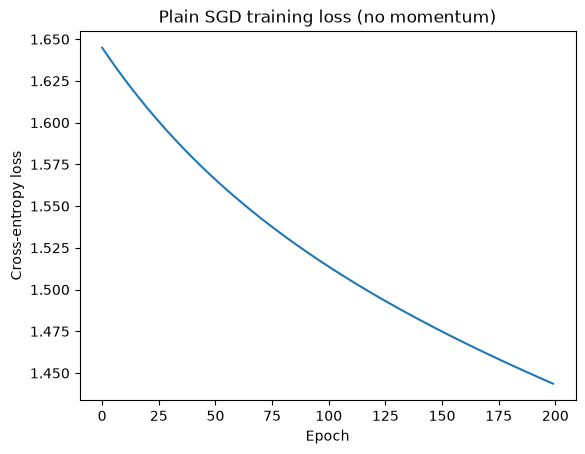

In [104]:
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# --- Prepare data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

classes = np.unique(y_train)
y_train_encoded = np.searchsorted(classes, y_train).astype(np.int64)
y_test_encoded = np.searchsorted(classes, y_test).astype(np.int64)

X_train_tensor = torch.from_numpy(X_train_scaled)
y_train_tensor = torch.from_numpy(y_train_encoded)
X_test_tensor = torch.from_numpy(X_test_scaled)

# --- Compact MLP: one hidden layer ---
torch.manual_seed(42)

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP(input_dim=X_train_tensor.shape[1], hidden_dim=32, output_dim=len(classes))

# --- Plain SGD, no momentum ---
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.0)
criterion = nn.CrossEntropyLoss()

# --- Simple full-batch training loop ---
EPOCHS = 200
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1}/{EPOCHS}: loss={loss.item():.4f}')

# --- Evaluation ---
model.eval()
with torch.no_grad():
    train_preds = classes[model(X_train_tensor).argmax(dim=1).numpy()]
    test_preds = classes[model(X_test_tensor).argmax(dim=1).numpy()]

print(f'Train accuracy: {accuracy_score(y_train, train_preds):.4f}')
print(f'Test accuracy : {accuracy_score(y_test, test_preds):.4f}')
print(f'Test macro F1 : {f1_score(y_test, test_preds, average="macro", zero_division=0):.4f}')

import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Plain SGD training loss (no momentum)')
plt.show()

In [106]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split

def mlp_parameter_count(input_dim, hidden_layers, n_classes):
    dims = [input_dim] + list(hidden_layers) + [n_classes]
    return sum(dims[i] * dims[i + 1] + dims[i + 1] for i in range(len(dims) - 1))


class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    _ACTIVATIONS = {'relu': nn.ReLU, 'gelu': nn.GELU, 'silu': nn.SiLU, 'tanh': nn.Tanh}

    def __init__(self, hidden_layers=(32,), activation='relu', learning_rate=0.01,
                 batch_size=256, weight_decay=0.0, max_epochs=200, patience=10,
                 validation_fraction=0.1, random_state=42):
        self.hidden_layers = hidden_layers
        self.activation = activation
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.patience = patience
        self.validation_fraction = validation_fraction
        self.random_state = random_state

    def _build_network(self, input_dim, n_classes):
        activation_cls = self._ACTIVATIONS[self.activation]
        layers, prev_dim = [], input_dim
        for hidden_dim in self.hidden_layers:
            layers += [nn.Linear(prev_dim, hidden_dim), activation_cls()]
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, n_classes))
        return nn.Sequential(*layers)

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X = np.asarray(X, dtype=np.float32)
        self.classes_ = np.unique(y)
        y_encoded = np.searchsorted(self.classes_, y).astype(np.int64)

        X_fit, X_val, y_fit, y_val = train_test_split(
            X, y_encoded, test_size=self.validation_fraction,
            stratify=y_encoded, random_state=self.random_state,
        )
        X_fit_t, y_fit_t = torch.from_numpy(X_fit), torch.from_numpy(y_fit)
        X_val_t, y_val_t = torch.from_numpy(X_val), torch.from_numpy(y_val)

        self.module_ = self._build_network(X.shape[1], len(self.classes_))
        optimizer = torch.optim.SGD(
            self.module_.parameters(), lr=self.learning_rate,
            momentum=0.0, weight_decay=self.weight_decay,
        )
        criterion = nn.CrossEntropyLoss()
        rng = np.random.RandomState(self.random_state)
        n_samples = X_fit_t.shape[0]

        self.loss_curve_, self.validation_loss_curve_ = [], []
        best_val_loss, epochs_no_improve = np.inf, 0

        for epoch in range(self.max_epochs):
            self.module_.train()
            permutation = rng.permutation(n_samples)
            epoch_losses = []
            for start in range(0, n_samples, self.batch_size):
                batch_idx = permutation[start:start + self.batch_size]
                optimizer.zero_grad()
                loss = criterion(self.module_(X_fit_t[batch_idx]), y_fit_t[batch_idx])
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            self.loss_curve_.append(float(np.mean(epoch_losses)))

            self.module_.eval()
            with torch.no_grad():
                val_loss = criterion(self.module_(X_val_t), y_val_t).item()
            self.validation_loss_curve_.append(val_loss)

            if val_loss < best_val_loss - 1e-4:
                best_val_loss, epochs_no_improve = val_loss, 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.patience:
                    break

        self.n_iter_ = epoch + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.module_.eval()
        with torch.no_grad():
            preds = self.module_(torch.from_numpy(X)).argmax(dim=1).numpy()
        return self.classes_[preds]


def _torch_mlp_pipeline(hidden_layers, activation='relu', weight_decay=0.0):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', TorchMLPClassifier(
            hidden_layers=hidden_layers, activation=activation,
            weight_decay=weight_decay, random_state=MODEL_SEED,
        )),
    ])

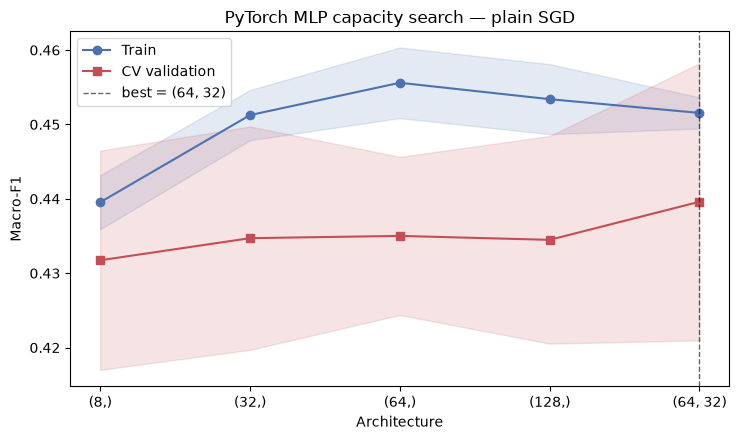

Best architecture: (64, 32)


In [107]:
TORCH_ARCHITECTURES = [(8,), (32,), (64,), (128,), (64, 32)]

def _torch_mlp_capacity_pipeline(hidden_layers):
    return _torch_mlp_pipeline(hidden_layers, activation='relu')

torch_mlp_width_curve = cv_complexity_curve(
    _torch_mlp_capacity_pipeline, X_train, y_train, TORCH_ARCHITECTURES, n_jobs=1,
)
plot_complexity_curve(
    torch_mlp_width_curve, param_label='Architecture',
    title='PyTorch MLP capacity search — plain SGD',
)
plt.tight_layout()
plt.show()

torch_mlp_best_architecture = torch_mlp_width_curve['best_value']
print(f'Best architecture: {torch_mlp_best_architecture}')

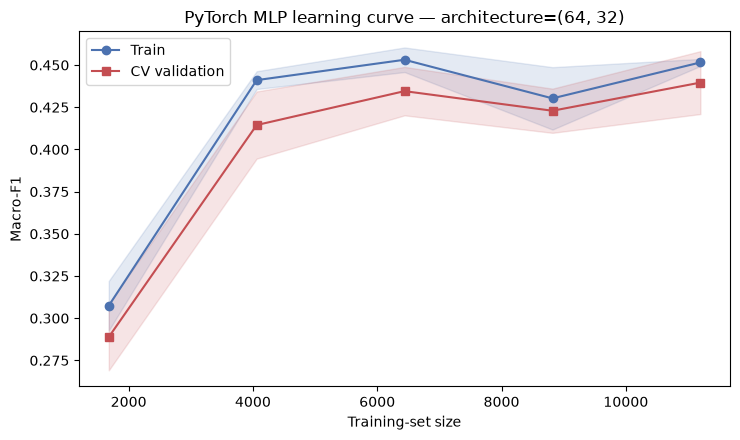

In [108]:
def _torch_mlp_winner_factory():
    return _torch_mlp_pipeline(torch_mlp_best_architecture, activation='relu')

torch_mlp_learning = cv_learning_curve(
    _torch_mlp_winner_factory, X_train, y_train, train_sizes=LEARNING_SIZES, n_jobs=1,
)
plot_learning_curve(
    torch_mlp_learning,
    title=f'PyTorch MLP learning curve — architecture={torch_mlp_best_architecture}',
)
plt.tight_layout()
plt.show()

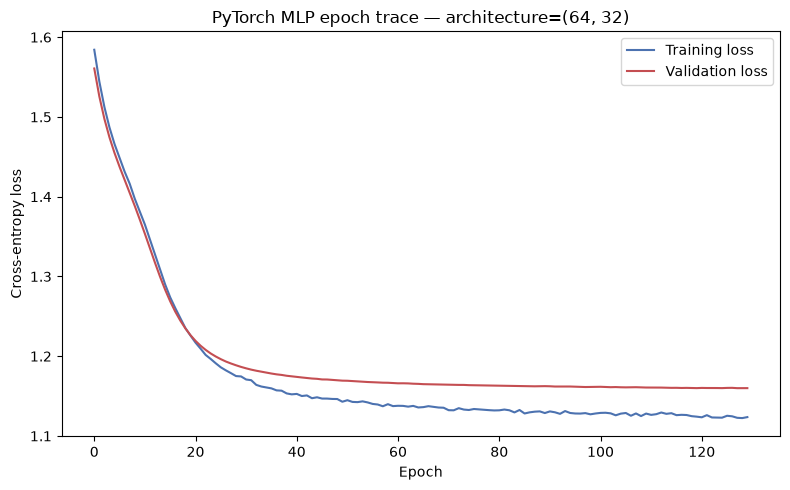

Epochs completed: 130


In [109]:
torch_mlp_diagnostic_pipe = _torch_mlp_winner_factory()
torch_mlp_diagnostic_pipe.fit(X_train, y_train)
torch_mlp_diagnostic = torch_mlp_diagnostic_pipe.named_steps['model']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(torch_mlp_diagnostic.loss_curve_, color=_TRAIN_COLOR, label='Training loss')
ax.plot(torch_mlp_diagnostic.validation_loss_curve_, color=_VAL_COLOR, label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title(f'PyTorch MLP epoch trace — architecture={torch_mlp_best_architecture}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Epochs completed: {torch_mlp_diagnostic.n_iter_}')

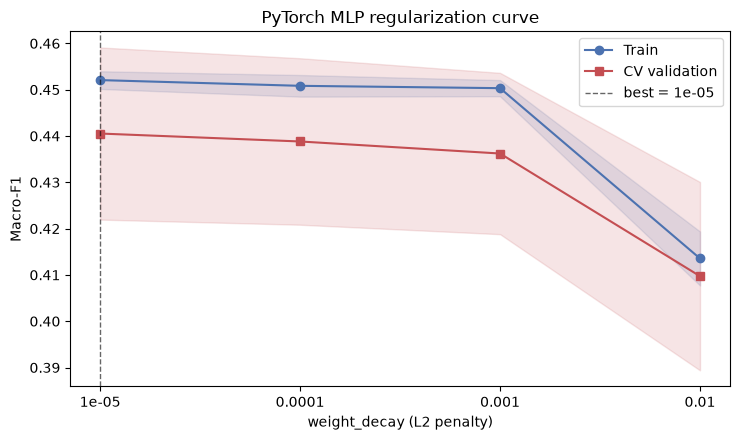

Best weight_decay: 1e-05


In [110]:
WEIGHT_DECAY_VALUES = [1e-5, 1e-4, 1e-3, 1e-2]

def _torch_mlp_weight_decay_pipeline(weight_decay):
    return _torch_mlp_pipeline(torch_mlp_best_architecture, activation='relu', weight_decay=weight_decay)

torch_mlp_weight_decay_curve = cv_complexity_curve(
    _torch_mlp_weight_decay_pipeline, X_train, y_train, WEIGHT_DECAY_VALUES, n_jobs=1,
)
plot_complexity_curve(
    torch_mlp_weight_decay_curve, param_label='weight_decay (L2 penalty)',
    title='PyTorch MLP regularization curve',
)
plt.tight_layout()
plt.show()

torch_mlp_best_weight_decay = torch_mlp_weight_decay_curve['best_value']
print(f'Best weight_decay: {torch_mlp_best_weight_decay:g}')

,activation,architecture,parameters,epochs_mean,fit_seconds_mean,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std
0,ReLU,"(64, 32)",3653,169.8,9.8844,0.4735,0.0093,0.4405,0.0186,0.4242,0.0175
1,SiLU / Swish,"(64, 32)",3653,195.8,16.8515,0.4744,0.0110,0.4395,0.0141,0.4217,0.0136
2,tanh,"(64, 32)",3653,158.8,15.5529,0.4747,0.0145,0.4389,0.0165,0.4231,0.0159
3,GELU,"(64, 32)",3653,189.4,23.8146,0.4726,0.0106,0.4366,0.0161,0.4201,0.0156


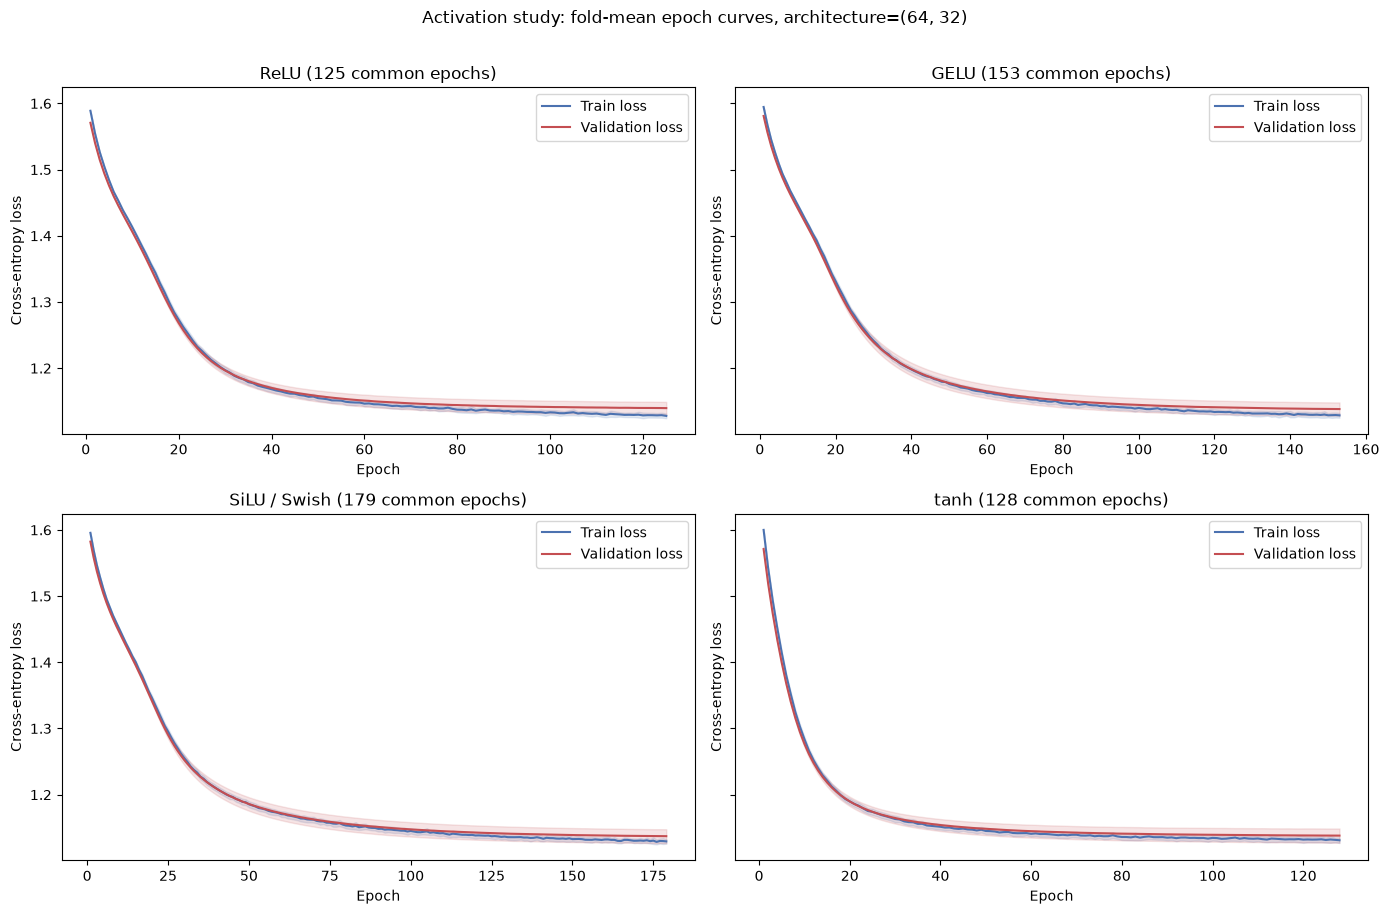

Extra-credit activation findings (training-only CV):
  Best mean Macro-F1: ReLU (0.4405 +/- 0.0186)
  Fastest mean fold fit: ReLU (9.884s)
  Lowest Macro-F1 fold variability: SiLU / Swish (std=0.0141)


In [111]:
ACTIVATION_FUNCTIONS = ('relu', 'gelu', 'silu', 'tanh')
ACTIVATION_LABELS = {
    'relu': 'ReLU',
    'gelu': 'GELU',
    'silu': 'SiLU / Swish',
    'tanh': 'tanh',
}
ACTIVATION_SCORING = {
    'accuracy': 'accuracy',
    'macro_f1': 'f1_macro',
    'balanced_accuracy': 'balanced_accuracy',
}
activation_architecture = torch_mlp_best_architecture
activation_parameters = mlp_parameter_count(
    X_train.shape[1], activation_architecture, len(CLASSES),
)

activation_rows = []
activation_epoch_curves = {}
for activation in ACTIVATION_FUNCTIONS:
    cv_result = cross_validate(
        _torch_mlp_pipeline(activation_architecture, activation=activation, weight_decay=torch_mlp_best_weight_decay),
        X_train, y_train,
        cv=inner_splitter,
        scoring=ACTIVATION_SCORING,
        n_jobs=1,
        return_estimator=True,
        error_score='raise',
    )

    fold_models = [estimator.named_steps['model'] for estimator in cv_result['estimator']]
    common_epochs = min(model.n_iter_ for model in fold_models)
    train_loss = np.vstack([model.loss_curve_[:common_epochs] for model in fold_models])
    validation_loss = np.vstack([
        model.validation_loss_curve_[:common_epochs] for model in fold_models
    ])
    activation_epoch_curves[activation] = {
        'epochs': np.arange(1, common_epochs + 1),
        'train_mean': train_loss.mean(axis=0),
        'train_std': train_loss.std(axis=0),
        'validation_mean': validation_loss.mean(axis=0),
        'validation_std': validation_loss.std(axis=0),
    }

    row = {
        'activation': ACTIVATION_LABELS[activation],
        'architecture': activation_architecture,
        'parameters': activation_parameters,
        'epochs_mean': float(np.mean([model.n_iter_ for model in fold_models])),
        'fit_seconds_mean': float(cv_result['fit_time'].mean()),
    }
    for metric in ACTIVATION_SCORING:
        row[f'cv_{metric}_mean'] = float(cv_result[f'test_{metric}'].mean())
        row[f'cv_{metric}_std'] = float(cv_result[f'test_{metric}'].std())
    activation_rows.append(row)

activation_comparison = (
    pd.DataFrame(activation_rows)
    .sort_values('cv_macro_f1_mean', ascending=False)
    .reset_index(drop=True)
)
assert activation_comparison['parameters'].nunique() == 1
display(activation_comparison.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=True)
for ax, activation in zip(axes.ravel(), ACTIVATION_FUNCTIONS):
    curve = activation_epoch_curves[activation]
    epochs = curve['epochs']
    ax.plot(epochs, curve['train_mean'], color=_TRAIN_COLOR, label='Train loss')
    ax.fill_between(
        epochs, curve['train_mean'] - curve['train_std'],
        curve['train_mean'] + curve['train_std'],
        color=_TRAIN_COLOR, alpha=0.15,
    )
    ax.plot(epochs, curve['validation_mean'], color=_VAL_COLOR, label='Validation loss')
    ax.fill_between(
        epochs, curve['validation_mean'] - curve['validation_std'],
        curve['validation_mean'] + curve['validation_std'],
        color=_VAL_COLOR, alpha=0.15,
    )
    ax.set_title(f"{ACTIVATION_LABELS[activation]} ({len(epochs)} common epochs)")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend()
fig.suptitle(
    f'Activation study: fold-mean epoch curves, architecture={activation_architecture}',
    y=1.01,
)
plt.tight_layout()
plt.show()

best_activation_row = activation_comparison.iloc[0]
fastest_activation_row = activation_comparison.loc[activation_comparison['fit_seconds_mean'].idxmin()]
most_stable_activation_row = activation_comparison.loc[activation_comparison['cv_macro_f1_std'].idxmin()]
print('Extra-credit activation findings (training-only CV):')
print(f"  Best mean Macro-F1: {best_activation_row['activation']} "
      f"({best_activation_row['cv_macro_f1_mean']:.4f} +/- {best_activation_row['cv_macro_f1_std']:.4f})")
print(f"  Fastest mean fold fit: {fastest_activation_row['activation']} "
      f"({fastest_activation_row['fit_seconds_mean']:.3f}s)")
print(f"  Lowest Macro-F1 fold variability: {most_stable_activation_row['activation']} "
      f"(std={most_stable_activation_row['cv_macro_f1_std']:.4f})")

PyTorch MLP winner: architecture=(64, 32), activation=ReLU
Test accuracy : 0.4757
Test Macro-F1 : 0.4448


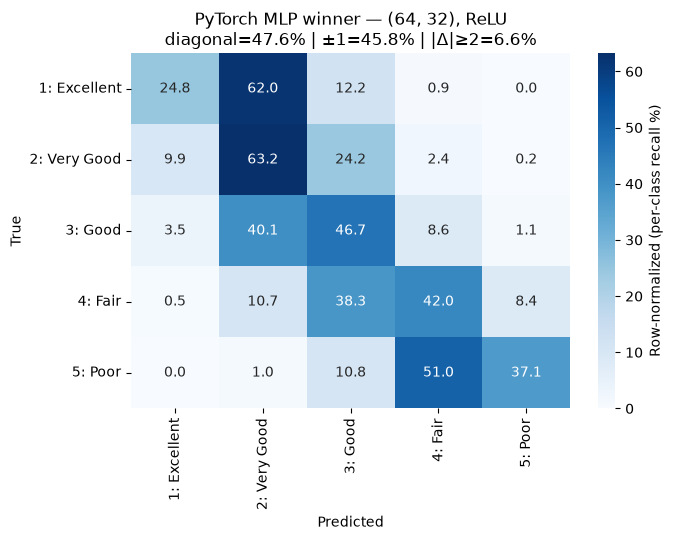

,model,accuracy,macro_f1,balanced_accuracy,diagonal_mass,adjacent_mass,diagonal_pm1_mass,far_mass,fit_seconds,predict_seconds,notes
0,Baseline: majority-class dummy,0.3512,0.1040,0.2000,0.3512,0.4767,0.8278,0.1722,0.0009,0.0004,Sanity check; must beat this on Macro-F1 and b...
1,"kNN (k=26, distance, euclidean)",0.4492,0.4148,0.3911,0.4492,0.4628,0.9120,0.0880,0.0596,0.1392,"k=26, distance, euclidean; scaled"
2,"SVM linear SVC (C=10, class_weight=balanced)",0.4050,0.4114,0.4899,0.4050,0.4487,0.8537,0.1463,211.2432,2.0861,"linear kernel; C=10, class_weight=balanced; sc..."
3,"SVM RBF SVC (C=100, gamma=0.01, class_weight=N...",0.4605,0.4114,0.3972,0.4605,0.4628,0.9233,0.0767,102.6385,7.7193,"RBF kernel; C=100, gamma=0.01, class_weight=No..."
4,"SVM LinearSVC reference (C=1, class_weight=None)",0.4510,0.3238,0.3401,0.4510,0.4950,0.9460,0.0540,0.1153,0.0042,"linear solver reference; C=1, class_weight=Non..."
5,"PyTorch MLP ((64, 32), ReLU)",0.4757,0.4448,0.4278,0.4757,0.4582,0.9338,0.0662,18.2825,0.0073,activation=ReLU; weight_decay=1e-05; plain SGD


In [113]:
torch_mlp_best_activation = activation_comparison.iloc[0]['activation']
_label_to_key = {v: k for k, v in ACTIVATION_LABELS.items()}
torch_mlp_best_activation_key = _label_to_key[torch_mlp_best_activation]

torch_mlp_winner_pipe = _torch_mlp_pipeline(
    torch_mlp_best_architecture,
    activation=torch_mlp_best_activation_key,
    weight_decay=torch_mlp_best_weight_decay,
)
torch_mlp_record, torch_mlp_diag, torch_mlp_y_pred = evaluate_model(
    torch_mlp_winner_pipe, X_train, y_train, X_test, y_test,
    name=f'PyTorch MLP ({torch_mlp_best_architecture}, {torch_mlp_best_activation})',
    notes=f'activation={torch_mlp_best_activation}; weight_decay={torch_mlp_best_weight_decay:g}; plain SGD',
)
results.append(torch_mlp_record)

torch_mlp_best = {
    'architecture': torch_mlp_best_architecture,
    'activation': torch_mlp_best_activation,
    'weight_decay': torch_mlp_best_weight_decay,
    'cv_macro_f1_mean': float(activation_comparison.iloc[0]['cv_macro_f1_mean']),
}

print(f'PyTorch MLP winner: architecture={torch_mlp_best_architecture}, activation={torch_mlp_best_activation}')
print(f'Test accuracy : {torch_mlp_record["accuracy"]:.4f}')
print(f'Test Macro-F1 : {torch_mlp_record["macro_f1"]:.4f}')

plot_confusion_matrix(
    torch_mlp_diag,
    title=f'PyTorch MLP winner — {torch_mlp_best_architecture}, {torch_mlp_best_activation}',
)
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).round(4))